# Model Definition and Evaluation
## Table of Contents
1. [Model Selection](#model-selection)
2. [Feature Engineering](#feature-engineering)
3. [Hyperparameter Tuning](#hyperparameter-tuning)
4. [Implementation](#implementation)
5. [Evaluation Metrics](#evaluation-metrics)
6. [Comparative Analysis](#comparative-analysis)


In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, mean_squared_error, classification_report
# Import models you're considering

## Model Selection
Our oceanographic profiles have two dimensions (depth x size bin), where Biovolume values in neighboring depths and size bins are correlated. This suggests that the 2D pattern of Biovolume is of importance.
By visualizing these 2D patterns as heatmaps, we aim to classify Profiles using convolutional neural networks (CNN). 
- We start by testing a simple CNN and low-resolution heatmaps (with only 45 x 45 pixels)
- We aim to progress towards createing higher-resolution heatmaps with interpolation between data points which we aim to use for transfer learning.

## Feature Engineering

Beyond the baseline preprocessing, our feature engineering focused on preparing the UVP particle-biovolume profiles for convolution-based classification. First, all biovolume values were normalized on a per-profile basis to reduce the influence of varying absolute particle concentrations and highlight relative vertical distribution patterns. Each profile was then reshaped into a structured 40×17 depth–size matrix, effectively forming a 2D heatmap representation. This transformation converts the raw measurements into spatially coherent feature maps suitable for convolutional neural networks. We deliberately refrained from introducing aggregated or hand-crafted features, as CNNs are expected to extract relevant spatial and multiscale patterns directly from the heatmaps.

- adding labels
- adding squared transformation

### Defining Functions

In [2]:
# TODO  :   Function Declaration Cell

import matplotlib.pyplot as plt
import os
import numpy as np
from pathlib import Path
from scipy.ndimage import gaussian_filter
from matplotlib.colors import PowerNorm, LogNorm

heatmap_data = []

## --------------------------------------------------------- ##

def pad_heatmap(
    arr: np.ndarray,
    pad_top: int = 4,
    pad_bottom: int = 4,
    pad_left: int = 1,
    pad_right: int = 1,
    value: float = 0.0,
) -> np.ndarray:
    """
    Pad ein 2D-Array (Heatmap) mit Konstanten (default: 0).

    arr:       2D-Array (H, W)
    pad_top:   zusätzliche Zeilen oben
    pad_bottom:zusätzliche Zeilen unten
    pad_left:  zusätzliche Spalten links
    pad_right: zusätzliche Spalten rechts
    value:     Füllwert (Standard: 0.0)
    """
    return np.pad(
        arr,
        pad_width=((pad_top, pad_bottom), (pad_left, pad_right)),
        mode="constant",
        constant_values=value,
    )

## --------------------------------------------------------- ##

def crop_figure(fig, trim_px=0):
    """
    Converts a Matplotlib Figure into an RGB NumPy array and crops pixels
    at all edges. Compatible with Matplotlib 3.8+.
    """
    fig.canvas.draw()
    # Try new API first (Matplotlib 3.8+)
    try:
        buf = fig.canvas.buffer_rgba()
        img = np.asarray(buf)
        # buffer_rgba() liefert ARGB → zu RGB konvertieren
        img = img[..., :3]  
    except AttributeError:
        # Fallback: ältere Matplotlib-Versionen
        w, h = fig.canvas.get_width_height()
        buf = fig.canvas.tostring_rgb()
        img = np.frombuffer(buf, dtype=np.uint8).reshape((h, w, 3))

    if trim_px != 0:
        # Pixel abschneiden
        return img[trim_px:-trim_px, trim_px:-trim_px, :]
    else:
        return img

## --------------------------------------------------------- ##

# save_all_profiles(df, size_cols[:-3], pixels=45, trim_px=0, max_profiles=15, padding=[2,2,1,3], mp="inferno", intrpl="bilinear", gamma=1, sig=0.1)
def create_profile_heatmap(df, profile_id, size_cols, out_dir, pixels=144, trim_px=0, padding=[0,0,0,0], mp=None, intrpl=None, gam=1, sig=0.1):
    """
    Save a square heatmap for a single profile as a PNG file.
    Only the heatmap is saved — no axes, labels, or surrounding whitespace.
    Now includes pixel-exact border cropping.
    """

    # 1. Profil auswählen
    prof = df[df["Profile_id"] == profile_id].copy()
    if prof.empty:
        return

    # 2. Nach Tiefe sortieren
    prof = prof.sort_values("depth_bin")

    # 3. Heatmap-Matrix generieren (z.B. 40×14 → gepaddet)
    heatmap_data = pad_heatmap(prof[size_cols].to_numpy(), pad_top=padding[0], pad_bottom=padding[1], pad_left=padding[2], pad_right=padding[3])

    # 4. Eine quadratische Figure erzeugen
    fig = plt.figure(figsize=(1, 1), dpi=pixels)
    ax = fig.add_axes([0, 0, 1, 1])   # axes füllt alles

    # 5. Heatmap plotten
    heatmap_smooth = gaussian_filter(heatmap_data, sigma=sig)

    if intrpl == None:
        intrpl = "nearest"
    else:
        intrpl=intrpl

    ax.imshow(
        heatmap_smooth,
        cmap=mp,                          # 'gray' 'inferno' 'turbo' 'magma'
        origin="upper",
        aspect="auto",
        interpolation=intrpl,               # 'nearest' 'bilinear' 'bicubic' 'lanczos' 'spline16' 'spline36'
        # vmin=np.percentile(heatmap_data, 2),
        # vmax=np.percentile(heatmap_data, 99),
        # norm=LogNorm(),
        norm=PowerNorm(gamma=gam),
    )
    
    # alles ausblenden
    ax.axis("off")

    # 6. In Array rendern → Pixel exakt abschneiden
    cropped = crop_figure(fig, trim_px=trim_px)

    plt.close(fig)  # Original-Figure schließen

    # 7. Ordner anlegen
    os.makedirs(out_dir, exist_ok=True)

    # 8. Output-Dateinamen
    safe_id = str(profile_id)
    for ch in ['/', '\\', ':', ';', ' ']:
        safe_id = safe_id.replace(ch, '_')

    filepath = os.path.join(out_dir, f"{safe_id}.png")

    # 9. Als PNG speichern
    import imageio
    imageio.imwrite(filepath, cropped)


## --------------------------------------------------------- ##

# save_all_profiles(df, size_cols[:-3], pixels=45, trim_px=0, max_profiles=15, padding=[2,2,1,3], mp="inferno", intrpl="bilinear", gamma=1, sig=0.1)
def save_all_profiles(df, size_cols, out_dir="../Data/heatmaps", pixels=144, trim_px=0, max_profiles=None, padding=None, mp=None, intrpl=None, gamma=1, sig=0.1):
    """
    Ruft create_profile_heatmap() für viele Profile auf.
    - max_profiles = None  → alle Profile
    - max_profiles = 10    → nur die ersten 10 Profile
    """
    os.makedirs(out_dir, exist_ok=True)

    profile_ids = df["Profile_id"].unique()

    # Wenn max_profiles gesetzt ist, nur die ersten N
    if max_profiles is not None:
        profile_ids = profile_ids[:max_profiles]

    for pid in profile_ids:
        create_profile_heatmap(df, pid, size_cols, out_dir, pixels=pixels, trim_px=trim_px, padding=padding, mp=mp, intrpl=intrpl, gam=gamma, sig=sig)
    
        
    out_path = Path(out_dir).resolve()
    p = out_path.name
    out_path = out_path / f"__params_for_{p}.txt"

    with open(out_path, "w", encoding="utf-8") as f:
        print(f"size: {pixels}^2 px", file=f)
        print(f"crop: {trim_px}px", file=f)
        print(f"color theme: {mp}", file=f)
        print(f"interpolation: {intrpl}", file=f)
        print(f"gamma: {gamma}", file=f)
        print(f"gaussian strength: {sig}", file=f)

## --------------------------------------------------------- ##

def normalize_by_profile_global_max(df, group_col, columns):
    """
    Normalisiert die angegebenen Spalten so, dass:
    - pro Gruppe (group_col, z.B. 'Profile-ID') genau EIN globales Maximum
      über alle angegebenen Spalten und alle Zeilen gesucht wird
    - alle Werte der Gruppe durch dieses globale Maximum geteilt werden
    - 0 bleibt 0
    """

    # 1. Relevante Spalten extrahieren
    sub = df[columns]

    # 2. Pro Gruppe (Profile) das Spaltenmaximum bestimmen
    #    → ergibt für jede Zeile einer Gruppe dieselben Spaltenmaxima
    group_col_max = df.groupby(group_col)[columns].transform("max")

    # 3. Aus diesen Spaltenmaxima das globale Maximum pro Gruppe ableiten
    #    → für jede Zeile einer Gruppe derselbe Skalar
    profile_max = group_col_max.max(axis=1)

    # 4. Division durch 0 vermeiden (Profil komplett 0)
    denom = profile_max.replace(0, 1)

    # 5. Alles durch diesen Skalar teilen
    normalized = sub.div(denom, axis=0)

    # 6. Zurück ins Original-DataFrame schreiben
    df_norm = df.copy()
    df_norm[columns] = normalized

    return df_norm

### Loading Dataset for Plotting Heatmpas

This plot shows all 40 depth bins over 14 instead of 17 size classes of bio volume,
hence the baselinemodel evaluated those classes 15-17 as insignificant.
Each square represents a real datapoint.

*****

WE WILL HAVE TO DISTORED THIS PLOT INTO A SQUARE IMAGE WITHOUT LOSING DATA OR ROUNDING ERRORS.
A 3:1 RATIO BETWEEN 'DEPTH BINS' AND 'SIZE CLASSES SHOULD DELIVER SUFFICIENT SQUARITY,
WHILE 'ZERO'-PADDING ROWS AND COLUMNS TO REACH A PIXELPERFECT RESULT.


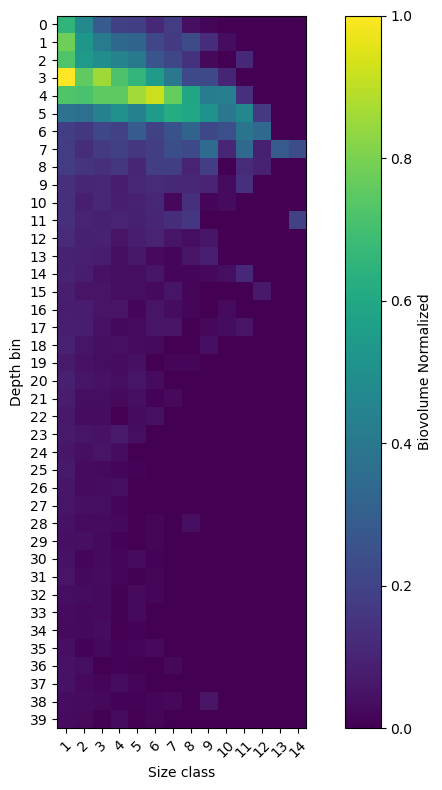

This is a sample of a padded Bioprofile, the way it gets put into the plot function.
⬇︎ This particular padding is static and only an example. ⬇︎


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.653745,0.470178,0.287066,0.188709,0.185985,0.113002,0.179574,0.041313,0.017411,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
# TODO  :   Load the dataset
# Replace 'your_dataset.csv' with the path to your actual dataset
import pandas as pd

df = pd.read_pickle('../Data/Biovolume_per_size_class_and_depth_updated.pkl')

# Perform any feature engineering steps
# Example: df['new_feature'] = df['feature1'] + df['feature2']

import matplotlib.pyplot as plt
import numpy as np

# 1. Biovolume-Spalten auswählen
size_cols = [col for col in df.columns if col.startswith("Biovolume ")]
# Remove three of the largest size bins
size_cols = size_cols[:-3]

# Normalisierung – kann man machen wird grafisch aber schon automatisch vom plot erledigt
df = normalize_by_profile_global_max(df, "Profile_id", size_cols)
# display(df.head(40))

# 2. Ein Profil auswählen
pid = "0000a_WMO5906623_recovery_profiles"   # hier deine echte Profile_id einsetzen
df_prof = df[df["Profile_id"] == pid].copy()

# 3. Nach Tiefe sortieren (wichtig für "saubere" y-Achse)
df_prof = df_prof.sort_values("depth_bin")

# 4. 2D-Array für die Heatmap bauen: (n_depth_bins x n_size_classes)
heatmap_data = df_prof[size_cols].to_numpy()  # Shape ~ (40, 17)

# 5. Plotten
fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(
    heatmap_data,
    aspect="equal",      # oder "equal" wenn du willst
    origin="upper"      # Tiefen von unten nach oben
)

# Achsen-Beschriftungen
ax.set_xlabel("Size class")
ax.set_ylabel("Depth bin")

# Optional: Ticks mit Spaltennamen
ax.set_xticks(np.arange(len(size_cols)))
ax.set_xticklabels(range(1, len(size_cols)+1), rotation=45)

ax.set_yticks(np.arange(len(df_prof["depth_bin"].unique())))
ax.set_yticklabels(sorted(df_prof["depth_bin"].unique()))

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Biovolume Normalized")

plt.tight_layout()

print(f"="*100)
print("This plot shows all 40 depth bins over 14 instead of 17 size classes of bio volume,\nhence the baselinemodel evaluated those classes 15-17 as insignificant.\nEach square represents a real datapoint.")
print("\n"+f"*"*5+"\n")
print("WE WILL HAVE TO DISTORED THIS PLOT INTO A SQUARE IMAGE WITHOUT LOSING DATA OR ROUNDING ERRORS.")
print("A 3:1 RATIO BETWEEN 'DEPTH BINS' AND 'SIZE CLASSES SHOULD DELIVER SUFFICIENT SQUARITY,\nWHILE 'ZERO'-PADDING ROWS AND COLUMNS TO REACH A PIXELPERFECT RESULT.")
print(f"="*100)

plt.show()

print(f"="*100)
print("This is a sample of a padded Bioprofile, the way it gets put into the plot function.\n⬇︎ This particular padding is static and only an example. ⬇︎")
print(f"="*100)
pd.DataFrame(pad_heatmap(heatmap_data)).head()



### Creating Heatmap Plots and Saving them to Files 

In [4]:
# TODO  :   Converting our input features into heatmaps and export them as an image dataset.

"""
This first part is for redundancy only.
It has been done in a differnet cell before but doesn't always travel.
So we keep it here for 'ease of use'.
"""

# Normalizing the size columns.
size_cols = [col for col in df.columns if col.startswith("Biovolume ")]
df = normalize_by_profile_global_max(df, "Profile_id", size_cols)

## --------------------------------------------------------- ##

"""
Here you are able to create the heatmap image output.
    pixels = [48, 144, 240] – are good choices and multiples of 16 (Columns/ Features)
            → 0·1·1·1·1·1·1·1·1·1·1·1·1·1·1·0 (one column padding on either side)

    - df: your dataframe
    - size_cols: how many biovolume size columns should be accounted for
    - out_dir: pick your output dir, this is more for putting out sample data so you don't overwrite your main dataset.
    - pixels: image square size
    - trim_px: cropping image by removing pixels along each side of the square → here you choose how many (by default there is always one line of pixels removed)
    - max_profiles: also more for test purposes
    - sig: sigma parameter of the gaussian filter of the cubic interpolation function

The full ⬇︎ image set creator uses a 240px square with 1px trim resulting in a 238px square heatmap.
The output you find in your '/Data/heatmaps/' directory. 
"""

# Creating and storing the feature-heatmaps in a directory of your choice (default: '/Data/heatmaps').

# TODO : Uncomment for final outpput!! ⬇︎

#save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_samples_10", pixels=48, trim_px=1, max_profiles=15, padding=[4,4,1,1], mp="gray", intrpl=None, gamma=1, sig=0.1)
#save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_samples_11", pixels=48, trim_px=1, max_profiles=15, padding=[4,4,1,1], mp="gray", intrpl="bilinear", gamma=0.8, sig=0.1)
#save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_samples_12", pixels=48, trim_px=1, max_profiles=15, padding=[4,4,1,1], mp="gray", intrpl="spline36", gamma=1, sig=0.7)
#save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_samples_20", pixels=48, trim_px=1, max_profiles=15, padding=[4,4,1,1], mp="turbo", intrpl=None, gamma=1, sig=0.1)
#save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_samples_21", pixels=48, trim_px=1, max_profiles=15, padding=[4,4,1,1], mp="turbo", intrpl="bilinear", gamma=0.8, sig=0.1)
#save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_samples_22", pixels=48, trim_px=1, max_profiles=15, padding=[4,4,1,1], mp="turbo", intrpl="spline36", gamma=1, sig=0.7)
#save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_samples_30", pixels=48, trim_px=1, max_profiles=15, padding=[4,4,1,1], intrpl=None, gamma=0.8, sig=0.1)
#save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_samples_31", pixels=48, trim_px=1, max_profiles=15, padding=[4,4,1,1], intrpl="bilinear", gamma=0.8, sig=0.1)
#save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_samples_32", pixels=48, trim_px=1, max_profiles=15, padding=[4,4,1,1], intrpl="spline36", gamma=1, sig=0.7)
# save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_10", pixels=45, trim_px=0, padding=[2,3,1,0], mp="gray")
# save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_00", pixels=48, trim_px=1, max_profiles=10, padding=[4,4,1,1], intrpl="bilinear", gamma=0.8)

# TODO  : Those are samples
# save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_00", pixels=45, trim_px=0, padding=[2,3,1,0])
# save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_10", pixels=45, trim_px=0, padding=[2,3,1,0], mp="gray")
# save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_20", pixels=45, trim_px=0, padding=[2,3,1,0], mp="inferno")
# save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_30", pixels=45, trim_px=0, padding=[2,3,1,0], mp="turbo")

# save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_01", pixels=48, trim_px=1, padding=[4,4,1,1])
# save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_02", pixels=48, trim_px=1, padding=[4,4,1,1], intrpl="bilinear")
# save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_03", pixels=48, trim_px=1, padding=[4,4,1,1], intrpl="bicubic")
# save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_04", pixels=96, trim_px=4, padding=[4,4,1,1], intrpl="bilinear")
# save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_05", pixels=48, trim_px=1, max_profiles=None, padding=[4,4,1,1], intrpl="bilinear", gamma=0.8)
# save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_06", pixels=48, trim_px=1, max_profiles=None, padding=[4,4,1,1], intrpl="bilinear", gamma=0.6)
# save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_07", pixels=48, trim_px=1, max_profiles=None, padding=[4,4,1,1], intrpl="bilinear", gamma=0.4)
# save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_25", pixels=48, trim_px=1, max_profiles=None, padding=[4,4,1,1], mp="inferno", intrpl="bilinear", gamma=0.8)
# save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_26", pixels=48, trim_px=1, max_profiles=None, padding=[4,4,1,1], mp="inferno", intrpl="bilinear", gamma=0.6)
# save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_27", pixels=48, trim_px=1, max_profiles=None, padding=[4,4,1,1], mp="inferno", intrpl="bilinear", gamma=0.4)
# save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_06", pixels=144, trim_px=12, padding=[4,4,1,1], intrpl="bilinear")
# save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_07", pixels=192, trim_px=16, padding=[4,4,1,1], intrpl="bilinear")
# save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_34", pixels=48, trim_px=1, padding=[4,4,1,1], mp="turbo", intrpl="bilinear")
# save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_35", pixels=48, trim_px=1, padding=[4,4,1,1], mp="turbo", intrpl="bicubic")

# =============final full dataset output ================
save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps", pixels=48, trim_px=1, max_profiles=None, padding=[4,4,1,1], intrpl="bilinear", gamma=0.8)

## First CNN: small heatmaps
-  workflow with small heatmaps & geographical & clster-stratified split

In [ ]:
# install if necessary:
#pip install imbalanced-learn pillow

In [5]:
#load libraries and set data directories
import numpy as np
import pandas as pd
import pickle
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GaussianNoise
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from PIL import Image
import warnings
warnings.filterwarnings('ignore')


# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Path attributes

DATA_DIR = Path("../Data")
HEATMAP_DIR = DATA_DIR / "heatmaps"

c:\Users\Sina\anaconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


### Functions for: data & heatmap loading, train/test splitting, balancing training data & scaling heatmap pixels

In [8]:

######################## initialize a class with attributes = data directories and files ###############################
# add every new function to this class

class HeatmapCNNClassifier:
    def __init__(self, data_dir=DATA_DIR, heatmap_dir=HEATMAP_DIR):
            self.data_dir = Path(data_dir)
            self.heatmap_dir = Path(heatmap_dir)
            self.train_test_file = self.data_dir / "Profile_id_to_train_test_cross_val_v2.pkl"
            self.clusters_file = self.data_dir / "Profile_id_to_clusters_4_and_6.pkl"
            self.scaler = StandardScaler()
            self.label_encoder = LabelEncoder()
        
######################## Load data assignments ###############################

def load_data_assignments(self):
    """Load data assignments from pickle files"""
    print("Loading data assignments...")
    
    # Load train/test and cross-validation assignments (DataFrame)
    with open(self.train_test_file, 'rb') as f:
        train_test_df = pickle.load(f)
    
    # Load cluster assignments (DataFrame)
    with open(self.clusters_file, 'rb') as f:
        clusters_df = pickle.load(f)
        clusters_df['cluster'] = clusters_df['cluster_4']       ######## change the number of clusters here as needed
    
    print(f"Train/test DataFrame shape: {train_test_df.shape}")
    print(f"Clusters DataFrame shape: {clusters_df.shape}")
    print(f"Train/test columns: {train_test_df.columns.tolist()}")
    print(f"Clusters columns:  {clusters_df.columns.tolist()}")
    
    # Convert DataFrames to dictionaries for easier lookup
    # Assuming Profile_id is the key column
    self.train_test_cv = {}
    for _, row in train_test_df.iterrows():
        profile_id = row['Profile_id']
        # Create dictionary with remaining columns
        self.train_test_cv[profile_id] = {col: row[col] for col in train_test_df.columns if col != 'Profile_id'}
    
    self.clusters = {}
    for _, row in clusters_df.iterrows():
        profile_id = row['Profile_id']
        # Assuming there's a cluster column - let's find it
        cluster_cols = [col for col in clusters_df.columns if col != 'Profile_id']
        if len(cluster_cols) == 1:
            self.clusters[profile_id] = row[cluster_cols[0]]
        else:
            # If multiple columns, store as dictionary
            self.clusters[profile_id] = {col: row[col] for col in cluster_cols}
    
    print(f"Loaded assignments for {len(self.train_test_cv)} profiles")
    print(f"Loaded cluster assignments for {len(self.clusters)} profiles")
    
    # Show sample data structure
    sample_profile = list(self.train_test_cv.keys())[0]
    print(f"Sample train/test data for profile {sample_profile}:  {self.train_test_cv[sample_profile]}")
    print(f"Sample cluster data for profile {sample_profile}:  {self.clusters[sample_profile]}")

# add the function to the class
HeatmapCNNClassifier.load_data_assignments = load_data_assignments

######################## Load heatmaps ###############################

def load_heatmaps(self):
    """Load heatmap images and create feature matrices"""
    print("Loading heatmap images...")
    
    # Get list of available heatmap files
    heatmap_files = list(self.heatmap_dir.glob("*.png"))
    print(f"Found {len(heatmap_files)} PNG files in {self.heatmap_dir}")
    
    if len(heatmap_files) == 0:
        raise FileNotFoundError(f"No PNG files found in {self.heatmap_dir}")
    
    # Extract profile IDs from filenames (remove .png extension)
    available_profile_ids = [f.stem for f in heatmap_files]
    
    # Debug: Show sample filenames and extracted profile IDs
    sample_files = heatmap_files[:5]
    sample_ids = [f.stem for f in sample_files]
    print(f"Sample filenames: {[f.name for f in sample_files]}")
    print(f"Sample extracted profile IDs: {sample_ids}")
    
    # Convert profile IDs to consistent format (strings)
    train_test_ids = set(str(k) for k in self.train_test_cv.keys())
    cluster_ids = set(str(k) for k in self.clusters.keys())
    filename_ids = set(str(id_) for id_ in available_profile_ids)
    
    print(f"Available profile IDs from filenames: {len(filename_ids)}")
    print(f"Profile IDs with train/test data: {len(train_test_ids)}")
    print(f"Profile IDs with cluster data:  {len(cluster_ids)}")
    
    # Find common profile IDs across all data sources
    common_with_train_test = filename_ids & train_test_ids
    common_with_clusters = filename_ids & cluster_ids
    common_all = filename_ids & train_test_ids & cluster_ids
    
    print(f"Files matching train/test IDs: {len(common_with_train_test)}")
    print(f"Files matching cluster IDs: {len(common_with_clusters)}")
    print(f"Files matching all data sources: {len(common_all)}")
    
    if len(common_all) == 0:
        print("\nDEBUGGING: No matching profile IDs found!")
        print("Sample IDs from each source:")
        print(f"Filenames: {list(filename_ids)[:5]}")
        print(f"Train/test:  {list(train_test_ids)[:5]}")
        print(f"Clusters: {list(cluster_ids)[:5]}")
        raise ValueError("No matching profile IDs found between files and metadata")
    
    common_ids = list(common_all)
    print(f"Found {len(common_ids)} profiles with complete data")
    
    # Load images and extract data
    X_data = []
    y_data = []
    profile_ids = []
    data_types = []
    cv_folds = []
    
    # Load a sample image to get dimensions
    sample_profile_id = common_ids[0]
    sample_img_path = self.heatmap_dir / f"{sample_profile_id}.png"
    sample_img = Image.open(sample_img_path)
    sample_array = np.array(sample_img)
    img_shape = sample_array.shape
    print(f"Image dimensions: {img_shape}")
    
    for profile_id_str in common_ids:
        # Convert string back to original type for dictionary lookup
        # Try both string and original type
        lookup_id = profile_id_str
        for original_id in self.train_test_cv.keys():
            if str(original_id) == profile_id_str:
                lookup_id = original_id
                break
        
        # Load image
        img_path = self.heatmap_dir / f"{profile_id_str}.png"
        img = Image.open(img_path)
        img_array = np.array(img)
        
        # Normalize pixel values to [0, 1]
        if img_array.dtype == np.uint8:
            img_array = img_array.astype(np.float32) / 255.0
        
        X_data.append(img_array)
        
        # Extract cluster assignment
        cluster_data = self.clusters[lookup_id]
        if isinstance(cluster_data, dict):
            # If cluster data is a dictionary, assume first value is the cluster
            y_data.append(list(cluster_data.values())[0])
        else:
            y_data.append(cluster_data)
        
        profile_ids.append(profile_id_str)
        data_types.append(self.train_test_cv[lookup_id]['data_type'])
        cv_folds.append(self.train_test_cv[lookup_id]['CV_fold'])
    
    self.X_data = np.array(X_data)
    self.y_data = np.array(y_data)
    self.profile_ids = np.array(profile_ids)
    self.data_types = np.array(data_types)
    self.cv_folds = np.array(cv_folds)
    
    print(f"Loaded {len(self.X_data)} heatmaps with shape {self.X_data.shape}")
    print(f"Unique clusters found: {np.unique(self.y_data)}")
    print(f"Data types found: {np.unique(self.data_types)}")
    print(f"CV folds found: {np.unique(self.cv_folds)}")

# add the function to the class
HeatmapCNNClassifier.load_heatmaps = load_heatmaps


######################## Train/test split ###############################

def split_train_test(self):
    """Split data into train and test sets based on pre-defined assignments"""
    print("Splitting data into train and test sets...")
    
    train_mask = self.data_types == 'train'
    test_mask = self.data_types == 'test'
    
    self.X_train = self.X_data[train_mask]
    self.y_train = self.y_data[train_mask]
    self.train_profile_ids = self.profile_ids[train_mask]
    self.train_cv_folds = self.cv_folds[train_mask]
    
    self.X_test = self.X_data[test_mask]
    self.y_test = self.y_data[test_mask]
    self.test_profile_ids = self.profile_ids[test_mask]
    
    print(f"Training set:  {len(self.X_train)} samples")
    print(f"Test set: {len(self.X_test)} samples")
    
    # Encode labels
    self.y_train_encoded = self.label_encoder.fit_transform(self.y_train)
    self.y_test_encoded = self.label_encoder.transform(self.y_test)
    self.n_classes = len(self.label_encoder.classes_)
    
    print(f"Number of classes: {self.n_classes}")
    print(f"Classes: {self.label_encoder.classes_}")

# add the function to the class
HeatmapCNNClassifier.split_train_test = split_train_test


######################## Balance classes per fold - SMOTE Tomek link ###############################

def balance_classes_per_fold_SMOTETomek(self):
    """Apply balancing within each CV fold separately"""
    print("Balancing classes per fold using SMOTETomek (SMOTE + Tomek links)...")
    
    unique_folds = np.unique(self.train_cv_folds)
    print(f"Processing {len(unique_folds)} folds:  {unique_folds}")
    
    # Store balanced data for each fold
    self.fold_balanced_data = {}
    
    for fold in unique_folds:
        print(f"\nBalancing fold:  {fold}")
        
        # Get training data for this fold (all other folds)
        val_mask = self.train_cv_folds == fold
        train_mask = ~val_mask
        
        X_train_fold = self.X_train[train_mask]
        y_train_fold = self.y_train_encoded[train_mask]
        
        print(f"Original fold {fold} training size: {len(X_train_fold)}")
        
        # Check if balancing is needed for this fold
        fold_counts = Counter(y_train_fold)
        min_count = min(fold_counts.values())
        max_count = max(fold_counts.values())
        
        if max_count / min_count > 1.5:  # Apply balancing if imbalanced
            # Reshape data for resampling (flatten images)
            X_train_fold_flat = X_train_fold.reshape(len(X_train_fold), -1)
            
            # Apply SMOTETomek
            smote_tomek = SMOTETomek(
                smote=SMOTE(random_state=42, k_neighbors=min(3, min_count-1)),
                tomek=TomekLinks(),
                random_state=42
            )
            
            X_train_balanced, y_train_balanced = smote_tomek.fit_resample(X_train_fold_flat, y_train_fold)
            
            # Reshape back to image format
            X_train_balanced = X_train_balanced.reshape((-1,) + X_train_fold.shape[1:])
            
            print(f"Balanced fold {fold} training size: {len(X_train_balanced)}")
            
            # Show distribution after balancing
            balanced_counts = Counter(y_train_balanced)
            for cluster_idx, count in sorted(balanced_counts.items()):
                cluster_name = self.label_encoder.classes_[cluster_idx]
                print(f"  Cluster {cluster_name}: {count} samples")
                
        else:
            print(f"Fold {fold} is already balanced, no resampling needed")
            X_train_balanced = X_train_fold
            y_train_balanced = y_train_fold
        
        # Store balanced data for this fold
        self.fold_balanced_data[fold] = {
            'X_train': X_train_balanced,
            'y_train': y_train_balanced,
            'X_val': self.X_train[val_mask],
            'y_val': self.y_train_encoded[val_mask]
        }

# add the function to the class
HeatmapCNNClassifier.balance_classes_per_fold_SMOTETomek = balance_classes_per_fold_SMOTETomek


######################## Balance classes per fold - Oversampling and undersampling ###############################

def balance_classes_per_fold_simple(self):
    """Apply simple over/undersampling to mean cluster size within each CV fold"""
    print("Balancing classes per fold using simple over/undersampling to mean...")
    
    unique_folds = np.unique(self.train_cv_folds)
    print(f"Processing {len(unique_folds)} folds: {unique_folds}")
    
    # Store balanced data for each fold
    self.fold_balanced_data = {}
    
    for fold in unique_folds: 
        print(f"\nBalancing fold: {fold}")
        
        # Get training data for this fold (all other folds)
        val_mask = self.train_cv_folds == fold
        train_mask = ~val_mask
        
        X_train_fold = self.X_train[train_mask]
        y_train_fold = self.y_train_encoded[train_mask]
        
        print(f"Original fold {fold} training size: {len(X_train_fold)}")
        
        # Calculate cluster distribution
        fold_counts = Counter(y_train_fold)
        total_samples = len(y_train_fold)
        n_clusters = len(fold_counts)
        target_per_cluster = total_samples // n_clusters  # Mean number per cluster
        
        print(f"Target samples per cluster: {target_per_cluster}")
        print("Original distribution:", dict(fold_counts))
        
        # Check if balancing is needed
        min_count = min(fold_counts.values())
        max_count = max(fold_counts.values())
        
        if max_count / min_count > 1.5:  # Apply balancing if imbalanced
            X_balanced_list = []
            y_balanced_list = []
            
            for cluster_idx in sorted(fold_counts.keys()):
                # Get all samples for this cluster
                cluster_mask = y_train_fold == cluster_idx
                X_cluster = X_train_fold[cluster_mask]
                y_cluster = y_train_fold[cluster_mask]
                
                current_count = len(X_cluster)
                cluster_name = self.label_encoder.classes_[cluster_idx]
                
                if current_count < target_per_cluster:
                    # OVERSAMPLE:  randomly duplicate samples to reach target
                    n_to_add = target_per_cluster - current_count
                    print(f"  Oversampling Cluster {cluster_name}:  {current_count} -> {target_per_cluster} (+{n_to_add})")
                    
                    # Randomly sample with replacement
                    oversample_indices = np.random.choice(len(X_cluster), 
                                                        size=n_to_add, 
                                                        replace=True)
                    X_oversampled = X_cluster[oversample_indices]
                    y_oversampled = y_cluster[oversample_indices]
                    
                    # Combine original + oversampled
                    X_cluster_balanced = np.vstack([X_cluster, X_oversampled])
                    y_cluster_balanced = np.concatenate([y_cluster, y_oversampled])
                    
                elif current_count > target_per_cluster:
                    # UNDERSAMPLE: randomly select subset to reach target
                    print(f"  Undersampling Cluster {cluster_name}: {current_count} -> {target_per_cluster} (-{current_count - target_per_cluster})")
                    
                    # Randomly sample without replacement
                    undersample_indices = np.random.choice(len(X_cluster), 
                                                        size=target_per_cluster, 
                                                        replace=False)
                    X_cluster_balanced = X_cluster[undersample_indices]
                    y_cluster_balanced = y_cluster[undersample_indices]
                    
                else:
                    # Already at target size
                    print(f"  Cluster {cluster_name}:  {current_count} (no change needed)")
                    X_cluster_balanced = X_cluster
                    y_cluster_balanced = y_cluster
                
                X_balanced_list.append(X_cluster_balanced)
                y_balanced_list.append(y_cluster_balanced)
            
            # Combine all balanced clusters
            X_train_balanced = np.vstack(X_balanced_list)
            y_train_balanced = np.concatenate(y_balanced_list)
            
            # Shuffle the balanced data
            shuffle_indices = np.random.permutation(len(X_train_balanced))
            X_train_balanced = X_train_balanced[shuffle_indices]
            y_train_balanced = y_train_balanced[shuffle_indices]
            
            print(f"Balanced fold {fold} training size: {len(X_train_balanced)}")
            
            # Show final distribution
            final_counts = Counter(y_train_balanced)
            for cluster_idx, count in sorted(final_counts.items()):
                cluster_name = self.label_encoder.classes_[cluster_idx]
                print(f"  Final Cluster {cluster_name}: {count} samples")
                
        else:
            print(f"Fold {fold} is already balanced, no resampling needed")
            X_train_balanced = X_train_fold
            y_train_balanced = y_train_fold
        
        # Store balanced data for this fold
        self.fold_balanced_data[fold] = {
            'X_train': X_train_balanced,
            'y_train': y_train_balanced,
            'X_val': self.X_train[val_mask],
            'y_val': self.y_train_encoded[val_mask]
        }
        
    print("\nSimple balancing complete!")

# add the function to the class
HeatmapCNNClassifier.balance_classes_per_fold_simple = balance_classes_per_fold_simple


######################## Scale heatmap pixel data ###############################

def scale_data(self):
    """Scale the heatmap pixel data to get mean = 0 and std = 1
    scaler is fitted on original training data only
    and then applied to test data and balanced fold data
    no data leakage occurs this way"""

    print("Scaling heatmap pixel data...")
    
    # Scale original training data for test set evaluation
    original_shape = self.X_train.shape
    X_train_flat = self.X_train.reshape(len(self.X_train), -1)
    X_test_flat = self.X_test.reshape(len(self.X_test), -1)
    
    print(type(self.scaler))  # What scaler is being used?
    
    # Fit scaler on original training data
    X_train_scaled = self.scaler.fit_transform(X_train_flat)
    X_test_scaled = self.scaler.transform(X_test_flat)
    
    # Reshape back to image format
    self.X_train_scaled = X_train_scaled.reshape(original_shape)
    self.X_test_scaled = X_test_scaled.reshape(self.X_test.shape)
    
    print(f"Scaled training data shape: {self.X_train_scaled.shape}")
    print(f"Scaled test data shape: {self.X_test_scaled.shape}")
    
    # Scale balanced data for each fold
    if hasattr(self, 'fold_balanced_data'):
        print("Scaling balanced fold data...")
        for fold in self.fold_balanced_data.keys():
            fold_data = self.fold_balanced_data[fold]
            
            # Scale training data for this fold
            X_train_fold_flat = fold_data['X_train'].reshape(len(fold_data['X_train']), -1)
            X_val_fold_flat = fold_data['X_val'].reshape(len(fold_data['X_val']), -1)
            
            # Use same scaler fitted on original training data
            X_train_fold_scaled = self.scaler.transform(X_train_fold_flat)
            X_val_fold_scaled = self.scaler.transform(X_val_fold_flat)
            
            # Reshape back to image format
            self.fold_balanced_data[fold]['X_train_scaled'] = X_train_fold_scaled.reshape((-1,) + fold_data['X_train'].shape[1:])
            self.fold_balanced_data[fold]['X_val_scaled'] = X_val_fold_scaled.reshape((-1,) + fold_data['X_val'].shape[1:])

# add the function to the class
HeatmapCNNClassifier.scale_data = scale_data
    

### Function for data augmentation with Gaussian Noise in 1 x 3 pixel-blocks (like the data points)

Found 5619 PNG heatmap files
Loaded solace_026_0.png:  shape (46, 46, 3)
  With block_size=3, this represents 15 datapoints along x-axis
Loaded ctd078_0_new.png:  shape (46, 46, 3)
  With block_size=3, this represents 15 datapoints along x-axis
Loaded 0131a_WMO6903095.png:  shape (46, 46, 3)
  With block_size=3, this represents 15 datapoints along x-axis
Loaded e1s21_4.png:  shape (46, 46, 3)
  With block_size=3, this represents 15 datapoints along x-axis


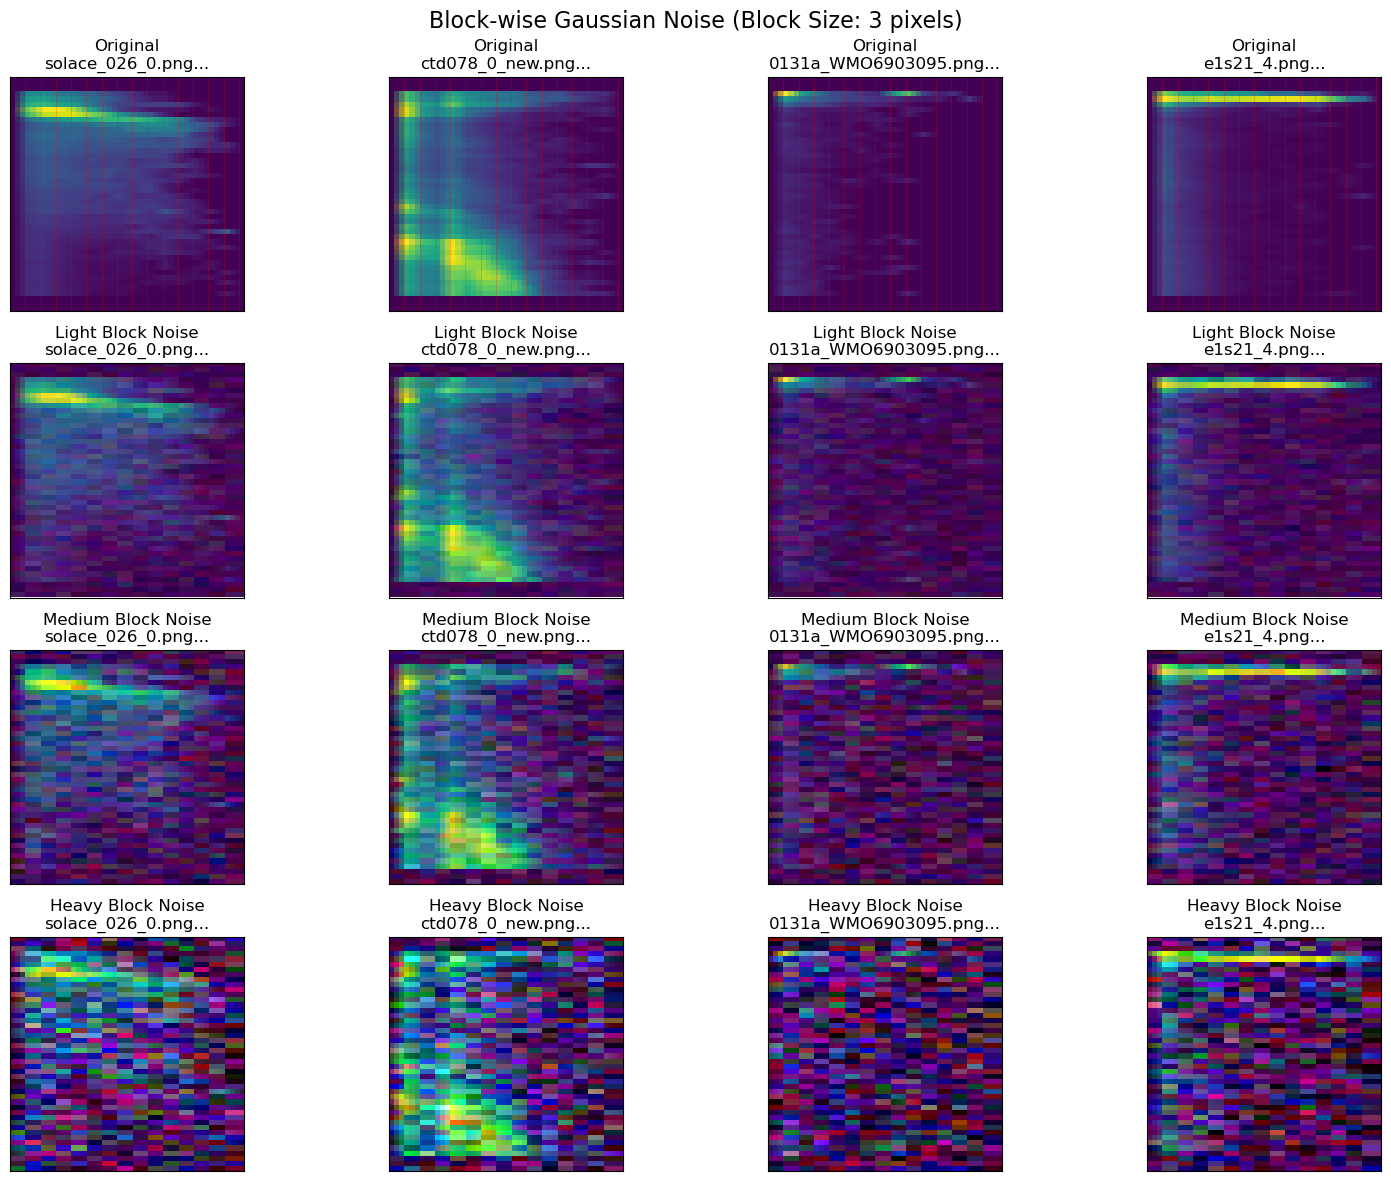


BLOCK-WISE NOISE ANALYSIS
Block size: 3 pixels per datapoint
Number of datapoints along x-axis: 15

Light Block Noise (σ = 0.05):
  Mean absolute difference: 0.0376
  Max absolute difference: 0.1608
  Within-block correlation: 0.996

Medium Block Noise (σ = 0.1):
  Mean absolute difference: 0.0751
  Max absolute difference: 0.3692
  Within-block correlation: 0.997

Heavy Block Noise (σ = 0.2):
  Mean absolute difference: 0.1451
  Max absolute difference: 0.6709
  Within-block correlation: 0.999


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import random
import os
from PIL import Image
import tensorflow as tf

def add_block_gaussian_noise(image, noise_level, block_size=3):
    """
    Add Gaussian noise in blocks of pixels along x-axis
    
    Parameters: 
    image (np.array): Input image 
    noise_level (float): Standard deviation of noise
    block_size (int): Number of pixels per block (default 3)
    """
    if noise_level == 0.0:
        return image
    
    height, width = image.shape[: 2]
    n_channels = image.shape[2] if len(image.shape) == 3 else 1
    
    # Calculate number of complete blocks along x-axis
    n_blocks = width // block_size
    effective_width = n_blocks * block_size
    
    # Create noise at the block level (one noise value per block)
    block_noise_shape = (height, n_blocks) + ((n_channels,) if n_channels > 1 else ())
    block_noise = np.random.normal(0, noise_level, block_noise_shape)
    
    # Expand each noise value to fill the entire block (repeat 3 times along x-axis)
    if n_channels > 1:
        # Multi-channel image
        pixel_noise = np.repeat(block_noise, block_size, axis=1)
        # Handle any remaining pixels if width is not divisible by block_size
        if effective_width < width:
            remaining_pixels = width - effective_width
            last_block_noise = block_noise[: , -1: , : ] 
            last_block_expanded = np.repeat(last_block_noise, remaining_pixels, axis=1)
            pixel_noise = np.concatenate([pixel_noise, last_block_expanded], axis=1)
    else:
        # Grayscale image
        pixel_noise = np.repeat(block_noise, block_size, axis=1)
        if effective_width < width:
            remaining_pixels = width - effective_width
            last_block_noise = block_noise[:, -1:]
            last_block_expanded = np.repeat(last_block_noise, remaining_pixels, axis=1)
            pixel_noise = np.concatenate([pixel_noise, last_block_expanded], axis=1)
    
    # Add noise to image and clip to valid range
    noisy_image = image + pixel_noise
    return np.clip(noisy_image, 0, 1)

def test_block_gaussian_noise(heatmap_dir="../Data/heatmaps", block_size=3):
    """
    Test block-wise Gaussian noise on PNG heatmap files
    """
    # Set random seed for reproducibility
    random.seed(42)
    np.random.seed(42)
    
    # Get random heatmap files
    heatmap_files = [f for f in os.listdir(heatmap_dir) if f.endswith('.png')]
    
    if len(heatmap_files) == 0:
        print(f"No .png files found in {heatmap_dir}")
        return
    
    print(f"Found {len(heatmap_files)} PNG heatmap files")
    selected_files = random.sample(heatmap_files, min(4, len(heatmap_files)))
    
    # Load and prepare heatmaps
    heatmaps = []
    for filename in selected_files:
        img_path = os.path.join(heatmap_dir, filename)
        img = Image.open(img_path)
        heatmap = np.array(img).astype(np.float32) / 255.0
        
        # Handle RGBA by removing alpha channel
        if len(heatmap.shape) == 3 and heatmap.shape[2] == 4:
            heatmap = heatmap[: , :, :3]
        
        print(f"Loaded {filename}:  shape {heatmap.shape}")
        print(f"  With block_size={block_size}, this represents {heatmap.shape[1]//block_size} datapoints along x-axis")
        heatmaps.append(heatmap)
    
    # Define noise levels
    noise_configs = [
        (0.0, "Original"),
        (0.05, "Light Block Noise"),  
        (0.1, "Medium Block Noise"),
        (0.2, "Heavy Block Noise")
    ]
    
    # Create plot
    fig, axes = plt.subplots(4, len(selected_files), figsize=(4*len(selected_files), 12))
    
    # Handle single file case
    if len(selected_files) == 1:
        axes = axes.reshape(-1, 1)
    
    for row, (noise_level, label) in enumerate(noise_configs):
        for col in range(len(selected_files)):
            # Apply block-wise noise
            display_data = add_block_gaussian_noise(heatmaps[col], noise_level, block_size)
            
            # Display the heatmap
            if len(display_data.shape) == 3 and display_data.shape[2] == 3:
                # RGB image
                axes[row, col].imshow(display_data)
            elif len(display_data.shape) == 3:
                # Multi-channel - average for display
                axes[row, col].imshow(np.mean(display_data, axis=-1), cmap='viridis')
            else:
                # Grayscale
                axes[row, col].imshow(display_data, cmap='viridis')
            
            axes[row, col].set_title(f"{label}\n{selected_files[col][:20]}...")
            axes[row, col].set_xticks([])
            axes[row, col].set_yticks([])
            
            # Add grid lines to show block structure (optional)
            if row == 0:  # Only on original images
                width = display_data.shape[1]
                for x in range(0, width, block_size):
                    axes[row, col].axvline(x - 0.5, color='red', alpha=0.3, linewidth=0.5)
    
    plt.suptitle(f'Block-wise Gaussian Noise (Block Size: {block_size} pixels)', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    # Print noise statistics
    print("\n" + "="*60)
    print("BLOCK-WISE NOISE ANALYSIS")
    print("="*60)
    print(f"Block size: {block_size} pixels per datapoint")
    
    original = heatmaps[0]
    n_datapoints = original.shape[1] // block_size
    print(f"Number of datapoints along x-axis: {n_datapoints}")
    
    for noise_level, label in noise_configs[1:]:
        noisy = add_block_gaussian_noise(original, noise_level, block_size)
        
        mean_diff = np.mean(np.abs(noisy - original))
        max_diff = np.max(np.abs(noisy - original))
        
        # Calculate noise correlation within blocks
        block_correlation = analyze_block_structure(original, noisy, block_size)
        
        print(f"\n{label} (σ = {noise_level}):")
        print(f"  Mean absolute difference: {mean_diff:.4f}")
        print(f"  Max absolute difference: {max_diff:.4f}")
        print(f"  Within-block correlation: {block_correlation:.3f}")

def analyze_block_structure(original, noisy, block_size):
    """Analyze correlation within blocks to verify block structure"""
    height, width = original.shape[:2]
    n_blocks = width // block_size
    
    correlations = []
    noise_diff = noisy - original
    
    for block_idx in range(n_blocks):
        start_x = block_idx * block_size
        end_x = start_x + block_size
        
        if end_x <= width:
            block_noise = noise_diff[:, start_x:end_x]
            
            # Calculate correlation between adjacent pixels in the block
            if block_size > 1:
                pixel1 = block_noise[:, 0].flatten()
                pixel2 = block_noise[:, 1].flatten()
                if len(pixel1) > 0 and len(pixel2) > 0:
                    correlation = np.corrcoef(pixel1, pixel2)[0, 1]
                    if not np.isnan(correlation):
                        correlations.append(correlation)
    
    return np.mean(correlations) if correlations else 0.0

# Test the block-wise noise
test_block_gaussian_noise(heatmap_dir=HEATMAP_DIR, block_size=3)

- noise of 0.05 looks good, the higher levels are too much
- note that noise is added in 3-pixel blocks, same as the datapoint representation

In [9]:
import tensorflow as tf
from tensorflow.keras.layers import Layer

class BlockGaussianNoise(Layer):
    """Custom layer for block-wise Gaussian noise augmentation"""
    
    def __init__(self, noise_level, block_size=3, seed=None, **kwargs):
        super(BlockGaussianNoise, self).__init__(**kwargs)
        self.noise_level = noise_level
        self.block_size = block_size
        self.seed = seed
        self.supports_masking = True
    
    def build(self, input_shape):
        super(BlockGaussianNoise, self).build(input_shape)
    
    def call(self, inputs, training=None):
        if training is None:
            training = tf.keras.backend.learning_phase()
        
        def apply_noise():
            # Get input shape
            input_shape = tf.shape(inputs)
            batch_size = input_shape[0]
            height = input_shape[1]
            width = input_shape[2]
            channels = input_shape[3]
            
            # Calculate number of blocks
            n_blocks = width // self.block_size
            effective_width = n_blocks * self.block_size
            
            # Generate noise at block level
            block_noise = tf.random.normal(
                shape=[batch_size, height, n_blocks, channels],
                stddev=self.noise_level,
                seed=self.seed
            )
            
            # Repeat noise for each pixel in the block
            pixel_noise = tf.repeat(block_noise, self.block_size, axis=2)
            
            # Handle remaining pixels if width not divisible by block_size
            if effective_width < width:
                remaining = width - effective_width
                last_block = block_noise[: , :, -1:, :]
                last_expanded = tf.repeat(last_block, remaining, axis=2)
                pixel_noise = tf.concat([pixel_noise, last_expanded], axis=2)
            else:
                # Ensure pixel_noise has the correct width
                pixel_noise = pixel_noise[:, :, :width, :]
            
            # Add noise to inputs
            return inputs + pixel_noise
        
        def no_noise():
            return inputs
        
        return tf.cond(tf.cast(training, tf.bool), apply_noise, no_noise)
    
    def compute_output_shape(self, input_shape):
        return input_shape
    
    def compute_output_spec(self, input_spec):
        return input_spec
    
    def get_config(self):
        config = {
            'noise_level': self.noise_level,
            'block_size': self.block_size,
            'seed': self.seed,
        }
        base_config = super(BlockGaussianNoise, self).get_config()
        return dict(list(base_config.items()) + list(config.items()))

# Add this to your class
HeatmapCNNClassifier.BlockGaussianNoise = BlockGaussianNoise


### Functions for: CNN model creation, compiling, cross-validation with pre-defined folds

In [10]:
######################## Create CNN model - tune model architecture here ###############################
#######################

# Adjust hyperparameters
learning_rate = 0.001
dropout_rate_conv = 0.25
dropout_rate_dense = 0.5
batch_size = 32
epochs = 100
patience = 10 # patience of early stopping callback
verbose_val = 1 # no output during training
k = 4 # number of folds for cross-validation
metrics_to_monitor = ['accuracy', ]

# augmentation parameters
noise_level = 0.075 # Gaussian noise level - data augmentation
block_size = 3 # Block size for block-wise noise

######################## Create CNN model architecture ###############################

def create_cnn_model(self, input_shape):
    """Create CNN model architecture"""
    print(f"Creating CNN model for input shape: {input_shape}")
    
    model = Sequential([

        # Input layer with block-wise Gaussian noise augmentation
        BlockGaussianNoise(noise_level, block_size, seed=42, input_shape=input_shape),

        # First convolutional block
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Dropout(dropout_rate_conv),
        
        # Second convolutional block
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Dropout(dropout_rate_conv),
        
        # Third convolutional block
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Dropout(dropout_rate_conv),
        
        # Fully connected layers
        Flatten(),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(dropout_rate_dense),

        Dense(256, activation='relu'),
        Dropout(dropout_rate_dense),

        Dense(self.n_classes, activation='softmax')         # Output layer for multi-class classification
    ])
    
    return model

# add the function to the class
HeatmapCNNClassifier.create_cnn_model = create_cnn_model


######################## Compile model ###############################

def compile_model(self, model):
    """Compile the CNN model"""
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=metrics_to_monitor
    )
    return model

# add the function to the class
HeatmapCNNClassifier.compile_model = compile_model


######################## Fit model once to each fold - cross-validate ###############################
def cross_validate(self):
    """Perform cross-validation using pre-defined folds with balanced data"""
    print("Starting cross-validation with balanced data...")
        
    unique_folds = list(self.fold_balanced_data.keys())
    print(f"Cross-validation folds: {unique_folds}")
    
    cv_results = {
        'balanced_accuracy': [],
        'macro_f1':  [],
        'fold_predictions':  [],
        'fold_true_labels': [],
        # Add training metrics tracking
        'train_loss': [],
        'train_accuracy': [],
        'val_loss': [],
        'val_accuracy': []
    }
    
    # Store individual fold results for confusion matrices
    self.cv_fold_results = []
    
    for fold in unique_folds:                            ### for-loop over folds
        print(f"\nProcessing fold:  {fold}")
        
        # Get balanced data for this fold
        fold_data = self.fold_balanced_data[fold]
        X_train_fold = fold_data['X_train_scaled']
        y_train_fold = fold_data['y_train']
        X_val_fold = fold_data['X_val_scaled']
        y_val_fold = fold_data['y_val']
        
        print(f"Fold {fold} - Train:  {len(X_train_fold)}, Val: {len(X_val_fold)}")
        
        # Convert to categorical: one-hot encoding of clusters for keras
        y_train_fold_cat = to_categorical(y_train_fold, self.n_classes)
        y_val_fold_cat = to_categorical(y_val_fold, self.n_classes)
        
        # Create and compile model
        model = self.create_cnn_model(X_train_fold.shape[1:])
        model = self.compile_model(model)
        
        # Set up callbacks
        early_stopping = EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)
        reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7) # reduce learning rate if no improvement (on plateau)
        
        # Train model
        history = model.fit(
            X_train_fold, y_train_fold_cat,
            validation_data=(X_val_fold, y_val_fold_cat),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=[early_stopping, reduce_lr],
            verbose=verbose_val
        )
        
        # Extract final training metrics from history
        final_train_loss = history.history['loss'][-1]
        final_train_accuracy = history.history['accuracy'][-1]
        final_val_loss = history.history['val_loss'][-1]
        final_val_accuracy = history.history['val_accuracy'][-1]
        
        # Store training metrics
        cv_results['train_loss'].append(final_train_loss)
        cv_results['train_accuracy'].append(final_train_accuracy)
        cv_results['val_loss'].append(final_val_loss)
        cv_results['val_accuracy'].append(final_val_accuracy)
        
        # Make predictions for additional metrics
        y_pred_proba = model.predict(X_val_fold, verbose=verbose_val)
        y_pred = np.argmax(y_pred_proba, axis=1)
        
        # Calculate additional validation metrics
        bal_acc = balanced_accuracy_score(y_val_fold, y_pred)
        macro_f1 = f1_score(y_val_fold, y_pred, average='macro')
        
        cv_results['balanced_accuracy'].append(bal_acc)
        cv_results['macro_f1'].append(macro_f1)
        cv_results['fold_predictions'].extend(y_pred)
        cv_results['fold_true_labels'].extend(y_val_fold)
        
        # Calculate training metrics on training data
        y_train_pred_proba = model.predict(X_train_fold, verbose=verbose_val)
        y_train_pred = np.argmax(y_train_pred_proba, axis=1)
        train_bal_acc = balanced_accuracy_score(y_train_fold, y_train_pred)
        train_macro_f1 = f1_score(y_train_fold, y_train_pred, average='macro')
        
        # Store individual fold results for confusion matrices
        fold_result = {
            'fold_name': fold,
            'y_true': y_val_fold,
            'y_pred': y_pred,
            'balanced_accuracy': bal_acc,
            'macro_f1':  macro_f1,
            'n_samples': len(y_val_fold),
            # Add training metrics to fold results
            'train_loss':  final_train_loss,
            'train_accuracy': final_train_accuracy,
            'train_balanced_accuracy': train_bal_acc,
            'train_macro_f1': train_macro_f1,
            'val_loss': final_val_loss,
            'val_accuracy': final_val_accuracy
        }
        self.cv_fold_results.append(fold_result)
        
        # Print comprehensive fold results
        print(f"Fold {fold} Results:")
        print(f"  Training   - Loss: {final_train_loss:.4f}, Accuracy: {final_train_accuracy:.4f}, Bal. Acc: {train_bal_acc:.4f}, F1: {train_macro_f1:.4f}")
        print(f"  Validation - Loss: {final_val_loss:.4f}, Accuracy: {final_val_accuracy:.4f}, Bal.Acc: {bal_acc:.4f}, F1: {macro_f1:.4f}")
        
    self.cv_results = cv_results
    self.print_cv_results()

# Add the updated function to the class
HeatmapCNNClassifier.cross_validate = cross_validate

######################## Print CV results (integrated in cross_validate) ###############################

def print_cv_results(self):
    """Print comprehensive cross-validation results including training metrics"""
    
    print("\n" + "="*80)
    print("CROSS-VALIDATION RESULTS SUMMARY")
    print("="*80)
    
    # Validation metrics
    bal_acc_mean = np.mean(self.cv_results['balanced_accuracy'])
    bal_acc_std = np.std(self.cv_results['balanced_accuracy'])
    f1_mean = np.mean(self.cv_results['macro_f1'])
    f1_std = np.std(self.cv_results['macro_f1'])
    val_loss_mean = np.mean(self.cv_results['val_loss'])
    val_loss_std = np.std(self.cv_results['val_loss'])
    val_acc_mean = np.mean(self.cv_results['val_accuracy'])
    val_acc_std = np.std(self.cv_results['val_accuracy'])
    
    # Training metrics
    train_loss_mean = np.mean(self.cv_results['train_loss'])
    train_loss_std = np.std(self.cv_results['train_loss'])
    train_acc_mean = np.mean(self.cv_results['train_accuracy'])
    train_acc_std = np.std(self.cv_results['train_accuracy'])
    
    # Calculate training balanced accuracy and F1 from fold results
    train_bal_accs = [fold['train_balanced_accuracy'] for fold in self.cv_fold_results]
    train_f1s = [fold['train_macro_f1'] for fold in self.cv_fold_results]
    train_bal_acc_mean = np.mean(train_bal_accs)
    train_bal_acc_std = np.std(train_bal_accs)
    train_f1_mean = np.mean(train_f1s)
    train_f1_std = np.std(train_f1s)
    
    print("TRAINING METRICS (average across folds):")
    print(f"  Loss:                 {train_loss_mean:.4f} ± {train_loss_std:.4f}")
    print(f"  Accuracy:            {train_acc_mean:.4f} ± {train_acc_std:.4f}")
    print(f"  Balanced Accuracy:   {train_bal_acc_mean:.4f} ± {train_bal_acc_std:.4f}")
    print(f"  Macro F1 Score:      {train_f1_mean:.4f} ± {train_f1_std:.4f}")
    
    print("\nVALIDATION METRICS (average across folds):")
    print(f"  Loss:                {val_loss_mean:.4f} ± {val_loss_std:.4f}")
    print(f"  Accuracy:            {val_acc_mean:.4f} ± {val_acc_std:.4f}")
    print(f"  Balanced Accuracy:   {bal_acc_mean:.4f} ± {bal_acc_std:.4f}")
    print(f"  Macro F1 Score:      {f1_mean:.4f} ± {f1_std:.4f}")
    
    # Calculate overfitting indicators
    accuracy_gap = train_acc_mean - val_acc_mean
    loss_gap = val_loss_mean - train_loss_mean  # Higher validation loss indicates overfitting
    bal_acc_gap = train_bal_acc_mean - bal_acc_mean
    
    print("\nOVERFITTING ANALYSIS:")
    print(f"  Accuracy Gap (train - val):     {accuracy_gap:.4f}")
    print(f"  Loss Gap (val - train):         {loss_gap:.4f}")
    print(f"  Bal. Accuracy Gap (train - val): {bal_acc_gap:.4f}")
    
    if accuracy_gap > 0.1:
        print("  ⚠️  Large accuracy gap suggests overfitting")
    elif accuracy_gap < 0.02:
        print("  ✅ Good generalization (low accuracy gap)")
    else:
        print("  ➡️  Moderate accuracy gap")
    
    print("\nPER-FOLD BREAKDOWN:")
    print("Fold      | Train Acc | Val Acc | Train F1 | Val F1  | Train Loss | Val Loss")
    print("-"*75)
    for i, fold_result in enumerate(self.cv_fold_results):
        fold_name = fold_result['fold_name']
        train_acc = fold_result['train_accuracy']
        val_acc = fold_result['balanced_accuracy']  # Using balanced accuracy for validation
        train_f1 = fold_result['train_macro_f1']
        val_f1 = fold_result['macro_f1']
        train_loss = fold_result['train_loss']
        val_loss = fold_result['val_loss']
        
        print(f"{fold_name: <9} | {train_acc:.4f}    | {val_acc:.4f}  | {train_f1:.4f}   | {val_f1:.4f}  | {train_loss:.4f}     | {val_loss:.4f}")

# add the function to the class
HeatmapCNNClassifier.print_cv_results = print_cv_results


######################## Confusion Matrix Function ###############################

def plot_cv_fold_confusion_matrices(self, k=k):
    """
    Plot normalized confusion matrices for each CV fold
    
    Parameters:  
    k (int): Number of folds to display (default 4)
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.metrics import confusion_matrix
    import numpy as np
    
    if not hasattr(self, 'cv_results'):
        print("Error: No cross-validation results found.  Run cross_validate() first.")
        return
    
    if not hasattr(self, 'cv_fold_results'):
        print("Error: Individual fold results not available.")
        print("Make sure you're using the updated cross_validate() method.")
        return
    
    n_folds = min(k, len(self.cv_fold_results))
    
    # Set up the subplot grid (2x2 for 4 folds)
    if n_folds <= 2:
        fig, axes = plt.subplots(1, n_folds, figsize=(7*n_folds, 6))
        if n_folds == 1:
            axes = [axes]
    else:
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        axes = axes.flatten()
    
    # Color map for consistency
    cmap = 'Blues'
    
    print("\n" + "="*60)
    print("CV FOLD CONFUSION MATRIX SUMMARY")
    print("="*60)
    
    for fold_idx in range(n_folds):
        ax = axes[fold_idx]
        
        # Get predictions and true labels for this fold
        fold_result = self.cv_fold_results[fold_idx]
        y_true_fold = fold_result['y_true']
        y_pred_fold = fold_result['y_pred']
        fold_name = fold_result['fold_name']
        
        # Calculate confusion matrix
        cm = confusion_matrix(y_true_fold, y_pred_fold)
        
        # Normalize confusion matrix (row-wise normalization)
        cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        
        # Handle any NaN values (in case a class has 0 samples)
        cm_normalized = np.nan_to_num(cm_normalized)
        
        # Create heatmap
        sns.heatmap(cm_normalized, 
                   annot=True, 
                   fmt='.2f', 
                   cmap=cmap,
                   ax=ax,
                   xticklabels=self.label_encoder.classes_,
                   yticklabels=self.label_encoder.classes_,
                   vmin=0, 
                   vmax=1,
                   cbar_kws={'label': 'Normalized Count'})
        
        # Calculate accuracy for this fold
        accuracy = fold_result['balanced_accuracy']
        macro_f1 = fold_result['macro_f1']
        
        ax.set_title(f'{fold_name}\nBal.  Acc: {accuracy:.3f}, F1: {macro_f1:.3f}')
        ax.set_xlabel('Predicted Cluster')
        ax.set_ylabel('True Cluster')
        
        # Print summary for this fold
        print(f"\n{fold_name}:")
        print(f"  Samples: {fold_result['n_samples']}")
        print(f"  Balanced Accuracy: {accuracy:.3f}")
        print(f"  Macro F1: {macro_f1:.3f}")
        
        # Per-class statistics
        print("  Per-class recall (diagonal values):")
        for class_idx, class_name in enumerate(self.label_encoder.classes_):
            if class_idx < len(cm_normalized):
                recall = cm_normalized[class_idx, class_idx]
                print(f"    Cluster {class_name}: {recall:.3f}")
    
    # Hide any unused subplots
    if n_folds < len(axes):
        for idx in range(n_folds, len(axes)):
            axes[idx].axis('off')
    
    plt.suptitle('Normalized Confusion Matrices by CV Fold', fontsize=16, y=0.98)
    plt.tight_layout()
    plt.show()
    
    # Overall summary
    print(f"\n" + "="*60)
    print("OVERALL CV SUMMARY")
    print("="*60)
    all_accuracies = [fold['balanced_accuracy'] for fold in self.cv_fold_results]
    all_f1s = [fold['macro_f1'] for fold in self.cv_fold_results]
    
    print(f"Mean Balanced Accuracy: {np.mean(all_accuracies):.3f} ± {np.std(all_accuracies):.3f}")
    print(f"Mean Macro F1: {np.mean(all_f1s):.3f} ± {np.std(all_f1s):.3f}")

# Add the function to the class
HeatmapCNNClassifier.plot_cv_fold_confusion_matrices = plot_cv_fold_confusion_matrices


### Main function - full pipeline

In [11]:
######################### Full Pipeline Function ###############################
def run_full_pipeline(self):
    """Run the complete pipeline"""
    print("Starting Heatmap CNN Classification Pipeline")
    print("=" * 50)
    
    # Step 1: Load data
    self.load_data_assignments()
    self.load_heatmaps()
    
    # Step 2: Split train/test
    self.split_train_test()
    
    # Step 4: Balance classes per fold
    #self.balance_classes_per_fold_SMOTETomek() # alternative: use SMOTE Tomek Link
    self.balance_classes_per_fold_simple()

    # Step 5: Scale data
    self.scale_data()
    
    # Step 6: Cross-validation
    self.cross_validate()

    # Step 7: Plot CV confusion matrices
    self.plot_cv_fold_confusion_matrices()
            
    print("\nPipeline completed successfully!")

# add the function to the class
HeatmapCNNClassifier.run_full_pipeline = run_full_pipeline


### Run pipeline

In [12]:
classifier = HeatmapCNNClassifier()
# classifier.run_full_pipeline()

# Hyperparameter Tuning

[Discuss any hyperparameter tuning methods you've applied, such as Grid Search or Random Search, and the rationale behind them.]


in anaconda prompt, install ray tune: pip install "ray[tune]" optuna

In [85]:
######################## Initialize classifier and load all data ###############################

print("🚀 Initializing HeatmapCNNClassifier and loading data...")

# Initialize the classifier
classifier = HeatmapCNNClassifier()

# Load data assignments (pickle files)
print("\n📁 Step 1: Loading data assignments...")
classifier.load_data_assignments()

# Load heatmap images
print("\n🖼️ Step 2: Loading heatmap images...")
classifier.load_heatmaps()

# Split into train/test sets
print("\n📊 Step 3: Splitting train/test data...")
classifier.split_train_test()

# Balance classes per fold
print("\n⚖️ Step 4: Balancing classes per fold...")
# Choose one of the balancing methods:
# Option 1: Simple over/undersampling (faster, more predictable)
classifier.balance_classes_per_fold_simple()

# Option 2:  SMOTE-Tomek (more sophisticated but slower)
# classifier.balance_classes_per_fold_SMOTETomek()

# Scale the data
print("\n📏 Step 5: Scaling pixel data...")
classifier.scale_data()

# Verify everything is set up correctly
print("\n✅ Data setup verification:")
print(f"  Training data shape: {classifier.X_train_scaled.shape}")
print(f"  Test data shape: {classifier.X_test_scaled.shape}")
print(f"  Number of classes: {classifier.n_classes}")
print(f"  Class labels: {classifier.label_encoder.classes_}")
print(f"  CV folds available: {list(classifier.fold_balanced_data.keys())}")
print(f"  fold_balanced_data structure: ✅ Ready for optimization")

# Show sample fold data to verify structure
sample_fold = list(classifier.fold_balanced_data.keys())[0]
sample_data = classifier.fold_balanced_data[sample_fold]
print(f"\n📋 Sample fold ({sample_fold}) data:")
print(f"  X_train_scaled shape: {sample_data['X_train_scaled'].shape}")
print(f"  y_train shape: {sample_data['y_train'].shape}")
print(f"  X_val_scaled shape: {sample_data['X_val_scaled'].shape}")
print(f"  y_val shape: {sample_data['y_val'].shape}")

print("\n🎯 Classifier is now ready for hyperparameter optimization!")
print("You can now run:")
print("  best_config, results = classifier.optimize_hyperparameters_smart()")

🚀 Initializing HeatmapCNNClassifier and loading data...

📁 Step 1: Loading data assignments...
Loading data assignments...
Train/test DataFrame shape: (5619, 3)
Clusters DataFrame shape: (5619, 4)
Train/test columns: ['Profile_id', 'data_type', 'CV_fold']
Clusters columns:  ['Profile_id', 'cluster', 'cluster_4', 'cluster_6']
Loaded assignments for 5619 profiles
Loaded cluster assignments for 5619 profiles
Sample train/test data for profile s033:  {'data_type': 'test', 'CV_fold': ''}
Sample cluster data for profile s033:  {'cluster': 1, 'cluster_4': 1, 'cluster_6': 2}

🖼️ Step 2: Loading heatmap images...
Loading heatmap images...
Found 5619 PNG files in ..\Data\heatmaps
Sample filenames: ['0000a_WMO5906623_recovery_profiles.png', '0002a_WMO5906623_recovery_profiles.png', '0003a_WMO5906623_recovery_profiles.png', '0003a_WMO6904139_recovery.png', '0004a_WMO6903096.png']
Sample extracted profile IDs: ['0000a_WMO5906623_recovery_profiles', '0002a_WMO5906623_recovery_profiles', '0003a_WMO59

### Functions for Ray Tune optuna tuning

In [86]:
######################## Complete Pure Optuna CNN Optimization ###############################

import optuna
import numpy as np
import pandas as pd
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Dropout, Flatten, Dense
from sklearn.metrics import balanced_accuracy_score, f1_score
import uuid
import gc

######################## Optimized CNN model creation for Optuna ###############################

def create_optuna_cnn_model(self, input_shape, config):
    """Create CNN model with Optuna-optimized hyperparameters"""
    
    print(f"Creating Optuna CNN model with input shape: {input_shape}")
    
    model = Sequential([
        # Input layer with optimized noise augmentation
        BlockGaussianNoise(config["noise_level"], config["block_size"], seed=42, input_shape=input_shape),

        # First convolutional block with optimized filters
        Conv2D(config["conv_filters_1"], (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(config["conv_filters_1"], (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Dropout(config["dropout_rate_conv"]),
        
        # Second convolutional block with optimized filters
        Conv2D(config["conv_filters_2"], (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(config["conv_filters_2"], (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Dropout(config["dropout_rate_conv"]),
        
        # Third convolutional block with optimized filters
        Conv2D(config["conv_filters_3"], (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(config["conv_filters_3"], (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Dropout(config["dropout_rate_conv"]),
        
        # Fully connected layers with optimized sizes
        Flatten(),
        Dense(config["dense_units_1"], activation='relu'),
        BatchNormalization(),
        Dropout(config["dropout_rate_dense"]),

        Dense(config["dense_units_2"], activation='relu'),
        Dropout(config["dropout_rate_dense"]),

        Dense(self.n_classes, activation='softmax')
    ])
    
    return model

# Add to class
HeatmapCNNClassifier.create_optuna_cnn_model = create_optuna_cnn_model

######################## Pure Optuna optimization function ###############################

def optimize_cnn_with_optuna(self, num_trials=30, max_epochs=25, cv_fold=None, timeout_minutes=60):
    """
    Pure Optuna CNN hyperparameter optimization
    
    Parameters:
    -----------
    num_trials : int
        Number of trials to run
    max_epochs : int
        Maximum epochs per trial
    cv_fold : str or None
        Specific CV fold to use, or None for first fold
    timeout_minutes : int
        Maximum time to run optimization (in minutes)
    """
    
    print("🎯 Starting Pure Optuna CNN Optimization...")
    print(f"  Trials: {num_trials}")
    print(f"  Max epochs per trial: {max_epochs}")
    print(f"  Timeout: {timeout_minutes} minutes")
    
    # Prepare data
    if not hasattr(self, 'fold_balanced_data') or not self.fold_balanced_data:
        raise ValueError("No fold_balanced_data found.  Run the full pipeline first.")
    
    # Select fold for optimization
    if cv_fold is None:
        fold_key = list(self.fold_balanced_data.keys())[0]
    else:
        fold_key = cv_fold
        if fold_key not in self.fold_balanced_data:
            raise ValueError(f"Fold {cv_fold} not found. Available:  {list(self.fold_balanced_data.keys())}")
    
    fold_data = self.fold_balanced_data[fold_key]
    
    X_train = fold_data['X_train_scaled']
    y_train = fold_data['y_train']
    X_val = fold_data['X_val_scaled']
    y_val = fold_data['y_val']
    
    print(f"Using fold:  {fold_key}")
    print(f"Training data:  {X_train.shape}")
    print(f"Validation data: {X_val.shape}")
    print(f"Number of classes: {self.n_classes}")
    
    # Convert labels to categorical
    y_train_cat = to_categorical(y_train, self.n_classes)
    y_val_cat = to_categorical(y_val, self.n_classes)
    
    # Define Optuna objective function
    def objective(trial):
        """Optuna objective function for CNN hyperparameter optimization"""
        
        trial_num = trial.number + 1
        print(f"\n🔬 Trial {trial_num}/{num_trials}")
        
        # Suggest hyperparameters
        config = {
            # Core training parameters
            "learning_rate":  trial.suggest_float("learning_rate", 1e-5, 1e-2, log=True),
            "batch_size": trial.suggest_categorical("batch_size", [16, 32, 64, 128]),
            
            # Dropout parameters
            "dropout_rate_conv": trial.suggest_float("dropout_rate_conv", 0.1, 0.5),
            "dropout_rate_dense": trial.suggest_float("dropout_rate_dense", 0.3, 0.7),
            
            # Architecture parameters - Conv layers
            "conv_filters_1": trial.suggest_categorical("conv_filters_1", [16, 24, 32, 48]),
            "conv_filters_2":  trial.suggest_categorical("conv_filters_2", [32, 48, 64, 96]),
            "conv_filters_3": trial.suggest_categorical("conv_filters_3", [64, 96, 128, 192]),
            
            # Architecture parameters - Dense layers
            "dense_units_1": trial.suggest_categorical("dense_units_1", [256, 384, 512, 768]),
            "dense_units_2": trial.suggest_categorical("dense_units_2", [128, 192, 256, 384]),
            
            # Augmentation parameters
            "noise_level": trial.suggest_float("noise_level", 0.01, 0.15),
            "block_size":  trial.suggest_categorical("block_size", [2, 3, 4]),
            
            # Learning rate schedule parameters
            "lr_reduction_factor": trial.suggest_float("lr_reduction_factor", 0.3, 0.7),
            "lr_patience": trial.suggest_categorical("lr_patience", [3, 5, 7, 10]),
            "early_stop_patience": trial.suggest_categorical("early_stop_patience", [8, 10, 12, 15]),
        }
        
        print(f"  LR: {config['learning_rate']:.6f}")
        print(f"  Batch size: {config['batch_size']}")
        print(f"  Conv filters: [{config['conv_filters_1']}, {config['conv_filters_2']}, {config['conv_filters_3']}]")
        print(f"  Dense units: [{config['dense_units_1']}, {config['dense_units_2']}]")
        print(f"  Dropout:  Conv={config['dropout_rate_conv']:.3f}, Dense={config['dropout_rate_dense']:.3f}")
        
        try:
            # Create model with current configuration
            model = self.create_optuna_cnn_model(X_train.shape[1:], config)
            
            # Compile model with suggested parameters
            optimizer = Adam(learning_rate=config["learning_rate"])
            model.compile(
                optimizer=optimizer,
                loss='categorical_crossentropy',
                metrics=['accuracy']
            )
            
            # Setup callbacks with suggested parameters
            callbacks = [
                EarlyStopping(
                    monitor='val_loss',
                    patience=config["early_stop_patience"],
                    restore_best_weights=True,
                    verbose=0
                ),
                ReduceLROnPlateau(
                    monitor='val_loss',
                    factor=config["lr_reduction_factor"],
                    patience=config["lr_patience"],
                    min_lr=1e-7,
                    verbose=0
                )
            ]
            
            # Train model
            print(f"  Training for up to {max_epochs} epochs...")
            history = model.fit(
                X_train, y_train_cat,
                validation_data=(X_val, y_val_cat),
                epochs=max_epochs,
                batch_size=config["batch_size"],
                callbacks=callbacks,
                verbose=0
            )
            
            # Calculate metrics
            if len(history.history['val_loss']) == 0:
                print(f"  ❌ No training history available")
                return 0.0
            
            # Get predictions
            y_pred_proba = model.predict(X_val, verbose=0)
            y_pred = np.argmax(y_pred_proba, axis=1)
            
            # Calculate performance metrics
            balanced_acc = balanced_accuracy_score(y_val, y_pred)
            macro_f1 = f1_score(y_val, y_pred, average='macro')
            best_val_loss = min(history.history['val_loss'])
            epochs_trained = len(history.history['loss'])
            
            # Calculate overfitting metric
            final_train_loss = history.history['loss'][-1]
            final_val_loss = history.history['val_loss'][-1]
            overfitting_gap = final_val_loss - final_train_loss
            
            print(f"  ✅ Results:  Acc={balanced_acc:.4f}, F1={macro_f1:.4f}, Loss={best_val_loss:.4f}")
            print(f"     Epochs:  {epochs_trained}, Overfitting gap: {overfitting_gap:.4f}")
            
            # Store additional metrics in trial user attributes for later analysis
            trial.set_user_attr('macro_f1', macro_f1)
            trial.set_user_attr('val_loss', best_val_loss)
            trial.set_user_attr('epochs_trained', epochs_trained)
            trial.set_user_attr('overfitting_gap', overfitting_gap)
            
            # Cleanup model to free memory
            del model
            gc.collect()
            
            # Return balanced accuracy as the optimization target
            return balanced_acc
            
        except Exception as e: 
            print(f"  ❌ Trial failed: {str(e)}")
            # Cleanup in case of error
            try:
                del model
                gc.collect()
            except:
                pass
            return 0.0
    
    # Create and configure Optuna study
    study_name = f'cnn_optimization_{uuid.uuid4().hex[:8]}'
    
    # Use MedianPruner to stop unpromising trials early
    pruner = optuna.pruners.MedianPruner(
        n_startup_trials=5,      # Don't prune first 5 trials
        n_warmup_steps=5,        # Wait 5 steps before starting to prune
        interval_steps=2         # Check every 2 steps
    )
    
    study = optuna.create_study(
        direction='maximize',
        study_name=study_name,
        storage=None,  # In-memory storage
        pruner=pruner
    )
    
    print(f"\n🚀 Starting optimization study: {study_name}")
    
    # Run optimization
    try:
        study.optimize(
            objective, 
            n_trials=num_trials,
            timeout=timeout_minutes * 60,  # Convert to seconds
            show_progress_bar=True,
            gc_after_trial=True  # Force garbage collection after each trial
        )
        
    except KeyboardInterrupt:
        print("\n⚠️  Optimization interrupted by user")
    except Exception as e:
        print(f"\n❌ Optimization failed: {e}")
        return None, None
    
    # Analyze results
    print(f"\n📊 OPTIMIZATION COMPLETED")
    print(f"  Completed trials: {len(study.trials)}")
    print(f"  Pruned trials: {len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED])}")
    print(f"  Failed trials: {len([t for t in study.trials if t.state == optuna.trial.TrialState.FAIL])}")
    
    if study.best_trial is None:
        print("❌ No successful trials found")
        return None, None
    
    # Get best results
    best_trial = study. best_trial
    best_params = best_trial.params
    best_score = best_trial.value
    
    print(f"\n🏆 BEST CONFIGURATION FOUND:")
    print(f"  Balanced Accuracy: {best_score:.4f}")
    if 'macro_f1' in best_trial.user_attrs:
        print(f"  Macro F1: {best_trial.user_attrs['macro_f1']:.4f}")
        print(f"  Validation Loss: {best_trial.user_attrs['val_loss']:.4f}")
        print(f"  Epochs Trained: {best_trial.user_attrs['epochs_trained']}")
        print(f"  Overfitting Gap: {best_trial.user_attrs['overfitting_gap']:.4f}")
    
    print(f"\n🎯 OPTIMIZED HYPERPARAMETERS:")
    for key, value in best_params. items():
        print(f"  {key}: {value}")
    
    # Show parameter importance
    if len(study.trials) >= 10:  # Need enough trials for importance analysis
        try:
            importance = optuna.importance.get_param_importances(study)
            print(f"\n📈 PARAMETER IMPORTANCE (top 5):")
            for param, imp in sorted(importance.items(), key=lambda x: x[1], reverse=True)[:5]:
                print(f"  {param}: {imp:.3f}")
        except Exception as e:
            print(f"  Could not calculate parameter importance: {e}")
    
    # Show top 5 trials
    successful_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
    if len(successful_trials) >= 5:
        top_trials = sorted(successful_trials, key=lambda t: t.value or 0, reverse=True)[:5]
        print(f"\n🏅 TOP 5 TRIALS:")
        for i, trial in enumerate(top_trials):
            score = trial.value or 0
            f1 = trial.user_attrs.get('macro_f1', 'N/A')
            epochs = trial.user_attrs.get('epochs_trained', 'N/A')
            print(f"  {i+1}. Trial #{trial.number}:  Acc={score:.4f}, F1={f1}, Epochs={epochs}")
    
    # Store results in classifier
    self.optuna_study = study
    self.best_optuna_params = best_params
    self.best_optuna_config = best_params  # For compatibility
    
    print(f"\n✅ Optimization complete!")
    
    return best_params, study


# Add all functions to the class
HeatmapCNNClassifier.create_optuna_cnn_model = create_optuna_cnn_model
HeatmapCNNClassifier.optimize_cnn_with_optuna = optimize_cnn_with_optuna


######################## Ready to run - Usage Example ###############################

print("✅ Pure Optuna CNN optimization loaded!")
print("\n🚀 Ready to optimize your CNN!")
print("\nTo run optimization:")
print("  best_params, study = classifier.optimize_cnn_with_optuna()")

# You can now run: 
# best_params, study = classifier.optimize_cnn_with_optuna(num_trials=30, max_epochs=25)

✅ Pure Optuna CNN optimization loaded!

🚀 Ready to optimize your CNN!

To run optimization:
  best_params, study = classifier.optimize_cnn_with_optuna()


In [ ]:
# Run the optimization (this will take a while)
best_params, study = classifier.optimize_cnn_with_optuna(
    num_trials=30,        # Number of different configurations to try
    max_epochs=25,        # Maximum epochs per trial
    timeout_minutes=120   # Stop after 2 hours max
)

# Save the best configuration: 
import pickle
save_directory = '../Data/'
with open(save_directory + 'optimal_config.pkl', 'wb') as f: # 4 clusters config: 'optimal_config_6_clusters.pkl'
    pickle.dump(classifier.best_optuna_params, f)

[I 2026-01-08 17:51:03,625] A new study created in memory with name: cnn_optimization_11635443


🎯 Starting Pure Optuna CNN Optimization...
  Trials: 30
  Max epochs per trial: 25
  Timeout: 120 minutes
Using fold:  fold_1
Training data:  (3150, 46, 46, 3)
Validation data: (1063, 46, 46, 3)
Number of classes: 6

🚀 Starting optimization study: cnn_optimization_11635443


  0%|          | 0/30 [00:00<?, ?it/s]


🔬 Trial 1/30
  LR: 0.000271
  Batch size: 16
  Conv filters: [24, 96, 96]
  Dense units: [256, 256]
  Dropout:  Conv=0.479, Dense=0.564
Creating Optuna CNN model with input shape: (46, 46, 3)
  Training for up to 25 epochs...


  0%|          | 0/30 [03:00<?, ?it/s]

...


🔬 Trial 30/30
  LR: 0.000246
  Batch size: 16
  Conv filters: [48, 96, 96]
  Dense units: [256, 256]
  Dropout:  Conv=0.192, Dense=0.522
Creating Optuna CNN model with input shape: (46, 46, 3)
  Training for up to 25 epochs...


Best trial: 6. Best value: 0.706037:  97%|█████████▋| 29/30 [1:13:21<02:28, 148.88s/it, 4168.07/7200 seconds]

  ✅ Results:  Acc=0.6593, F1=0.6275, Loss=0.9783
     Epochs:  25, Overfitting gap: 0.2229
[I 2026-01-08 19:04:25,136] Trial 29 finished with value: 0.6593126869436617 and parameters: {'learning_rate': 0.00024643593301885, 'batch_size': 16, 'dropout_rate_conv': 0.1917900698133801, 'dropout_rate_dense': 0.5223658784758521, 'conv_filters_1': 48, 'conv_filters_2': 96, 'conv_filters_3': 96, 'dense_units_1': 256, 'dense_units_2': 256, 'noise_level': 0.06921596325677212, 'block_size': 3, 'lr_reduction_factor': 0.35048629518999724, 'lr_patience': 3, 'early_stop_patience': 12}. Best is trial 6 with value: 0.7060374516130516.


Best trial: 6. Best value: 0.706037: 100%|██████████| 30/30 [1:13:22<00:00, 146.75s/it, 4402.55/7200 seconds]



📊 OPTIMIZATION COMPLETED
  Completed trials: 30
  Pruned trials: 0
  Failed trials: 0

🏆 BEST CONFIGURATION FOUND:
  Balanced Accuracy: 0.7060
  Macro F1: 0.6857
  Validation Loss: 0.9085
  Epochs Trained: 25
  Overfitting Gap: 0.5129

🎯 OPTIMIZED HYPERPARAMETERS:
  learning_rate: 0.0005510735960051939
  batch_size: 16
  dropout_rate_conv: 0.38551165136021315
  dropout_rate_dense: 0.4423326245039727
  conv_filters_1: 24
  conv_filters_2: 96
  conv_filters_3: 192
  dense_units_1: 512
  dense_units_2: 384
  noise_level: 0.07918528729585372
  block_size: 3
  lr_reduction_factor: 0.35603851293783634
  lr_patience: 3
  early_stop_patience: 8

📈 PARAMETER IMPORTANCE (top 5):
  lr_reduction_factor: 0.404
  noise_level: 0.272
  learning_rate: 0.156
  dense_units_2: 0.038
  dropout_rate_conv: 0.033

🏅 TOP 5 TRIALS:
  1. Trial #6:  Acc=0.7060, F1=0.6857179975027502, Epochs=25
  2. Trial #2:  Acc=0.6953, F1=0.6883022267360995, Epochs=25
  3. Trial #21:  Acc=0.6938, F1=0.6857344086680692, Epochs=

### CV with optimal optuna parameters

In [88]:
######################## Cross-Validation with Saved Optimal Configuration ###############################

import optuna
import numpy as np
import pandas as pd
import pickle
import os
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Dropout, Flatten, Dense
from sklearn.metrics import balanced_accuracy_score, f1_score
import uuid
import gc

def load_optimal_config(self, config_path='../Data/optimal_config.pkl'):
    """Load optimal configuration from saved pickle file"""
    
    print(f"📁 Loading optimal configuration from: {config_path}")
    
    if not os.path.exists(config_path):
        raise FileNotFoundError(f"Configuration file not found:  {config_path}")
    
    try:
        with open(config_path, 'rb') as f:
            config = pickle.load(f)
        
        print("✅ Configuration loaded successfully!")
        print(f"📊 Configuration contains {len(config)} parameters:")
        for key, value in config.items():
            print(f"  {key}: {value}")
        
        # Store configuration
        self.best_optuna_params = config
        self.current_optuna_config = config
        
        return config
        
    except Exception as e:
        print(f"❌ Error loading configuration: {e}")
        raise

def train_with_saved_optuna_config(self, 
                                  config_path='../Data/optimal_config_6_clusters.pkl', 
                                  config=None, 
                                  run_full_cv=True,
                                  max_epochs=100,
                                  verbose_level=1):
    """Train model with saved Optuna-optimized hyperparameters"""
    
    # Load config from file if not provided
    if config is None: 
        if os.path.exists(config_path):
            config = self.load_optimal_config(config_path)
        elif hasattr(self, 'best_optuna_params'):
            config = self.best_optuna_params
            print("📋 Using previously loaded optimal parameters")
        else:
            raise ValueError(f"No configuration found.  Please check: {config_path}")
    else:
        # Store provided config
        self.best_optuna_params = config
        self.current_optuna_config = config
        print("📋 Using provided configuration")
    
    print("\n🚀 Training CNN with Optuna-optimized hyperparameters...")
    
    # Display the configuration
    print(f"\n📋 Loaded configuration from: {config_path}")
    for key, value in config.items():
        print(f"  {key}: {value}")
    
    # Store config for model creation
    self.current_optuna_config = config
    self.max_epochs_cv = max_epochs
    self.verbose_level = verbose_level
    
    if run_full_cv:
        print(f"\n🔄 Running optimized cross-validation (max epochs: {max_epochs})...")
        self.cross_validate_with_saved_optuna()
    else:
        print("ℹ️ Skipping cross-validation.  Set run_full_cv=True to run CV.")

def cross_validate_with_saved_optuna(self):
    """Cross-validation using saved Optuna-optimized hyperparameters"""
    
    print("🔄 Starting Optuna-optimized cross-validation...")
    
    # Verify data availability
    if not hasattr(self, 'fold_balanced_data') or not self.fold_balanced_data:
        raise ValueError("No fold_balanced_data found.  Please run data preparation pipeline first.")
    
    # Verify n_classes is set correctly
    if not hasattr(self, 'n_classes'):
        if hasattr(self, 'label_encoder'):
            self.n_classes = len(self.label_encoder.classes_)
        else:
            raise ValueError("n_classes not set.  Please run data preparation pipeline first.")
    
    print(f"📊 Number of classes: {self.n_classes}")
    
    unique_folds = list(self.fold_balanced_data.keys())
    print(f"📂 Cross-validation folds: {unique_folds}")
    
    cv_results = {
        'balanced_accuracy': [],
        'macro_f1': [],
        'fold_predictions': [],
        'fold_true_labels': [],
        'train_loss': [],
        'train_accuracy': [],
        'val_loss': [],
        'val_accuracy': []
    }
    
    self.cv_fold_results_optuna = []
    
    for fold in unique_folds:
        print(f"\n🔍 Processing fold: {fold}")
        
        fold_data = self.fold_balanced_data[fold]
        X_train_fold = fold_data['X_train_scaled']
        y_train_fold = fold_data['y_train']
        X_val_fold = fold_data['X_val_scaled']
        y_val_fold = fold_data['y_val']
        
        print(f"  📊 Fold {fold} - Train:  {len(X_train_fold)}, Val: {len(X_val_fold)}")
        
        # Convert to categorical
        y_train_fold_cat = to_categorical(y_train_fold, self.n_classes)
        y_val_fold_cat = to_categorical(y_val_fold, self.n_classes)
        
        print(f"  🏗️ Creating model for {self.n_classes} classes...")
        
        # Create optimized model
        model = self.create_optuna_cnn_model(X_train_fold.shape[1:], self.current_optuna_config)
        
        # Compile with optimized parameters
        optimizer = Adam(learning_rate=self.current_optuna_config["learning_rate"])
        model.compile(
            optimizer=optimizer,
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
        
        # Setup optimized callbacks
        callbacks = [
            EarlyStopping(
                monitor='val_loss',
                patience=self.current_optuna_config["early_stop_patience"],
                restore_best_weights=True,
                verbose=1 if self.verbose_level > 0 else 0
            ),
            ReduceLROnPlateau(
                monitor='val_loss',
                factor=self.current_optuna_config["lr_reduction_factor"],
                patience=self.current_optuna_config["lr_patience"],
                min_lr=1e-7,
                verbose=1 if self.verbose_level > 0 else 0
            )
        ]
        
        # Train with optimized parameters
        print(f"  🔥 Training with optimal hyperparameters...")
        history = model.fit(
            X_train_fold, y_train_fold_cat,
            validation_data=(X_val_fold, y_val_fold_cat),
            epochs=self.max_epochs_cv,
            batch_size=self.current_optuna_config["batch_size"],
            callbacks=callbacks,
            verbose=self.verbose_level
        )
        
        # Extract metrics
        final_train_loss = history.history['loss'][-1]
        final_train_accuracy = history.history['accuracy'][-1]
        final_val_loss = history.history['val_loss'][-1]
        final_val_accuracy = history.history['val_accuracy'][-1]
        epochs_trained = len(history.history['loss'])
        
        cv_results['train_loss'].append(final_train_loss)
        cv_results['train_accuracy'].append(final_train_accuracy)
        cv_results['val_loss'].append(final_val_loss)
        cv_results['val_accuracy'].append(final_val_accuracy)
        
        # Predictions and metrics
        y_pred_proba = model.predict(X_val_fold, verbose=0)
        y_pred = np.argmax(y_pred_proba, axis=1)
        
        bal_acc = balanced_accuracy_score(y_val_fold, y_pred)
        macro_f1 = f1_score(y_val_fold, y_pred, average='macro')
        
        cv_results['balanced_accuracy'].append(bal_acc)
        cv_results['macro_f1'].append(macro_f1)
        cv_results['fold_predictions'].extend(y_pred)
        cv_results['fold_true_labels'].extend(y_val_fold)
        
        # Training metrics
        y_train_pred_proba = model.predict(X_train_fold, verbose=0)
        y_train_pred = np.argmax(y_train_pred_proba, axis=1)
        train_bal_acc = balanced_accuracy_score(y_train_fold, y_train_pred)
        train_macro_f1 = f1_score(y_train_fold, y_train_pred, average='macro')
        
        # Store fold results
        fold_result = {
            'fold_name': fold,
            'y_true': y_val_fold,
            'y_pred': y_pred,
            'balanced_accuracy': bal_acc,
            'macro_f1': macro_f1,
            'n_samples': len(y_val_fold),
            'train_loss': final_train_loss,
            'train_accuracy':  final_train_accuracy,
            'train_balanced_accuracy': train_bal_acc,
            'train_macro_f1': train_macro_f1,
            'val_loss': final_val_loss,
            'val_accuracy': final_val_accuracy,
            'epochs_trained': epochs_trained
        }
        self.cv_fold_results_optuna.append(fold_result)
        
        print(f"  ✅ Results - Train: Loss={final_train_loss:.4f}, Acc={final_train_accuracy:.4f}")
        print(f"              Val: Loss={final_val_loss:.4f}, Acc={bal_acc:.4f}, F1={macro_f1:.4f}")
        print(f"              Epochs: {epochs_trained}")
        
        # Cleanup
        del model
        gc.collect()
    
    self.cv_results_optuna = cv_results
    self.print_optuna_cv_results_detailed()

def print_optuna_cv_results_detailed(self):
    """Print detailed Optuna-optimized cross-validation results"""
    
    print("\n" + "="*80)
    print("OPTUNA-OPTIMIZED CROSS-VALIDATION RESULTS (6 CLUSTERS)")
    print("="*80)
    
    # Calculate optimized metrics
    bal_acc_mean = np.mean(self.cv_results_optuna['balanced_accuracy'])
    bal_acc_std = np.std(self.cv_results_optuna['balanced_accuracy'])
    f1_mean = np.mean(self.cv_results_optuna['macro_f1'])
    f1_std = np.std(self.cv_results_optuna['macro_f1'])
    val_loss_mean = np.mean(self.cv_results_optuna['val_loss'])
    val_loss_std = np.std(self.cv_results_optuna['val_loss'])
    
    print("📊 OPTUNA-OPTIMIZED METRICS:")
    print(f"  Balanced Accuracy:    {bal_acc_mean:.4f} ± {bal_acc_std:.4f}")
    print(f"  Macro F1 Score:       {f1_mean:.4f} ± {f1_std:.4f}")
    print(f"  Validation Loss:      {val_loss_mean:.4f} ± {val_loss_std:.4f}")
    print(f"  Number of Classes:    {self.n_classes}")
    
    # Compare with baseline if available
    if hasattr(self, 'cv_results'):
        baseline_bal_acc = np.mean(self.cv_results['balanced_accuracy'])
        baseline_f1 = np.mean(self.cv_results['macro_f1'])
        baseline_loss = np.mean(self.cv_results['val_loss'])
        
        print(f"\n📈 IMPROVEMENT OVER BASELINE:")
        acc_improvement = bal_acc_mean - baseline_bal_acc
        f1_improvement = f1_mean - baseline_f1
        loss_improvement = baseline_loss - val_loss_mean  # Lower loss is better
        
        print(f"  Balanced Accuracy:  {bal_acc_mean:.4f} vs {baseline_bal_acc:.4f} ({acc_improvement:+.4f})")
        print(f"  Macro F1 Score:      {f1_mean:.4f} vs {baseline_f1:.4f} ({f1_improvement:+.4f})")
        print(f"  Validation Loss:    {val_loss_mean:.4f} vs {baseline_loss:.4f} ({loss_improvement:+.4f})")
        
        if acc_improvement > 0:
            print("  ✅ Accuracy improved!")
        if f1_improvement > 0:
            print("  ✅ F1 score improved!")
        if loss_improvement > 0:
            print("  ✅ Loss improved!")
    
    # Per-fold breakdown
    print(f"\n📋 PER-FOLD RESULTS:")
    print("Fold      | Bal Acc | F1 Score | Val Loss | Train Acc | Epochs")
    print("-" * 65)
    for fold_result in self.cv_fold_results_optuna:
        fold_name = fold_result['fold_name']
        bal_acc = fold_result['balanced_accuracy']
        f1 = fold_result['macro_f1']
        val_loss = fold_result['val_loss']
        train_acc = fold_result['train_accuracy']
        epochs = fold_result['epochs_trained']
        print(f"{fold_name:<9} | {bal_acc:.4f}  | {f1:.4f}   | {val_loss:.4f}  | {train_acc:.4f}   | {epochs: 3d}")
    
    # Class distribution in predictions
    all_predictions = self.cv_results_optuna['fold_predictions']
    all_true_labels = self.cv_results_optuna['fold_true_labels']
    
    print(f"\n📊 CLASS DISTRIBUTION:")
    from collections import Counter
    pred_counts = Counter(all_predictions)
    true_counts = Counter(all_true_labels)
    
    print("Class | True | Pred | Accuracy")
    print("-" * 30)
    for class_id in range(self.n_classes):
        true_count = true_counts.get(class_id, 0)
        pred_count = pred_counts.get(class_id, 0)
        
        # Calculate per-class accuracy
        class_mask = np.array(all_true_labels) == class_id
        if class_mask.sum() > 0:
            class_acc = (np.array(all_predictions)[class_mask] == class_id).mean()
        else:
            class_acc = 0.0
            
        print(f"{class_id:5d} | {true_count: 4d} | {pred_count: 4d} | {class_acc:.4f}")

# Add all functions to the class
HeatmapCNNClassifier.load_optimal_config = load_optimal_config
HeatmapCNNClassifier.train_with_saved_optuna_config = train_with_saved_optuna_config
HeatmapCNNClassifier.cross_validate_with_saved_optuna = cross_validate_with_saved_optuna
HeatmapCNNClassifier.print_optuna_cv_results_detailed = print_optuna_cv_results_detailed

print("✅ Adjusted cross-validation functions loaded!")
print("\nTo run cross-validation with saved 6-cluster configuration:")
print("classifier.train_with_saved_optuna_config(")
print("    config_path='../Data/optimal_config_6_clusters.pkl',")
print("    run_full_cv=True,")
print("    max_epochs=100")
print(")")

✅ Adjusted cross-validation functions loaded!

To run cross-validation with saved 6-cluster configuration:
classifier.train_with_saved_optuna_config(
    config_path='../Data/optimal_config_6_clusters.pkl',
    run_full_cv=True,
    max_epochs=100
)


In [89]:
# Run cross-validation with your saved 6-cluster configuration
classifier.train_with_saved_optuna_config(
    config_path='../Data/optimal_config.pkl',
    run_full_cv=True,
    max_epochs=100,
    verbose_level=1
)

📁 Loading optimal configuration from: ../Data/optimal_config.pkl
✅ Configuration loaded successfully!
📊 Configuration contains 14 parameters:
  learning_rate: 0.0001992020152615974
  batch_size: 16
  dropout_rate_conv: 0.19513130555193567
  dropout_rate_dense: 0.43185696811710184
  conv_filters_1: 48
  conv_filters_2: 48
  conv_filters_3: 96
  dense_units_1: 384
  dense_units_2: 384
  noise_level: 0.13110381486571537
  block_size: 4
  lr_reduction_factor: 0.3969187716995002
  lr_patience: 3
  early_stop_patience: 10

🚀 Training CNN with Optuna-optimized hyperparameters...

📋 Loaded configuration from: ../Data/optimal_config.pkl
  learning_rate: 0.0001992020152615974
  batch_size: 16
  dropout_rate_conv: 0.19513130555193567
  dropout_rate_dense: 0.43185696811710184
  conv_filters_1: 48
  conv_filters_2: 48
  conv_filters_3: 96
  dense_units_1: 384
  dense_units_2: 384
  noise_level: 0.13110381486571537
  block_size: 4
  lr_reduction_factor: 0.3969187716995002
  lr_patience: 3
  early_st

# Train final model and evaluate on 15% validation data and test set

In [90]:
######################## Complete Leak-Free Training with Balanced Training Set ###############################

import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score, f1_score, classification_report, confusion_matrix
from collections import Counter

def train_and_evaluate_balanced_leak_free_complete(self, 
                                                  config_path="../Data/optimal_config.pkl", 
                                                  validation_size=0.15,
                                                  max_epochs=100,
                                                  verbose=True,
                                                  plot_results=True,
                                                  random_state=42):
    """
    Complete leak-free training with balanced training set and comprehensive evaluation
    
    Parameters:
    -----------
    config_path : str
        Path to saved optimal configuration
    validation_size : float  
        Fraction of original training data to use for validation (default 0.15)
    max_epochs : int
        Maximum training epochs
    verbose : bool
        Whether to show detailed output
    plot_results : bool
        Whether to create comprehensive plots
    random_state : int
        Random seed for reproducibility
    """
    
    print("🚀 BALANCED TRAINING + LEAK-FREE EVALUATION")
    print("="*60)
    
    # Step 1: Load configuration
    print(f"\n📁 Loading configuration from: {config_path}")
    
    try:
        with open(config_path, 'rb') as f:
            config = pickle.load(f)
        print("✅ Configuration loaded successfully!")
        
        if verbose:
            print(f"\n📋 Configuration parameters:")
            for key, value in config.items():
                print(f"  {key: <20}:  {value}")
                
    except Exception as e:
        print(f"❌ Error loading configuration:  {e}")
        return None
    
    # Store configuration
    self.best_optuna_params = config
    
    # Step 2: Verify original data availability
    print(f"\n🔍 Verifying data availability...")
    
    required_data = ['X_train_scaled', 'y_train_encoded', 'X_test_scaled', 'y_test_encoded']
    missing_data = [attr for attr in required_data if not hasattr(self, attr)]
    
    if missing_data:  
        raise ValueError(f"Missing data:  {missing_data}. Please run train_test_split first.")
    
    # Use ORIGINAL unbalanced data to prevent leakage
    X_train_original = self.X_train_scaled
    y_train_original = self.y_train_encoded  
    X_test = self.X_test_scaled
    y_test = self.y_test_encoded
    
    print(f"✅ Data verified:")
    print(f"  Original training data:  {X_train_original.shape}")
    print(f"  Test data: {X_test.shape}")
    print(f"  Number of classes: {self.n_classes}")
    
    # Print original class distribution
    print(f"\n📊 Original training data class distribution:")
    original_counts = {}
    for i, class_name in enumerate(self.label_encoder.classes_):
        count = np.sum(y_train_original == i)
        percentage = (count / len(y_train_original)) * 100
        original_counts[i] = count
        print(f"  {class_name}: {count} samples ({percentage:.1f}%)")
    
    # Step 3: Create leak-free train/validation split
    print(f"\n📊 Creating leak-free train/validation split...")
    print(f"  Validation size: {validation_size*100:.1f}% of original training data")
    print(f"  Using stratified split to maintain proportions")
    
    np.random.seed(random_state)
    
    X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
        X_train_original, y_train_original,
        test_size=validation_size,
        random_state=random_state,
        stratify=y_train_original
    )
    
    print(f"\n✅ Initial splits:")
    print(f"  Training split: {X_train_split.shape}")
    print(f"  Validation split: {X_val_split.shape}")  
    print(f"  Test set:  {X_test.shape}")
    
    # Step 4: Apply simple balancing ONLY to training split
    print(f"\n⚖️ Applying simple balancing to training set only...")
    print(f"  (Validation and test sets keep natural distribution)")
    
    # Find class counts in training split
    train_class_counts = Counter(y_train_split)
    max_count = max(train_class_counts.values())
    
    print(f"\n📊 Training split before balancing:")
    for i, class_name in enumerate(self.label_encoder.classes_):
        count = np.sum(y_train_split == i)
        print(f"  {class_name}: {count} samples")
    
    print(f"\n🎯 Target count per class:  {max_count}")
    
    # Balance by oversampling minority classes
    X_train_balanced = []
    y_train_balanced = []
    
    for class_id in range(self.n_classes):
        class_mask = y_train_split == class_id
        class_X = X_train_split[class_mask]
        class_y = y_train_split[class_mask]
        
        current_count = len(class_X)
        class_name = self.label_encoder.classes_[class_id]
        
        if current_count < max_count:
            # Oversample this class
            n_additional = max_count - current_count
            additional_indices = np.random.choice(len(class_X), size=n_additional, replace=True)
            additional_X = class_X[additional_indices]
            additional_y = class_y[additional_indices]
            
            # Combine original + additional
            balanced_class_X = np.vstack([class_X, additional_X])
            balanced_class_y = np.concatenate([class_y, additional_y])
            
            print(f"  📈 {class_name}:  {current_count} → {len(balanced_class_y)} (+{n_additional} oversampled)")
        else:
            balanced_class_X = class_X
            balanced_class_y = class_y
            print(f"  ✅ {class_name}:  {current_count} (no change needed)")
        
        X_train_balanced.append(balanced_class_X)
        y_train_balanced.append(balanced_class_y)
    
    # Combine all balanced classes
    X_train_final = np.vstack(X_train_balanced)
    y_train_final = np.concatenate(y_train_balanced)
    
    # Shuffle the balanced data
    shuffle_indices = np.random.permutation(len(X_train_final))
    X_train_final = X_train_final[shuffle_indices]
    y_train_final = y_train_final[shuffle_indices]
    
    print(f"\n✅ Final data splits:")
    print(f"  Training set (balanced): {X_train_final.shape}")
    print(f"  Validation set (natural): {X_val_split.shape}")  
    print(f"  Test set (natural): {X_test.shape}")
    
    # Print all class distributions
    print(f"\n📋 Final class distributions:")
    
    # Training (balanced)
    print("  Training set (BALANCED):")
    train_counts = {}
    for i, class_name in enumerate(self.label_encoder.classes_):
        count = np.sum(y_train_final == i)
        percentage = (count / len(y_train_final)) * 100
        train_counts[i] = count
        print(f"    {class_name}: {count} samples ({percentage:.1f}%)")
    
    # Validation (natural)
    print("  Validation set (NATURAL):")
    val_counts = {}
    for i, class_name in enumerate(self.label_encoder.classes_):
        count = np.sum(y_val_split == i)
        percentage = (count / len(y_val_split)) * 100
        val_counts[i] = count
        print(f"    {class_name}: {count} samples ({percentage:.1f}%)")
    
    # Test (natural)  
    print("  Test set (NATURAL):")
    test_counts = {}
    for i, class_name in enumerate(self.label_encoder.classes_):
        count = np.sum(y_test == i)
        percentage = (count / len(y_test)) * 100
        test_counts[i] = count
        print(f"    {class_name}: {count} samples ({percentage:.1f}%)")
    
    # Convert to categorical
    y_train_final_cat = to_categorical(y_train_final, self.n_classes)
    y_val_final_cat = to_categorical(y_val_split, self.n_classes)  # Use unbalanced validation
    y_test_cat = to_categorical(y_test, self.n_classes)
    
    # Step 5: Build optimized model
    print(f"\n🏗️ Building optimized model...")
    
    model = self.create_optuna_cnn_model(X_train_final.shape[1:], config)
    
    # Compile with optimized parameters
    optimizer = Adam(learning_rate=config["learning_rate"])
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    if verbose:
        print(f"\n🏛️ Model architecture:")
        model.summary()
    
    # Setup callbacks
    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=config["early_stop_patience"],
            restore_best_weights=True,
            verbose=1 if verbose else 0
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=config["lr_reduction_factor"],
            patience=config["lr_patience"],
            min_lr=1e-7,
            verbose=1 if verbose else 0
        )
    ]
    
    # Step 6: Train model
    print(f"\n�� Training model...")
    print(f"  ✅ Training set:  BALANCED (consistent with Optuna)")
    print(f"  ✅ Validation set:  NATURAL distribution") 
    print(f"  ✅ Test set:  NATURAL distribution")
    print(f"  ✅ NO DATA LEAKAGE between sets")
    print(f"  📊 Max epochs: {max_epochs}")
    print(f"  📊 Batch size: {config['batch_size']}")
    print(f"  📊 Learning rate: {config['learning_rate']:.6f}")
    
    history = model.fit(
        X_train_final, y_train_final_cat,
        validation_data=(X_val_split, y_val_final_cat),
        epochs=max_epochs,
        batch_size=config["batch_size"],
        callbacks=callbacks,
        verbose=1 if verbose else 0
    )
    
    epochs_trained = len(history.history['loss'])
    print(f"\n📊 Training completed after {epochs_trained} epochs")
    
    # Step 7: Comprehensive evaluation
    print(f"\n🎯 Comprehensive evaluation...")
    
    # Training set evaluation (on balanced data)
    train_loss, train_accuracy = model.evaluate(X_train_final, y_train_final_cat, verbose=0)
    y_train_pred_proba = model.predict(X_train_final, verbose=0)
    y_train_pred = np.argmax(y_train_pred_proba, axis=1)
    train_balanced_acc = balanced_accuracy_score(y_train_final, y_train_pred)
    train_macro_f1 = f1_score(y_train_final, y_train_pred, average='macro')
    
    # Validation set evaluation (on natural data)
    val_loss, val_accuracy = model.evaluate(X_val_split, y_val_final_cat, verbose=0)
    y_val_pred_proba = model.predict(X_val_split, verbose=0)
    y_val_pred = np.argmax(y_val_pred_proba, axis=1)
    val_balanced_acc = balanced_accuracy_score(y_val_split, y_val_pred)
    val_macro_f1 = f1_score(y_val_split, y_val_pred, average='macro')
    
    # Test set evaluation (on natural data)
    test_loss, test_accuracy = model.evaluate(X_test, y_test_cat, verbose=0)
    y_test_pred_proba = model.predict(X_test, verbose=0)
    y_test_pred = np.argmax(y_test_pred_proba, axis=1)
    test_balanced_acc = balanced_accuracy_score(y_test, y_test_pred)
    test_macro_f1 = f1_score(y_test, y_test_pred, average='macro')
    test_micro_f1 = f1_score(y_test, y_test_pred, average='micro')
    
    # Classification reports
    train_report = classification_report(y_train_final, y_train_pred, target_names=self.label_encoder.classes_, output_dict=True)
    val_report = classification_report(y_val_split, y_val_pred, target_names=self.label_encoder.classes_, output_dict=True)
    test_report = classification_report(y_test, y_test_pred, target_names=self.label_encoder.classes_, output_dict=True)
    
    # Confusion matrices
    train_cm = confusion_matrix(y_train_final, y_train_pred)
    val_cm = confusion_matrix(y_val_split, y_val_pred)
    test_cm = confusion_matrix(y_test, y_test_pred)
    
    # Store comprehensive results
    comprehensive_results = {
        'model':  model,
        'history': history,
        'config_used': config,
        'epochs_trained': epochs_trained,
        
        # Training results (balanced data)
        'train_loss':  train_loss,
        'train_accuracy': train_accuracy,
        'train_balanced_accuracy': train_balanced_acc,
        'train_macro_f1': train_macro_f1,
        'train_predictions': y_train_pred,
        'train_probabilities': y_train_pred_proba,
        'train_true':  y_train_final,
        'train_classification_report': train_report,
        'train_confusion_matrix':  train_cm,
        
        # Validation results (natural data)
        'val_loss': val_loss,
        'val_accuracy': val_accuracy,
        'val_balanced_accuracy': val_balanced_acc,
        'val_macro_f1': val_macro_f1,
        'val_predictions': y_val_pred,
        'val_probabilities': y_val_pred_proba,
        'val_true': y_val_split,
        'val_classification_report': val_report,
        'val_confusion_matrix': val_cm,
        
        # Test results (natural data)
        'test_loss': test_loss,
        'test_accuracy':  test_accuracy,
        'test_balanced_accuracy': test_balanced_acc,
        'test_macro_f1': test_macro_f1,
        'test_micro_f1': test_micro_f1,
        'test_predictions': y_test_pred,
        'test_probabilities': y_test_pred_proba,
        'test_true': y_test,
        'test_classification_report': test_report,
        'test_confusion_matrix': test_cm,
        
        # Data info
        'original_counts': original_counts,
        'train_counts': train_counts,
        'val_counts': val_counts,
        'test_counts': test_counts,
        'validation_size': validation_size,
        'balanced_training':  True,
        'leak_free': True
    }
    
    self.comprehensive_results = comprehensive_results
    
    # Step 8: Print results summary
    print(f"\n🏆 COMPREHENSIVE RESULTS SUMMARY:")
    print(f"{'Metric':<20} {'Training':<12} {'Validation':<12} {'Test':<10}")
    print("-" * 60)
    print(f"{'Loss':<20} {train_loss:<12.4f} {val_loss: <12.4f} {test_loss:<10.4f}")
    print(f"{'Accuracy':<20} {train_accuracy:<12.4f} {val_accuracy:<12.4f} {test_accuracy:<10.4f}")
    print(f"{'Balanced Acc':<20} {train_balanced_acc:<12.4f} {val_balanced_acc:<12.4f} {test_balanced_acc:<10.4f}")
    print(f"{'Macro F1':<20} {train_macro_f1:<12.4f} {val_macro_f1:<12.4f} {test_macro_f1:<10.4f}")
    
    print(f"\n📊 Key Points:")
    print(f"  🎯 Training:  BALANCED data (consistent with Optuna optimization)")
    print(f"  🌍 Validation: NATURAL distribution (realistic evaluation)")
    print(f"  🌍 Test: NATURAL distribution (unbiased final assessment)")
    print(f"  ✅ NO data leakage between any sets")
    
    # Step 9: Create comprehensive plots
    if plot_results:  
        print(f"\n📊 Creating comprehensive plots...")
        self.plot_comprehensive_balanced_results(comprehensive_results)
    
    print(f"\n✅ BALANCED TRAINING + LEAK-FREE EVALUATION COMPLETED!")
    
    return comprehensive_results

def plot_comprehensive_balanced_results(self, results, figsize=(20, 20)):
    """Create comprehensive plots for balanced training results"""
    
    print("🎨 Creating comprehensive result plots...")
    
    fig = plt.figure(figsize=figsize)
    
    # Create grid layout
    # 4 cols x 3 rows
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
    
    # 1. Training history - Loss
    ax1 = fig.add_subplot(gs[0, 0])
    epochs = range(1, len(results['history'].history['loss']) + 1)
    ax1.plot(epochs, results['history'].history['loss'], 'b-', label='Training Loss', linewidth=2)
    ax1.plot(epochs, results['history'].history['val_loss'], 'r-', label='Validation Loss', linewidth=2)
    ax1.set_title('Training History - Loss', fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Training history - Accuracy
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(epochs, results['history'].history['accuracy'], 'b-', label='Training Acc', linewidth=2)
    ax2.plot(epochs, results['history'].history['val_accuracy'], 'r-', label='Validation Acc', linewidth=2)
    ax2.set_title('Training History - Accuracy', fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 3. Performance comparison bar chart
    ax3 = fig.add_subplot(gs[0, 2])
    metrics = ['Balanced Acc', 'Macro F1']
    train_scores = [results['train_balanced_accuracy'], results['train_macro_f1']]
    val_scores = [results['val_balanced_accuracy'], results['val_macro_f1']]
    test_scores = [results['test_balanced_accuracy'], results['test_macro_f1']]
    
    x = np.arange(len(metrics))
    width = 0.25
    
    bars1 = ax3.bar(x - width, train_scores, width, label='Training (Balanced)', alpha=0.8, color='blue')
    bars2 = ax3.bar(x, val_scores, width, label='Validation (Natural)', alpha=0.8, color='green')
    bars3 = ax3.bar(x + width, test_scores, width, label='Test (Natural)', alpha=0.8, color='orange')
    
    ax3.set_title('Performance Comparison:  Balanced Training vs Natural Evaluation', fontweight='bold')
    ax3.set_xlabel('Metrics')
    ax3.set_ylabel('Score')
    ax3.set_xticks(x)
    ax3.set_xticklabels(metrics)

    # legend outside of plot area
    ax3.legend(loc='lower left', fontsize = 8)
    ax3.grid(True, alpha=0.3)
    ax3.set_ylim(0, 1)
    
    # Add value labels on bars
    def autolabel(ax, bars):
        for bar in bars: 
            height = bar.get_height()
            ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                       xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)
    
    autolabel(ax3, bars1)
    autolabel(ax3, bars2)
    autolabel(ax3, bars3)
    
    # 4. Training set confusion matrix (balanced data)
    ax4 = fig.add_subplot(gs[1, 0])
    train_cm_norm = results['train_confusion_matrix'].astype('float') / results['train_confusion_matrix'].sum(axis=1)[:, np.newaxis]
    sns.heatmap(train_cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=ax4,
                xticklabels=self.label_encoder.classes_, yticklabels=self.label_encoder.classes_)
    ax4.set_title(f'Training (Balanced)\nBal. Acc: {results["train_balanced_accuracy"]:.3f}', fontweight='bold')
    ax4.set_xlabel('Predicted')
    ax4.set_ylabel('True')
    
    # 5. Validation set confusion matrix (natural data)
    ax5 = fig.add_subplot(gs[1, 1])
    val_cm_norm = results['val_confusion_matrix'].astype('float') / results['val_confusion_matrix'].sum(axis=1)[:, np.newaxis]
    sns. heatmap(val_cm_norm, annot=True, fmt='.2f', cmap='Greens', ax=ax5,
                xticklabels=self.label_encoder.classes_, yticklabels=self.label_encoder.classes_)
    ax5.set_title(f'Validation (Natural)\nBal.Acc: {results["val_balanced_accuracy"]:.3f}', fontweight='bold')
    ax5.set_xlabel('Predicted')
    ax5.set_ylabel('True')
    
    # 6. Test set confusion matrix (natural data)
    ax6 = fig.add_subplot(gs[1, 2])
    test_cm_norm = results['test_confusion_matrix'].astype('float') / results['test_confusion_matrix'].sum(axis=1)[:, np.newaxis]
    sns.heatmap(test_cm_norm, annot=True, fmt='.2f', cmap='Oranges', ax=ax6,
                xticklabels=self.label_encoder.classes_, yticklabels=self.label_encoder.classes_)
    ax6.set_title(f'Test (Natural)\nBal.Acc: {results["test_balanced_accuracy"]:.3f}', fontweight='bold')
    ax6.set_xlabel('Predicted')
    ax6.set_ylabel('True')
    
    # 7. Class distribution comparison
    ax7 = fig.add_subplot(gs[2, 0])
    classes = list(range(len(self.label_encoder.classes_)))
    original_counts = [results['original_counts'][i] for i in classes]
    train_counts = [results['train_counts'][i] for i in classes]
    val_counts = [results['val_counts'][i] for i in classes]
    test_counts = [results['test_counts'][i] for i in classes]
    
    x = np.arange(len(classes))
    width = 0.2
    
    ax7.bar(x - 1.5*width, original_counts, width, label='Original', alpha=0.7, color='gray')
    ax7.bar(x - 0.5*width, train_counts, width, label='Training (Balanced)', alpha=0.8, color='blue')
    ax7.bar(x + 0.5*width, val_counts, width, label='Validation (Natural)', alpha=0.8, color='orange')
    ax7.bar(x + 1.5*width, test_counts, width, label='Test (Natural)', alpha=0.8, color='green')
    
    ax7.set_title('Class Distribution Comparison', fontweight='bold')
    ax7.set_xlabel('Class')
    ax7.set_ylabel('Count')
    ax7.set_xticks(x)
    ax7.set_xticklabels([f' {i}' for i in classes])

    # legend outside of plot area
    ax7.legend(fontsize=8, loc='upper right')
    ax7.grid(True, alpha=0.3)
    
    
    # 9. Prediction confidence distributions
    ax9 = fig.add_subplot(gs[2, 1])
    val_max_probs = np.max(results['val_probabilities'], axis=1)
    test_max_probs = np.max(results['test_probabilities'], axis=1)
    
    ax9.hist(test_max_probs, bins=15, alpha=0.6, label=f'Test\n(mean: {np.mean(test_max_probs):.3f})', color='orange')
    ax9.hist(val_max_probs, bins=15, alpha=0.6, label=f'Validation\n(mean:  {np.mean(val_max_probs):.3f})', color='green')
    ax9.set_title('Prediction Confidence\n(Natural Data)', fontweight='bold')
    ax9.set_xlabel('Max Probability')
    ax9.set_ylabel('Frequency')
    ax9.legend(fontsize = 8)
    ax9.grid(True, alpha=0.3)
    
    # 10. Model summary text
    ax10 = fig.add_subplot(gs[2, 2])
    ax10.axis('off')
    
    summary_text = f"""
    BALANCED TRAINING + LEAK-FREE EVALUATION SUMMARY
    
    Configuration:  {len(results['config_used'])} optimized parameters (from Optuna)
    Epochs Trained: {results['epochs_trained']}
    
    APPROACH: 
    • Training:  BALANCED data ({len(results['train_true'])} samples)
    • Validation: NATURAL distribution ({len(results['val_true'])} samples)  
    Test:  NATURAL distribution ({len(results['test_true'])} samples)
    
    FINAL TEST PERFORMANCE (Natural Distribution):
    • Balanced Accuracy: {results['test_balanced_accuracy']:.4f}
    • Macro F1-Score: {results['test_macro_f1']:.4f}
    
    """
    
    ax10.text(0.02, 0.98, summary_text, transform=ax10.transAxes, fontsize=10,
              verticalalignment='top', fontfamily='monospace',
              bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.3))
    
   
    plt.tight_layout()
    
    # # Save plot
    # plt.savefig('comprehensive_balanced_training_results.png', dpi=300, bbox_inches='tight')
    # print("💾 Plot saved as:  comprehensive_balanced_training_results.png")
    
    plt.show()

# Add functions to class
HeatmapCNNClassifier.train_and_evaluate_balanced_leak_free_complete = train_and_evaluate_balanced_leak_free_complete
HeatmapCNNClassifier.plot_comprehensive_balanced_results = plot_comprehensive_balanced_results

print("✅ Complete balanced training with leak-free evaluation functions loaded!")
print("\nTo run complete balanced workflow:")
print("results = classifier.train_and_evaluate_balanced_leak_free_complete(")
print("    config_path='../Data/optimal_config.pkl',")
print("    validation_size=0.15,")
print("    max_epochs=100,")
print("    plot_results=True")
print(")")

✅ Complete balanced training with leak-free evaluation functions loaded!

To run complete balanced workflow:
results = classifier.train_and_evaluate_balanced_leak_free_complete(
    config_path='../Data/optimal_config.pkl',
    validation_size=0.15,
    max_epochs=100,
    plot_results=True
)


🚀 BALANCED TRAINING + LEAK-FREE EVALUATION

📁 Loading configuration from: ../Data/optimal_config.pkl
✅ Configuration loaded successfully!

📋 Configuration parameters:
  learning_rate       :  0.0001992020152615974
  batch_size          :  16
  dropout_rate_conv   :  0.19513130555193567
  dropout_rate_dense  :  0.43185696811710184
  conv_filters_1      :  48
  conv_filters_2      :  48
  conv_filters_3      :  96
  dense_units_1       :  384
  dense_units_2       :  384
  noise_level         :  0.13110381486571537
  block_size          :  4
  lr_reduction_factor :  0.3969187716995002
  lr_patience         :  3
  early_stop_patience :  10

🔍 Verifying data availability...
✅ Data verified:
  Original training data:  (4214, 46, 46, 3)
  Test data: (1405, 46, 46, 3)
  Number of classes: 4

📊 Original training data class distribution:
  0: 1581 samples (37.5%)
  1: 1101 samples (26.1%)
  2: 1345 samples (31.9%)
  3: 187 samples (4.4%)

📊 Creating leak-free train/validation split...
  Validat

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ block_gaussian_noise_14         │ (None, 46, 46, 3)      │             0 │
│ (BlockGaussianNoise)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_84 (Conv2D)              │ (None, 46, 46, 48)     │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_56          │ (None, 46, 46, 48)     │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_85 (Conv2D)              │ (None, 46, 46, 48)     │        20,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_42 (MaxPooling2D) │ (None, 23, 23, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_70 (Dropout)            │ (None, 23, 23, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_86 (Conv2D)              │ (None, 23, 23, 48)     │        20,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_57          │ (None, 23, 23, 48)     │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_87 (Conv2D)              │ (None, 23, 23, 48)     │        20,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_43 (MaxPooling2D) │ (None, 11, 11, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_71 (Dropout)            │ (None, 11, 11, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_88 (Conv2D)              │ (None, 11, 11, 96)     │        41,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_58          │ (None, 11, 11, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_89 (Conv2D)              │ (None, 11, 11, 96)     │        83,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_44 (MaxPooling2D) │ (None, 5, 5, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_72 (Dropout)            │ (None, 5, 5, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ (None, 2400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 384)            │       921,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_59          │ (None, 384)            │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_73 (Dropout)            │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 384)            │       147,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_74 (Dropout)            │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,261,972 (4.81 MB)

 Trainable params: 1,260,820 (4.81 MB)

 Non-trainable params: 1,152 (4.50 KB)


�� Training model...
  ✅ Training set:  BALANCED (consistent with Optuna)
  ✅ Validation set:  NATURAL distribution
  ✅ Test set:  NATURAL distribution
  ✅ NO DATA LEAKAGE between sets
  📊 Max epochs: 100
  📊 Batch size: 16
  📊 Learning rate: 0.000199
Epoch 1/100
336/336 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.3874 - loss: 1.5578 - val_accuracy: 0.4613 - val_loss: 1.1229 - learning_rate: 1.9920e-04
Epoch 2/100
336/336 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.4749 - loss: 1.2786 - val_accuracy: 0.5197 - val_loss: 1.0296 - learning_rate: 1.9920e-04
Epoch 3/100
336/336 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.5298 - loss: 1.1413 - val_accuracy: 0.5482 - val_loss: 0.9946 - learning_rate: 1.9920e-04
Epoch 4/100
336/336 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.5692 - loss: 1.0406 - val_accuracy: 0.5719 - val_loss: 0.9633 - learning_rate: 1.9920e-04
Epoch 5/100
336/336 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.6029 - loss: 0.9615 - val_accuracy: 0.5829 - v

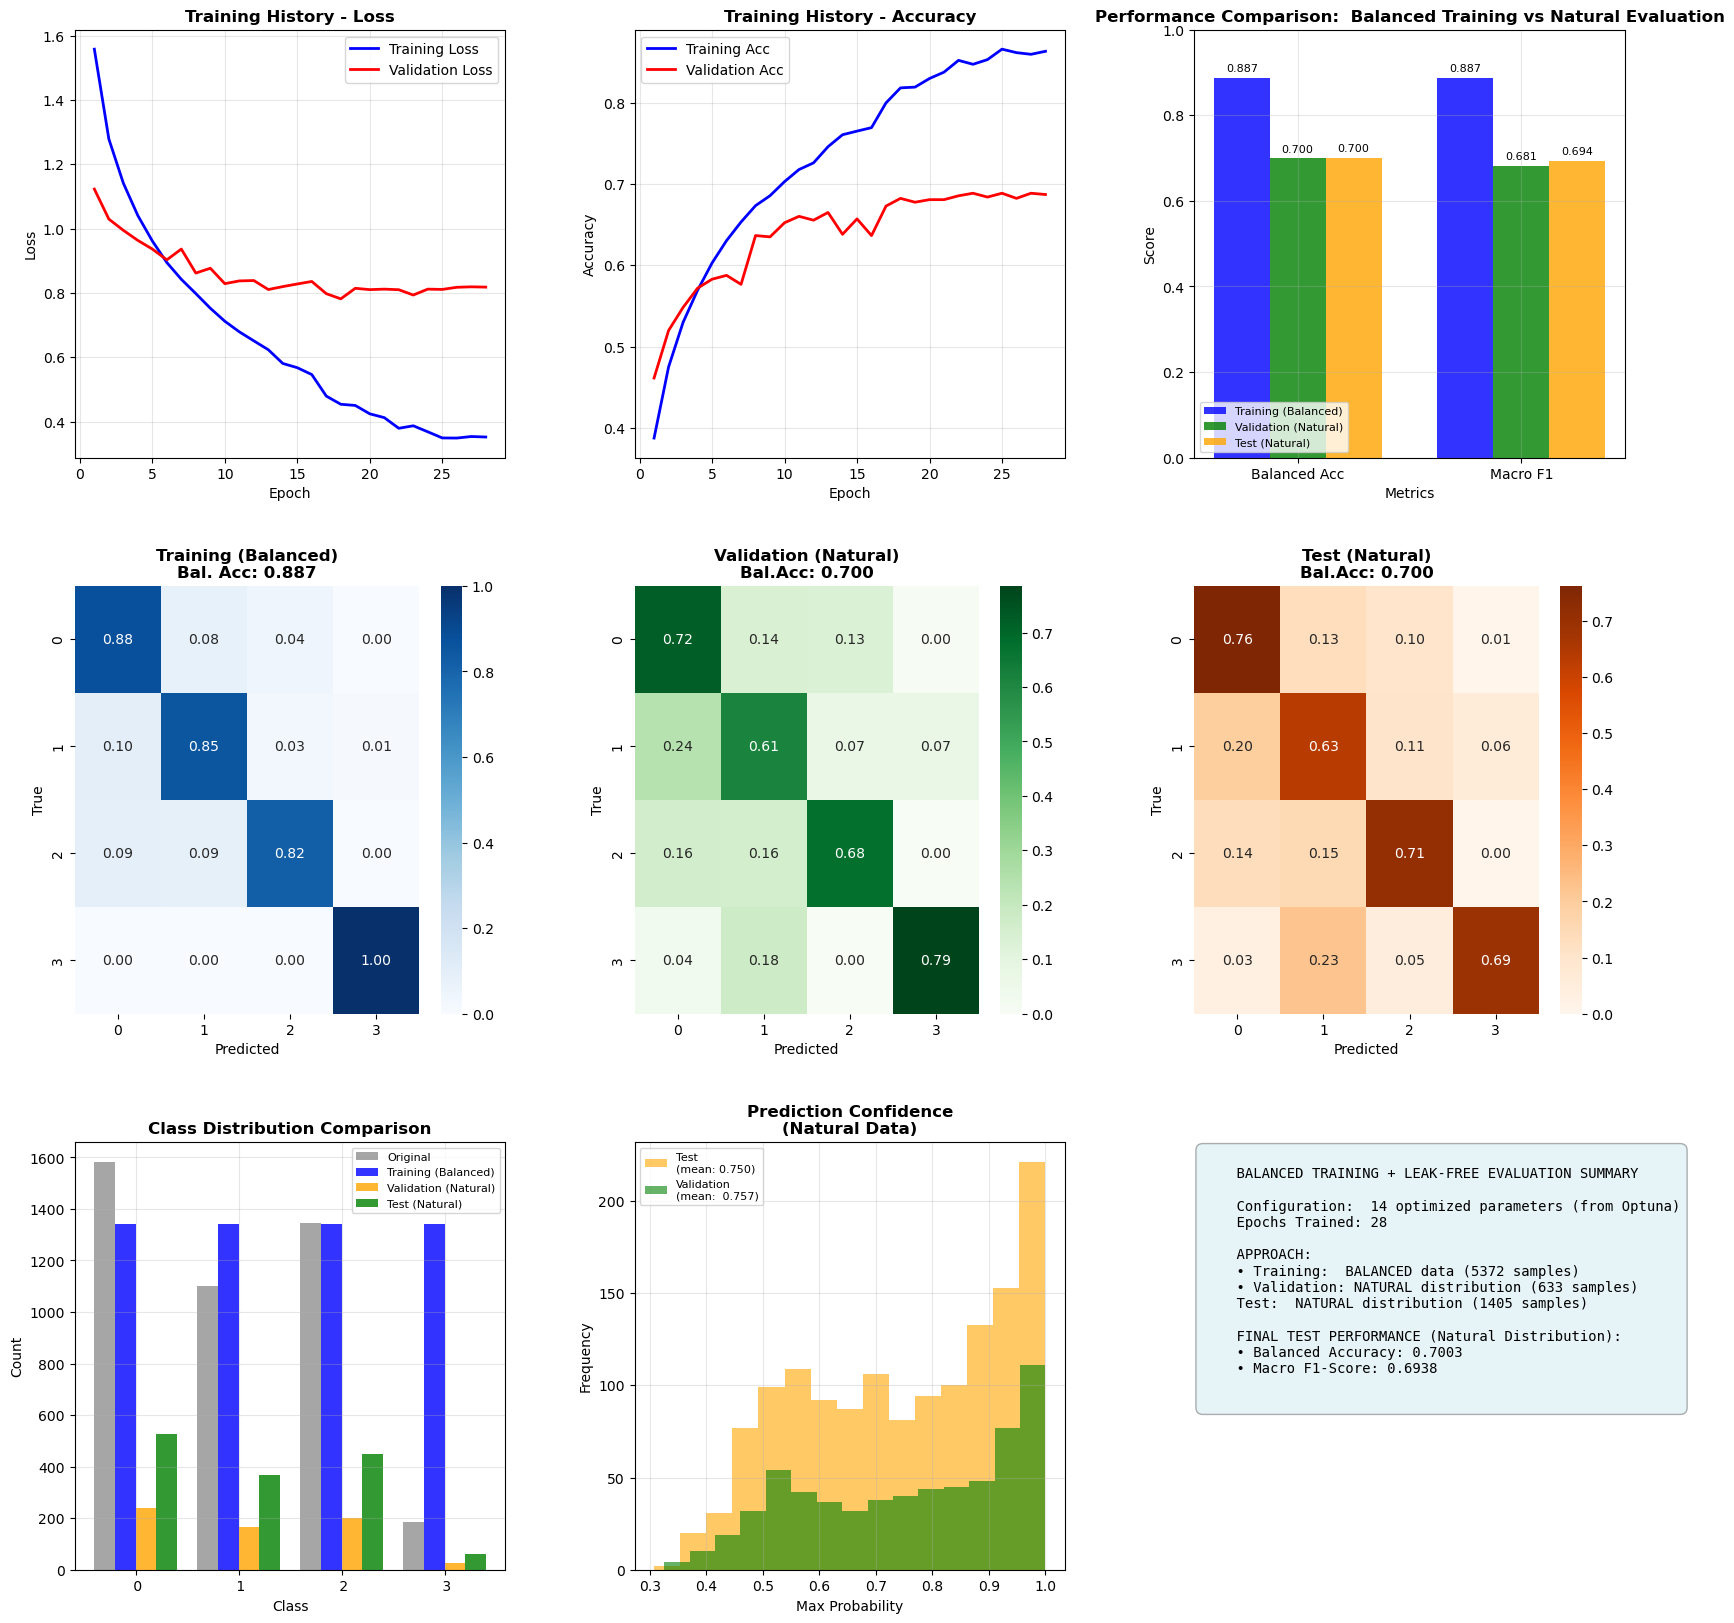


✅ BALANCED TRAINING + LEAK-FREE EVALUATION COMPLETED!


In [91]:
# Run complete training with comprehensive plots
results = classifier.train_and_evaluate_balanced_leak_free_complete(
    config_path='../Data/optimal_config.pkl',
    validation_size=0.15,
    max_epochs=100,
    plot_results=True
)

🎨 Creating comprehensive result plots...


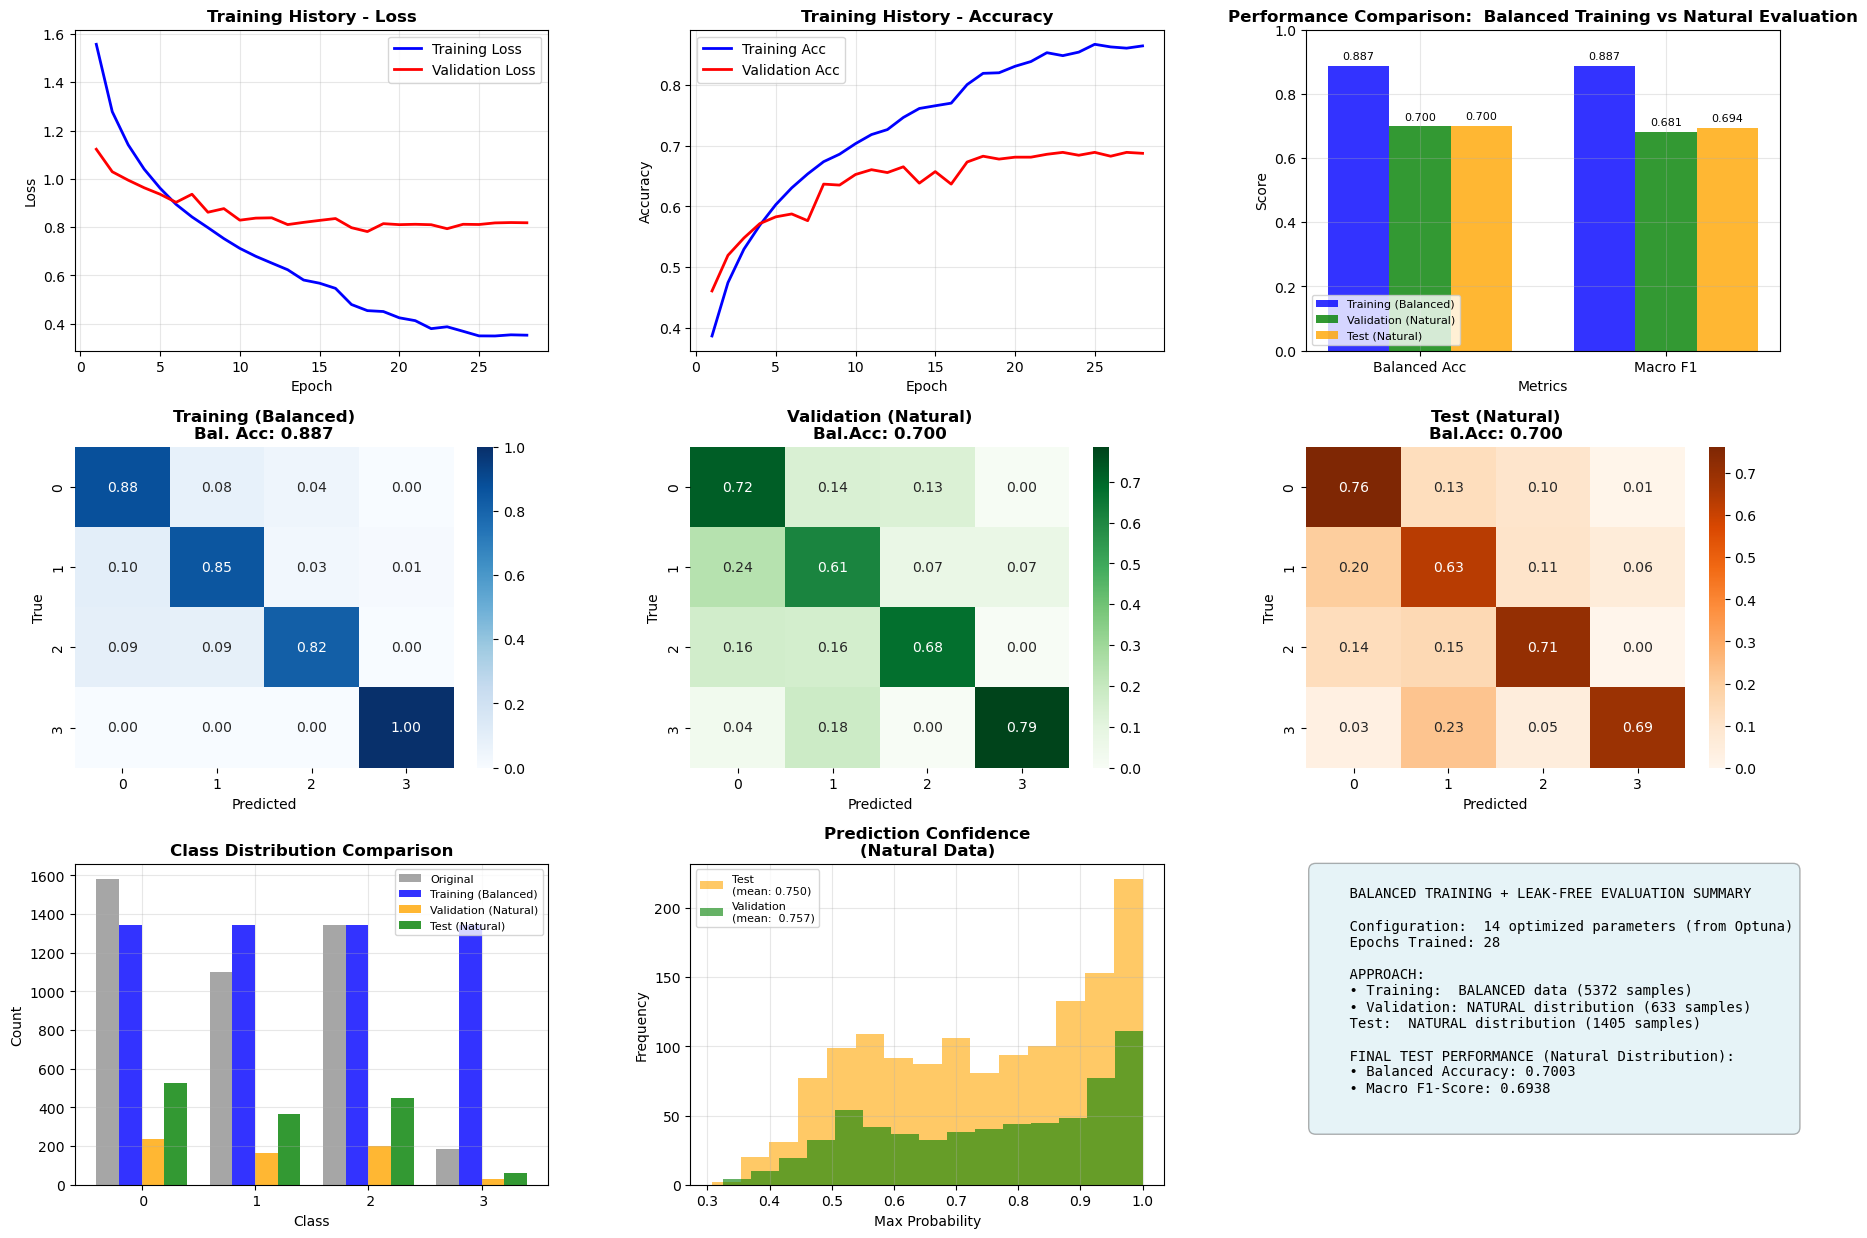

In [92]:
classifier.plot_comprehensive_balanced_results(results, figsize=(22, 15))

In [93]:
######################## Clean Model Save/Load - Adapted for Comprehensive Results ###############################

import os
import pickle
import tensorflow as tf
import numpy as np

def save_clean_model_from_comprehensive_results(self, save_directory='../Data/', model_name='clean_balanced_model'):
    """
    Save model without BlockGaussianNoise layer from comprehensive training results
    """
    
    # Check for comprehensive results instead of test_results_optimized
    if not hasattr(self, 'comprehensive_results') or 'model' not in self.comprehensive_results:
        print("❌ No trained model found in comprehensive_results.")
        print("Please run:  classifier.train_and_evaluate_balanced_leak_free_complete() first.")
        return False
    
    original_model = self.comprehensive_results['model']
    results = self.comprehensive_results
    
    print(f"💾 Saving clean model (without custom layers) to {save_directory}...")
    print(f"📊 Source:  Comprehensive balanced training results")
    
    # Create save directory if it doesn't exist
    os.makedirs(save_directory, exist_ok=True)
    
    try:
        # Step 1: Create clean model without BlockGaussianNoise
        print("🛠️ Creating clean model...")
        
        # Get input shape (remove batch dimension)
        input_shape = original_model.input_shape[1:]
        print(f"  Input shape: {input_shape}")
        
        # Create new input layer
        clean_input = tf.keras.layers.Input(shape=input_shape, name='clean_input')
        x = clean_input
        
        # Copy all layers except BlockGaussianNoise
        layers_copied = 0
        layers_skipped = 0
        
        for i, layer in enumerate(original_model.layers):
            layer_name = layer.__class__.__name__
            
            # Skip BlockGaussianNoise layer
            if layer_name == 'BlockGaussianNoise':  
                print(f"  Skipping layer {i}: {layer_name}")
                layers_skipped += 1
                continue
            
            # Skip Input layer (we created our own)
            if layer_name == 'InputLayer':
                print(f"  Skipping layer {i}:  {layer_name} (using custom input)")
                layers_skipped += 1
                continue
            
            try:
                # Apply layer to current tensor
                x = layer(x)
                layers_copied += 1
                print(f"  Copied layer {i}: {layer_name}")
            except Exception as e:
                print(f"  ⚠️ Could not copy layer {i} ({layer_name}): {e}")
                layers_skipped += 1
                continue
        
        print(f"  ✅ Successfully copied {layers_copied} layers")
        print(f"  ⏭️ Skipped {layers_skipped} layers (custom layers + input)")
        
        # Step 2: Create clean model
        clean_model = tf.keras.Model(inputs=clean_input, outputs=x, name='clean_balanced_model')
        
        # Compile clean model with same optimizer as original training
        config_used = results. get('config_used', {})
        learning_rate = config_used.get('learning_rate', 0.001)
        
        clean_model.compile(
            optimizer=tf.keras. optimizers.Adam(learning_rate=learning_rate),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
        
        print(f"  📊 Clean model shape: {clean_model.input_shape} -> {clean_model.output_shape}")
        
        # Step 3: Test clean model predictions
        print("🧪 Testing clean model...")
        dummy_input = tf.random.normal((1,) + input_shape)
        
        original_pred = original_model.predict(dummy_input, verbose=0)
        clean_pred = clean_model.predict(dummy_input, verbose=0)
        
        # Compare predictions (should be very similar since BlockGaussianNoise is off during inference)
        pred_diff = tf.reduce_max(tf.abs(original_pred - clean_pred)).numpy()
        print(f"  📊 Max prediction difference: {pred_diff:.8f}")
        
        if pred_diff < 0.001:
            print("  ✅ Clean model predictions match original")
        else:
            print("  ⚠️ Some difference in predictions (may be OK)")
        
        # Step 4: Save clean model
        clean_model_path = os.path.join(save_directory, f'{model_name}.h5')
        clean_model.save(clean_model_path)
        print(f"✅ Clean model saved:  {clean_model_path}")
        
        # Step 5: Create comprehensive metadata from comprehensive results
        metadata = {
            'model_name': model_name,
            'clean_model_path': clean_model_path,
            'training_approach': 'balanced_leak_free',
            'timestamp': tf.timestamp().numpy(),
            
            # Configuration used
            'config_used':  config_used,
            'epochs_trained': results.get('epochs_trained', 0),
            'validation_size': results.get('validation_size', 0.15),
            
            # Model architecture info
            'input_shape': input_shape,
            'output_shape': clean_model.output_shape[1:],
            'n_classes': getattr(self, 'n_classes', 4),
            'label_encoder_classes': getattr(self. label_encoder, 'classes_', []).tolist() if hasattr(self, 'label_encoder') else [],
            
            # Performance on all sets
            'performance':  {
                'training':  {
                    'accuracy': results. get('train_accuracy', 0),
                    'balanced_accuracy': results.get('train_balanced_accuracy', 0),
                    'macro_f1': results.get('train_macro_f1', 0),
                    'loss': results.get('train_loss', 0),
                    'data_type': 'balanced'
                },
                'validation': {
                    'accuracy': results.get('val_accuracy', 0),
                    'balanced_accuracy': results.get('val_balanced_accuracy', 0),
                    'macro_f1': results.get('val_macro_f1', 0),
                    'loss': results.get('val_loss', 0),
                    'data_type': 'natural'
                },
                'test': {
                    'accuracy': results.get('test_accuracy', 0),
                    'balanced_accuracy': results.get('test_balanced_accuracy', 0),
                    'macro_f1': results.get('test_macro_f1', 0),
                    'micro_f1': results.get('test_micro_f1', 0),
                    'loss':  results.get('test_loss', 0),
                    'data_type': 'natural'
                }
            },
            
            # Data characteristics
            'data_info': {
                'train_samples': len(results. get('train_true', [])),
                'val_samples': len(results.get('val_true', [])),
                'test_samples': len(results.get('test_true', [])),
                'train_counts': results.get('train_counts', {}),
                'val_counts': results.get('val_counts', {}),
                'test_counts': results.get('test_counts', {}),
                'balanced_training':  results.get('balanced_training', True),
                'leak_free':  results.get('leak_free', True)
            }
        }
        
        metadata_path = os.path.join(save_directory, f'{model_name}_metadata.pkl')
        with open(metadata_path, 'wb') as f:
            pickle.dump(metadata, f)
        print(f"✅ Comprehensive metadata saved: {metadata_path}")
        
        # Step 6: Save model summary
        summary_path = os.path.join(save_directory, f'{model_name}_summary.txt')
        with open(summary_path, 'w') as f:
            f.write("CLEAN MODEL SUMMARY\n")
            f.write("="*50 + "\n")
            f.write(f"Model Name: {model_name}\n")
            f.write(f"Training Approach:  Balanced + Leak-Free\n")
            f.write(f"Epochs Trained: {results.get('epochs_trained', 0)}\n")
            f.write(f"Validation Size: {results.get('validation_size', 0.15)*100:.1f}%\n\n")
            
            f.write("FINAL PERFORMANCE:\n")
            f.write(f"  Test Accuracy: {results.get('test_accuracy', 0):.4f}\n")
            f.write(f"  Test Balanced Accuracy: {results.get('test_balanced_accuracy', 0):.4f}\n")
            f.write(f"  Test Macro F1: {results.get('test_macro_f1', 0):.4f}\n")
            f.write(f"  Test Micro F1: {results.get('test_micro_f1', 0):.4f}\n\n")
            
            f.write("DATA CHARACTERISTICS:\n")
            f.write(f"  Training: {len(results.get('train_true', []))} samples (BALANCED)\n")
            f.write(f"  Validation:  {len(results.get('val_true', []))} samples (NATURAL)\n")
            f.write(f"  Test: {len(results.get('test_true', []))} samples (NATURAL)\n")
            f.write(f"  No data leakage:  {results.get('leak_free', True)}\n\n")
            
            f.write("MODEL INFO:\n")
            f.write(f"  Input Shape: {input_shape}\n")
            f.write(f"  Output Shape: {clean_model.output_shape}\n")
            f.write(f"  Number of Classes: {getattr(self, 'n_classes', 4)}\n")
            f.write(f"  Layers Copied: {layers_copied}\n")
            f.write(f"  Custom Layers Removed: {layers_skipped}\n")
        
        print(f"✅ Model summary saved: {summary_path}")
        
        print(f"\n📁 CLEAN MODEL PACKAGE SAVED:")
        print(f"  🎯 Model file: {clean_model_path}")
        print(f"  📋 Metadata: {metadata_path}")
        print(f"  📝 Summary: {summary_path}")
        print(f"  🧠 Ready for SHAP analysis!")
        
        return {
            'model_path': clean_model_path,
            'metadata_path': metadata_path,
            'summary_path': summary_path,
            'model':  clean_model,
            'metadata': metadata
        }
        
    except Exception as e:  
        print(f"❌ Failed to create clean model: {e}")
        import traceback
        traceback.print_exc()
        return False

def load_clean_balanced_model(self, save_directory='../Data/', model_name='clean_balanced_model'):
    """
    Load clean model saved from comprehensive training results
    """
    
    print(f"📂 Loading clean model from comprehensive training...")
    
    # Step 1: Load metadata
    metadata_path = os.path.join(save_directory, f'{model_name}_metadata.pkl')
    try:
        with open(metadata_path, 'rb') as f:
            metadata = pickle.load(f)
        print("✅ Comprehensive metadata loaded")
        
        # Print key performance info
        test_perf = metadata['performance']['test']
        print(f"  📊 Original test performance:")
        print(f"    Balanced Accuracy: {test_perf['balanced_accuracy']:.4f}")
        print(f"    Macro F1: {test_perf['macro_f1']:.4f}")
        print(f"    Training:  {metadata['data_info']['train_samples']} balanced samples")
        print(f"    Test: {metadata['data_info']['test_samples']} natural samples")
        
    except Exception as e:
        print(f"⚠️ Could not load metadata: {e}")
        metadata = None
    
    # Step 2: Load clean model
    clean_model_path = os. path.join(save_directory, f'{model_name}.h5')
    
    try:
        model = tf.keras.models.load_model(clean_model_path)
        print(f"✅ Clean model loaded from:  {clean_model_path}")
        print(f"  📊 Model shape: {model.input_shape} -> {model.output_shape}")
        
        # Step 3: Store for analysis (compatible with both old and new systems)
        # Store in both locations for compatibility
        if not hasattr(self, 'test_results_optimized'):
            self.test_results_optimized = {}
        if not hasattr(self, 'comprehensive_results'):
            self.comprehensive_results = {}
            
        self.test_results_optimized['model'] = model
        self.comprehensive_results['model'] = model
        
        # Store metadata if available
        if metadata:
            self.loaded_model_metadata = metadata
            
            # Restore label encoder if needed
            if metadata['label_encoder_classes'] and not hasattr(self, 'label_encoder'):
                from sklearn.preprocessing import LabelEncoder
                self.label_encoder = LabelEncoder()
                self.label_encoder.classes_ = np.array(metadata['label_encoder_classes'])
            
            # Restore n_classes
            if not hasattr(self, 'n_classes'):
                self.n_classes = metadata['n_classes']
        
        # Step 4: Test model
        print("🧪 Testing loaded model...")
        input_shape = model.input_shape[1:]
        dummy_input = tf.random.normal((1,) + input_shape)
        test_output = model.predict(dummy_input, verbose=0)
        
        print(f"  ✅ Model test successful")
        print(f"  📊 Output shape: {test_output.shape}")
        print(f"  📊 Output sum: {test_output.sum():.6f} (should be ~1.0 for probabilities)")
        
        print(f"\n🎯 Clean model ready for analysis!")
        print(f"  • SHAP analysis:  aggregated_shap, plots = classifier.quick_shap_analysis_100_samples()")
        print(f"  • Model source:  Balanced training + Leak-free evaluation")
        
        return True
        
    except FileNotFoundError:
        print(f"❌ Clean model file not found: {clean_model_path}")
        print(f"Make sure you saved the model first using save_clean_model_from_comprehensive_results()")
        return False
    except Exception as e: 
        print(f"❌ Failed to load clean model: {e}")
        import traceback
        traceback.print_exc()
        return False

def print_saved_model_info(self, save_directory='../Data/', model_name='clean_balanced_model'):
    """
    Print information about saved clean model without loading it
    """
    
    metadata_path = os.path.join(save_directory, f'{model_name}_metadata.pkl')
    summary_path = os.path. join(save_directory, f'{model_name}_summary.txt')
    
    print(f"📋 SAVED MODEL INFORMATION:  {model_name}")
    print("="*60)
    
    # Load and print metadata
    try:
        with open(metadata_path, 'rb') as f:
            metadata = pickle.load(f)
        
        print(f"✅ Model saved successfully")
        print(f"📊 Training approach: {metadata. get('training_approach', 'Unknown')}")
        print(f"🕐 Epochs trained: {metadata.get('epochs_trained', 0)}")
        
        # Performance summary
        print(f"\n📈 PERFORMANCE SUMMARY:")
        for set_name, perf in metadata['performance'].items():
            print(f"  {set_name. capitalize()} ({perf['data_type']}):")
            print(f"    Balanced Accuracy: {perf['balanced_accuracy']:.4f}")
            print(f"    Macro F1: {perf['macro_f1']:.4f}")
        
        # Data info
        data_info = metadata['data_info']
        print(f"\n📊 DATA CHARACTERISTICS:")
        print(f"  Training:  {data_info['train_samples']} samples (balanced)")
        print(f"  Validation: {data_info['val_samples']} samples (natural)")
        print(f"  Test: {data_info['test_samples']} samples (natural)")
        print(f"  Leak-free: {data_info['leak_free']}")
        
        print(f"\n📁 FILES:")
        print(f"  Model:  {metadata['clean_model_path']}")
        print(f"  Metadata:  {metadata_path}")
        
    except FileNotFoundError:
        print(f"❌ No saved model found: {metadata_path}")
    except Exception as e: 
        print(f"❌ Error reading metadata: {e}")
    
    # Print summary file if it exists
    try:
        with open(summary_path, 'r') as f:
            print(f"\n📝 SUMMARY FILE CONTENT:")
            print("-" * 30)
            print(f.read())
    except FileNotFoundError:
        pass

# Add functions to class
HeatmapCNNClassifier.save_clean_model_from_comprehensive_results = save_clean_model_from_comprehensive_results
HeatmapCNNClassifier.load_clean_balanced_model = load_clean_balanced_model
HeatmapCNNClassifier.print_saved_model_info = print_saved_model_info

print("✅ Adapted clean model save/load functions loaded!")
print("\nAdapted for comprehensive training results:")
print("\n1. Save clean model:")
print("   save_result = classifier.save_clean_model_from_comprehensive_results()")
print("\n2. Load clean model:")
print("   success = classifier.load_clean_balanced_model()")
print("\n3. Check saved model info:")
print("   classifier.print_saved_model_info()")

✅ Adapted clean model save/load functions loaded!

Adapted for comprehensive training results:

1. Save clean model:
   save_result = classifier.save_clean_model_from_comprehensive_results()

2. Load clean model:
   success = classifier.load_clean_balanced_model()

3. Check saved model info:
   classifier.print_saved_model_info()


In [94]:
# 1. Save your trained clean model (after comprehensive training)
save_result = classifier.save_clean_model_from_comprehensive_results(
    save_directory='../Data/',
    model_name='clean_balanced_model_4_clusters'
)

💾 Saving clean model (without custom layers) to ../Data/...
📊 Source:  Comprehensive balanced training results
🛠️ Creating clean model...
  Input shape: (46, 46, 3)
  Skipping layer 0: BlockGaussianNoise
  Copied layer 1: Conv2D
  Copied layer 2: BatchNormalization
  Copied layer 3: Conv2D
  Copied layer 4: MaxPooling2D
  Copied layer 5: Dropout
  Copied layer 6: Conv2D
  Copied layer 7: BatchNormalization
  Copied layer 8: Conv2D
  Copied layer 9: MaxPooling2D
  Copied layer 10: Dropout
  Copied layer 11: Conv2D
  Copied layer 12: BatchNormalization
  Copied layer 13: Conv2D
  Copied layer 14: MaxPooling2D
  Copied layer 15: Dropout
  Copied layer 16: Flatten
  Copied layer 17: Dense
  Copied layer 18: BatchNormalization
  Copied layer 19: Dropout
  Copied layer 20: Dense
  Copied layer 21: Dropout
  Copied layer 22: Dense
  ✅ Successfully copied 22 layers
  ⏭️ Skipped 1 layers (custom layers + input)
  📊 Clean model shape: (None, 46, 46, 3) -> (None, 4)
🧪 Testing clean model...
  📊 M

# SHAP analysis

### SHAP analysis of final CNN model

In [95]:
######################## Optimized SHAP Analysis - Updated for Clean Balanced Model ###############################

import time
import os
import pickle
import numpy as np
import shap
import tensorflow as tf
from collections import Counter
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

def calculate_all_samples_shap_with_clean_balanced_model(self, 
                                                        model_directory='../Data/', 
                                                        model_name='clean_balanced_model_4_clusters',
                                                        background_samples=200,
                                                        batch_size=100,
                                                        save_interval=5,
                                                        max_samples_per_cluster=1000,
                                                        random_state=42):
    """
    Optimized SHAP calculation using clean balanced model
    """
    
    print("🚀 Starting OPTIMIZED SHAP Analysis with Clean Balanced Model")
    print("="*70)
    print(f"⚡ Optimizations:")
    print(f"  • Model source: Clean balanced model (no custom layers)")
    print(f"  • Background samples: {background_samples}")
    print(f"  • Batch size: {batch_size}")  
    print(f"  • Max samples per cluster: {max_samples_per_cluster}")
    print(f"  • Save interval:  {save_interval}")
    
    # Step 1: Create save directory
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    save_dir = f"../Data/shap_results_balanced_model_{timestamp}"
    os.makedirs(save_dir, exist_ok=True)
    
    print(f"📁 Save directory: {save_dir}")
    
    # Step 2: Load clean balanced model
    print(f"\n🔄 Loading clean balanced model...")
    print(f"  Model path: {model_directory}")
    print(f"  Model name:  {model_name}")
    
    load_success = self.load_clean_balanced_model(model_directory, model_name)
    
    if not load_success:
        print("❌ Failed to load clean balanced model")
        return None, None
    
    # Get model from the loaded results
    if hasattr(self, 'comprehensive_results') and 'model' in self.comprehensive_results:
        model = self.comprehensive_results['model']
        print("✅ Model loaded from comprehensive_results")
    elif hasattr(self, 'test_results_optimized') and 'model' in self.test_results_optimized:
        model = self.test_results_optimized['model']
        print("✅ Model loaded from test_results_optimized")
    else:
        print("❌ No model found after loading")
        return None, None
    
    # Get model info from metadata if available
    model_info = {}
    if hasattr(self, 'loaded_model_metadata'):
        metadata = self.loaded_model_metadata
        model_info = {
            'training_approach': metadata.get('training_approach', 'balanced_leak_free'),
            'epochs_trained': metadata.get('epochs_trained', 0),
            'test_performance': metadata.get('performance', {}).get('test', {}),
            'balanced_training':  metadata.get('data_info', {}).get('balanced_training', True)
        }
        
        print(f"📊 Model info from metadata:")
        print(f"  Training approach: {model_info['training_approach']}")
        print(f"  Epochs trained: {model_info['epochs_trained']}")
        if 'balanced_accuracy' in model_info['test_performance']:
            print(f"  Test balanced accuracy: {model_info['test_performance']['balanced_accuracy']:.4f}")
    
    print(f"📊 Model loaded:  {model. input_shape} -> {model.output_shape}")
    
    # Step 3: Verify data availability and prepare
    print(f"\n📊 Preparing data...")
    
    required_data = ['X_train_scaled', 'X_test_scaled', 'y_train_encoded', 'y_test_encoded']
    missing_data = [attr for attr in required_data if not hasattr(self, attr)]
    
    if missing_data:
        raise ValueError(f"Missing required data:  {missing_data}")
    
    X_all = np.concatenate([self.X_train_scaled, self.X_test_scaled], axis=0)
    y_all = np.concatenate([self.y_train_encoded, self.y_test_encoded], axis=0)
    
    print(f"📈 Total available data: {X_all.shape}")
    print(f"📊 Class distribution:  {Counter(y_all)}")
    
    # Step 4: Setup explainer with background samples
    print(f"\n🧠 Setting up SHAP explainer with {background_samples} background samples...")
    np.random.seed(random_state)
    
    background_indices = np.random.choice(len(X_all), size=background_samples, replace=False)
    background_data = X_all[background_indices]
    
    print(f"📊 Background data shape: {background_data.shape}")
    
    explainer = shap.DeepExplainer(model, background_data)
    print("✅ SHAP explainer created successfully")
    
    # Step 5: Process clusters with sampling
    all_results = {}
    overall_start_time = time.time()
    
    for cluster_id in range(self.n_classes):  # Use actual number of classes
        print(f"\n🔍 Processing Cluster {cluster_id}...")
        
        cluster_mask = y_all == cluster_id
        cluster_indices = np.where(cluster_mask)[0]
        
        if len(cluster_indices) == 0:
            print(f"  ⚠️ No samples found for Cluster {cluster_id}")
            continue
            
        # Sample if too many samples
        if len(cluster_indices) > max_samples_per_cluster:
            sampled_indices = np.random. choice(
                cluster_indices, 
                size=max_samples_per_cluster, 
                replace=False
            )
            cluster_samples = X_all[sampled_indices]
            print(f"  📊 Using {max_samples_per_cluster}/{len(cluster_indices)} samples (sampled)")
        else:
            cluster_samples = X_all[cluster_indices]
            print(f"  📊 Using all {len(cluster_samples)} samples")
        
        n_samples = len(cluster_samples)
        total_batches = (n_samples - 1) // batch_size + 1
        
        print(f"  🔄 Processing {total_batches} batches (size {batch_size})...")
        
        cluster_start_time = time.time()
        cluster_shap_values = []
        successful_batches = 0
        
        for batch_idx in range(0, n_samples, batch_size):
            batch_end = min(batch_idx + batch_size, n_samples)
            batch_samples = cluster_samples[batch_idx:batch_end]
            batch_number = batch_idx // batch_size + 1
            
            try:
                # Calculate SHAP values
                batch_shap = explainer.shap_values(batch_samples)
                
                # Handle different SHAP output formats
                if isinstance(batch_shap, list):
                    # Multi-class output:  use SHAP values for current cluster
                    batch_shap_cluster = batch_shap[cluster_id]
                else:
                    batch_shap_cluster = batch_shap
                
                # Handle shape issues (sometimes 5D output)
                if len(batch_shap_cluster. shape) == 5 and batch_shap_cluster. shape[-1] == self.n_classes:
                    batch_shap_cluster = batch_shap_cluster[: , :, :, : , cluster_id]
                
                cluster_shap_values.append(batch_shap_cluster)
                successful_batches += 1
                
                # Progress update
                if batch_number % save_interval == 0 or batch_number == total_batches:
                    elapsed = time.time() - cluster_start_time
                    progress = (batch_number / total_batches) * 100
                    rate = batch_number / elapsed * 60 if elapsed > 0 else 0
                    eta_minutes = (total_batches - batch_number) / (batch_number / elapsed) / 60 if batch_number > 0 and elapsed > 0 else 0
                    
                    print(f"    📈 Batch {batch_number}/{total_batches} ({progress:.1f}%) | "
                          f"Rate: {rate:.1f} batches/min | ETA: {eta_minutes:.1f}min")
                    
                    # Save checkpoint
                    if batch_number % (save_interval * 2) == 0 or batch_number == total_batches:
                        current_shap = np.concatenate(cluster_shap_values, axis=0)
                        checkpoint_data = {
                            'cluster_id': cluster_id,
                            'batch_num': batch_number,
                            'partial_shap': current_shap,
                            'progress': progress,
                            'timestamp': datetime.now().isoformat(),
                            'model_info': model_info
                        }
                        
                        checkpoint_file = os.path.join(save_dir, f'checkpoint_c{cluster_id}_b{batch_number: 03d}.pkl')
                        with open(checkpoint_file, 'wb') as f:
                            pickle.dump(checkpoint_data, f, protocol=pickle.HIGHEST_PROTOCOL)
                        
                        file_size_mb = os.path.getsize(checkpoint_file) / 1024 / 1024
                        print(f"    💾 Checkpoint saved: {file_size_mb:.1f} MB")
                
            except Exception as e:
                print(f"    ❌ Batch {batch_number} failed: {e}")
                continue
        
        # Store results for this cluster
        if cluster_shap_values:
            final_shap = np.concatenate(cluster_shap_values, axis=0)
            all_results[cluster_id] = {
                'shap_values': final_shap,
                'n_samples':  n_samples,
                'successful_batches': successful_batches,
                'total_batches': total_batches,
                'processing_time': time.time() - cluster_start_time
            }
            
            cluster_time = time.time() - cluster_start_time
            print(f"  ✅ Cluster {cluster_id} complete:")
            print(f"    Time: {cluster_time/60:.1f}min")
            print(f"    Success rate: {successful_batches}/{total_batches} batches")
            print(f"    Final SHAP shape: {final_shap.shape}")
        else:
            print(f"  ❌ No valid SHAP values for Cluster {cluster_id}")
    
    # Step 6: Aggregate and save results
    print(f"\n📈 Aggregating SHAP values...")
    aggregated_shap = {}
    
    for cluster_id, data in all_results.items():
        aggregated = np.mean(data['shap_values'], axis=0)
        aggregated_shap[cluster_id] = aggregated
        print(f"  Cluster {cluster_id}: {aggregated.shape} | Mean |SHAP|: {np.abs(aggregated).mean():.6f}")
    
    # Create comprehensive metadata
    total_time = time.time() - overall_start_time
    
    final_results = {
        'aggregated_shap_values': aggregated_shap,
        'all_results': all_results,
        'metadata': {
            'timestamp': timestamp,
            'model_used':  f"{model_directory}/{model_name}",
            'model_info': model_info,
            'background_samples': background_samples,
            'batch_size': batch_size,
            'max_samples_per_cluster': max_samples_per_cluster,
            'total_samples_processed': sum(data['n_samples'] for data in all_results.values()),
            'total_processing_time': total_time,
            'clusters_processed': len(all_results),
            'n_classes': self.n_classes,
            'save_interval': save_interval,
            'random_state': random_state
        }
    }
    
    # Save aggregated results (for quick plotting)
    aggregated_file = os.path. join(save_dir, f'aggregated_shap_balanced_{timestamp}.pkl')
    with open(aggregated_file, 'wb') as f:
        pickle.dump(aggregated_shap, f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"💾 Aggregated results saved:  {aggregated_file}")
    
    # Save complete results
    complete_file = os.path.join(save_dir, f'complete_shap_balanced_{timestamp}.pkl')
    with open(complete_file, 'wb') as f:
        pickle.dump(final_results, f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"💾 Complete results saved:  {complete_file}")
    
    # Save human-readable summary
    summary_file = os.path.join(save_dir, f'shap_summary_{timestamp}.txt')
    with open(summary_file, 'w') as f:
        f.write("SHAP ANALYSIS SUMMARY - CLEAN BALANCED MODEL\n")
        f.write("=" * 60 + "\n")
        f.write(f"Analysis Timestamp: {timestamp}\n")
        f.write(f"Completion Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write(f"Total Processing Time: {total_time/60:.1f} minutes\n\n")
        
        f. write("MODEL INFORMATION:\n")
        f.write(f"  Model Used: {model_directory}/{model_name}\n")
        f.write(f"  Training Approach: {model_info. get('training_approach', 'Unknown')}\n")
        f.write(f"  Epochs Trained: {model_info.get('epochs_trained', 0)}\n")
        if 'balanced_accuracy' in model_info.get('test_performance', {}):
            f.write(f"  Test Balanced Accuracy: {model_info['test_performance']['balanced_accuracy']:.4f}\n")
        f.write(f"  Balanced Training: {model_info. get('balanced_training', True)}\n\n")
        
        f. write("ANALYSIS PARAMETERS:\n")
        f.write(f"  Background Samples: {background_samples}\n")
        f.write(f"  Batch Size: {batch_size}\n")
        f.write(f"  Max Samples per Cluster: {max_samples_per_cluster}\n")
        f.write(f"  Total Samples: {final_results['metadata']['total_samples_processed']}\n\n")
        
        f. write("CLUSTER RESULTS:\n")
        for cluster_id, cluster_data in all_results.items():
            f.write(f"  Cluster {cluster_id}:\n")
            f.write(f"    Samples Processed: {cluster_data['n_samples']}\n")
            f.write(f"    SHAP Shape: {cluster_data['shap_values'].shape}\n")
            f.write(f"    Success Rate: {cluster_data['successful_batches']}/{cluster_data['total_batches']}\n")
            f.write(f"    Processing Time: {cluster_data['processing_time']/60:.1f} min\n")
        
        f.write(f"\nFILES CREATED:\n")
        f.write(f"  Aggregated SHAP:  {aggregated_file}\n")
        f.write(f"  Complete Results: {complete_file}\n")
        f.write(f"  Analysis Summary: {summary_file}\n")
        f.write(f"  Checkpoints: checkpoint_c*_b*.pkl\n")
    
    print(f"📝 Summary saved: {summary_file}")
    
    # Store results in classifier for easy access
    self.balanced_shap_results = {
        'save_directory': save_dir,
        'timestamp': timestamp,
        'aggregated_shap_values': aggregated_shap,
        'metadata': final_results['metadata']
    }
    
    print(f"\n🎉 OPTIMIZED SHAP ANALYSIS COMPLETED!")
    print(f"⏱️ Total time: {total_time/60:.1f} minutes")
    print(f"📁 All results saved in: {save_dir}")
    print(f"📊 Clusters processed: {len(all_results)}")
    print(f"📈 Total samples analyzed: {sum(data['n_samples'] for data in all_results.values())}")
    print(f"🎯 Ready for visualization with balanced model SHAP results!")
    
    return aggregated_shap, save_dir

# Add function to class
HeatmapCNNClassifier. calculate_all_samples_shap_with_clean_balanced_model = calculate_all_samples_shap_with_clean_balanced_model

print("✅ SHAP analysis updated for clean balanced model!")
print("\nTo run SHAP analysis with your clean balanced model:")
print("aggregated_shap, save_dir = classifier.calculate_all_samples_shap_with_clean_balanced_model(")
print("    model_name='clean_balanced_model',")
print("    background_samples=200,")
print("    max_samples_per_cluster=1000")
print(")")

✅ SHAP analysis updated for clean balanced model!

To run SHAP analysis with your clean balanced model:
aggregated_shap, save_dir = classifier.calculate_all_samples_shap_with_clean_balanced_model(
    model_name='clean_balanced_model',
    background_samples=200,
    max_samples_per_cluster=1000
)


In [96]:
classifier = HeatmapCNNClassifier()
classifier.load_data_assignments()
classifier.load_heatmaps()
classifier.split_train_test()
classifier.scale_data()

Loading data assignments...
Train/test DataFrame shape: (5619, 3)
Clusters DataFrame shape: (5619, 4)
Train/test columns: ['Profile_id', 'data_type', 'CV_fold']
Clusters columns:  ['Profile_id', 'cluster', 'cluster_4', 'cluster_6']
Loaded assignments for 5619 profiles
Loaded cluster assignments for 5619 profiles
Sample train/test data for profile s033:  {'data_type': 'test', 'CV_fold': ''}
Sample cluster data for profile s033:  {'cluster': 1, 'cluster_4': 1, 'cluster_6': 2}
Loading heatmap images...
Found 5619 PNG files in ..\Data\heatmaps
Sample filenames: ['0000a_WMO5906623_recovery_profiles.png', '0002a_WMO5906623_recovery_profiles.png', '0003a_WMO5906623_recovery_profiles.png', '0003a_WMO6904139_recovery.png', '0004a_WMO6903096.png']
Sample extracted profile IDs: ['0000a_WMO5906623_recovery_profiles', '0002a_WMO5906623_recovery_profiles', '0003a_WMO5906623_recovery_profiles', '0003a_WMO6904139_recovery', '0004a_WMO6903096']
Available profile IDs from filenames: 5619
Profile IDs wit

In [97]:
# Run SHAP analysis with your clean balanced model
aggregated_shap, save_dir = classifier.calculate_all_samples_shap_with_clean_balanced_model(
    model_directory='../Data/',
    model_name='clean_balanced_model_4_clusters',  # Your saved clean model
    background_samples=100, # increase to get better results, but it will take very long
    batch_size=50,
    max_samples_per_cluster=100 # increase to get more representative results
)

🚀 Starting OPTIMIZED SHAP Analysis with Clean Balanced Model
⚡ Optimizations:
  • Model source: Clean balanced model (no custom layers)
  • Background samples: 100
  • Batch size: 50
  • Max samples per cluster: 100
  • Save interval:  5
📁 Save directory: ../Data/shap_results_balanced_model_20260109_145001

🔄 Loading clean balanced model...
  Model path: ../Data/
  Model name:  clean_balanced_model_4_clusters
📂 Loading clean model from comprehensive training...
✅ Comprehensive metadata loaded
  📊 Original test performance:
    Balanced Accuracy: 0.7003
    Macro F1: 0.6938
    Training:  5372 balanced samples
    Test: 1405 natural samples
✅ Clean model loaded from:  ../Data/clean_balanced_model_4_clusters.h5
  📊 Model shape: (None, 46, 46, 3) -> (None, 4)
🧪 Testing loaded model...
  ✅ Model test successful
  📊 Output shape: (1, 4)
  📊 Output sum: 1.000000 (should be ~1.0 for probabilities)

🎯 Clean model ready for analysis!
  • SHAP analysis:  aggregated_shap, plots = classifier.quick

In [98]:
######################## Fixed 2-Row Layout Enhanced SHAP Visualization ###############################

import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle
from glob import glob

# ============================================================================
# FIXED LOAD FUNCTION FOR BALANCED MODEL SHAP RESULTS
# ============================================================================

def load_latest_balanced_shap_results_fixed(save_dir="../Data"):
    """Load the most recent SHAP results from balanced model analysis (fixed)"""
    
    # Find latest SHAP directory (including new balanced model results)
    shap_dirs = (glob(os.path.join(save_dir, "shap_results_balanced_model_*")) +
                 glob(os.path.join(save_dir, "shap_results_optimized_*")) + 
                 glob(os.path.join(save_dir, "shap_results_*")))
    
    if not shap_dirs:
        print("❌ No saved SHAP results found!")
        return None, None
    
    latest_dir = max(shap_dirs, key=os.path.getctime)
    print(f"📁 Loading from: {latest_dir}")
    
    # Look for balanced model files first, then optimized, then regular files
    agg_files = (glob(os.path.join(latest_dir, "aggregated_shap_balanced_*.pkl")) + 
                 glob(os.path.join(latest_dir, "aggregated_shap_optimized_*.pkl")) + 
                 glob(os.path.join(latest_dir, "aggregated_shap_values_*.pkl")))
    
    complete_files = (glob(os.path.join(latest_dir, "complete_shap_balanced_*.pkl")) +
                      glob(os.path.join(latest_dir, "complete_shap_optimized_*.pkl")) + 
                      glob(os.path.join(latest_dir, "complete_shap_results_*.pkl")))
    
    if not agg_files:     
        print("❌ No aggregated SHAP files found!")
        return None, None
    
    if not complete_files:  
        print("❌ No complete SHAP files found!")
        return None, None
    
    print(f"📊 Found files:")
    print(f"  Aggregated: {os.path.basename(agg_files[0])}")
    print(f"  Complete: {os.path.basename(complete_files[0])}")
    
    # Identify file type
    if "balanced" in agg_files[0]:
        file_type = "balanced_model"
        print("🎯 Detected:  Clean balanced model SHAP results")
    elif "optimized" in agg_files[0]:
        file_type = "optimized"
        print("⚡ Detected:  Optimized SHAP results")
    else:
        file_type = "regular"
        print("📊 Detected: Regular SHAP results")
    
    # Load aggregated results
    with open(agg_files[0], 'rb') as f:
        aggregated_shap_values = pickle.load(f)
    
    # Load complete results  
    with open(complete_files[0], 'rb') as f:
        complete_results = pickle.load(f)
    
    metadata = complete_results['metadata']
    
    # Add file type info to metadata
    metadata['file_type'] = file_type
    metadata['source_dir'] = latest_dir
    
    print(f"✅ Loaded SHAP results for {len(aggregated_shap_values)} clusters")
    print(f"📈 Total samples processed: {metadata.get('total_samples_processed', 'Unknown')}")
    
    # Print model info if available (for balanced model results)
    if 'model_info' in metadata:
        model_info = metadata['model_info']
        print(f"🏗️ Model info:")
        print(f"  Training approach: {model_info.get('training_approach', 'Unknown')}")
        print(f"  Epochs trained: {model_info.get('epochs_trained', 'Unknown')}")
        if 'test_performance' in model_info and 'balanced_accuracy' in model_info['test_performance']:
            print(f"  Test balanced accuracy: {model_info['test_performance']['balanced_accuracy']:.4f}")
    
    return aggregated_shap_values, metadata

# ============================================================================
# RESHAPE TO ORIGINAL DATA STRUCTURE  
# ============================================================================

def reshape_shap_to_original_data(shap_2d):
    """Reshape SHAP values from 46x46 image back to original 40×15 data structure"""
    # Remove padding and average size class pixels
    unpadded = shap_2d[3: 43, 1:46]  # Extract 40 rows × 45 cols
    h, w = unpadded.shape
    reshaped = unpadded.reshape(h, w//3, 3).mean(axis=2)  # 40 × 15
    return reshaped

# ============================================================================
# UTILITY FUNCTIONS
# ============================================================================

def get_cluster_sample_count(cluster_id, metadata):
    """Safely extract sample count for a cluster from metadata"""
    
    # Method 1: Check if all_results is in the main metadata (new balanced model structure)
    if 'all_results' in metadata:  
        all_results = metadata['all_results']
        if isinstance(all_results, dict) and cluster_id in all_results:  
            cluster_data = all_results[cluster_id]
            if isinstance(cluster_data, dict) and 'n_samples' in cluster_data:  
                return cluster_data['n_samples']
    
    # Method 2: Check if clusters_processed exists and is a dictionary
    if 'clusters_processed' in metadata:  
        clusters_processed = metadata['clusters_processed']
        if isinstance(clusters_processed, dict) and cluster_id in clusters_processed: 
            cluster_info = clusters_processed[cluster_id]
            if isinstance(cluster_info, dict) and 'n_samples' in cluster_info:   
                return cluster_info['n_samples']
    
    # Method 3: Fallback estimation based on total samples
    total_samples = metadata.get('total_samples_processed', 0)
    max_per_cluster = metadata.get('max_samples_per_cluster', 1000)
    
    if isinstance(total_samples, int) and total_samples > 0:
        # Simple estimation: divide by number of clusters
        n_clusters = len(metadata.get('aggregated_shap_values', {})) if 'aggregated_shap_values' in metadata else metadata.get('n_classes', 6)
        estimated = min(max_per_cluster, total_samples // n_clusters)
        return estimated
    
    return "Unknown"

def generate_cluster_names(n_clusters):
    """Generate appropriate cluster names for any number of clusters"""
    
    if n_clusters == 4:
        return [
            'Cluster 0 - Environmental Pattern A',
            'Cluster 1 - Environmental Pattern B', 
            'Cluster 2 - Environmental Pattern C',
            'Cluster 3 - Environmental Pattern D'
        ]
    elif n_clusters == 6:
        return [
            'Cluster 0 - Environmental Pattern A',
            'Cluster 1 - Environmental Pattern B',
            'Cluster 2 - Environmental Pattern C', 
            'Cluster 3 - Environmental Pattern D',
            'Cluster 4 - Environmental Pattern E',
            'Cluster 5 - Environmental Pattern F'
        ]
    else:
        # Generic names for any number of clusters
        return [f'Cluster {i} - Pattern {chr(65+i)}' for i in range(n_clusters)]

# ============================================================================
# FIXED 2-ROW VISUALIZATION FUNCTION
# ============================================================================

def create_enhanced_2row_shap_visualization(aggregated_shap_values, metadata,
                                           highlight_percentile=95,
                                           contrast_multipliers={'weak': 50, 'medium': 20, 'strong': 10},
                                           weak_threshold=0.0001, medium_threshold=0.0002,
                                           figsize=None):
    """Create enhanced SHAP visualizations with exactly 2 rows (all clusters in columns)"""
    
    n_clusters = len(aggregated_shap_values)
    print(f"🎨 Creating enhanced 2-row SHAP visualization for {n_clusters} clusters...")
    
    # Always use exactly 2 rows, n_clusters columns
    rows = 2
    cols = n_clusters
    
    # Adjust figure size based on number of clusters
    if figsize is None:
        base_width = max(4, 5 * cols)  # Minimum width, scales with clusters
        base_height = 10  # Fixed height for 2 rows
        figsize = (base_width, base_height)
    
    print(f"📊 Layout:  {rows} rows × {cols} columns (Row 1: 46×46, Row 2: 40×15)")
    print(f"📐 Figure size: {figsize}")
    
    # Define oceanographic labels
    depth_labels = [f"{17.5 + i*25:.0f}m" for i in range(40)]
    size_labels = [
        "0.20-0.26", "0.26-0.32", "0.32-0.41", "0.41-0.51", "0.51-0.65",
        "0.65-0.81", "0.81-1.02", "1.02-1.29", "1.29-1.63", "1.63-2.05", 
        "2.05-2.58", "2.58-3.25", "3.25-4.10", "4.10-5.16", "5.16-6.50"
    ]
    
    # Process clusters
    cluster_stats = {}
    cluster_original_shapes = {}
    
    for cluster_id, shap_data in aggregated_shap_values.items():
        # Convert to 2D and reshape
        shap_2d = np.mean(shap_data, axis=-1) if shap_data.shape[-1] == 3 else shap_data.squeeze()
        original_shape = reshape_shap_to_original_data(shap_2d)
        
        cluster_original_shapes[cluster_id] = original_shape
        cluster_stats[cluster_id] = {
            'mean_abs':  np.abs(original_shape).mean(),
            'max_abs': np.abs(original_shape).max(),
            'data':  original_shape
        }
        
        print(f"Cluster {cluster_id}: {original_shape.shape}, Mean|SHAP|={cluster_stats[cluster_id]['mean_abs']:.6f}")
    
    # Generate cluster names
    cluster_names = generate_cluster_names(n_clusters)
    
    # Create visualization:  exactly 2 rows × n_clusters columns
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    
    # Handle single cluster case (make axes 2D)
    if n_clusters == 1:
        axes = axes.reshape(2, 1)
    elif axes.ndim == 1:
        axes = axes.reshape(2, -1)
    
    # Process each cluster
    cluster_ids = sorted(list(aggregated_shap_values.keys()))
    
    for col_idx, cluster_id in enumerate(cluster_ids):
        
        # ROW 0: 46×46 enhanced view
        ax_top = axes[0, col_idx]
        
        shap_data = aggregated_shap_values[cluster_id]
        shap_2d = np.mean(shap_data, axis=-1) if shap_data.shape[-1] == 3 else shap_data.squeeze()
        
        # Determine contrast
        stats = cluster_stats[cluster_id]
        if stats['mean_abs'] < weak_threshold:
            contrast = contrast_multipliers['weak']
        elif stats['mean_abs'] < medium_threshold:
            contrast = contrast_multipliers['medium']
        else:  
            contrast = contrast_multipliers['strong']
        
        enhanced = shap_2d * contrast
        vmax = np.abs(enhanced).max()
        
        im_top = ax_top.imshow(enhanced, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='equal')
        
        # Highlight top pixels
        threshold = np.percentile(np.abs(shap_2d).flatten(), highlight_percentile)
        highlight_mask = np.abs(shap_2d) > threshold
        
        if highlight_mask.any():
            rows_h, cols_h = np.where(highlight_mask)
            for r, c in zip(rows_h, cols_h):
                rect = Rectangle((c-0.5, r-0.5), 1, 1, fill=False, 
                               edgecolor='white', linewidth=0.5, clip_on=False)
                ax_top.add_patch(rect)
        
        plt.colorbar(im_top, ax=ax_top, shrink=0.6, label=f'×{contrast}')
        
        # Title for 46×46 view - adjust font size based on number of clusters
        title_fontsize = max(8, 12 - n_clusters)  # Smaller font for more clusters
        ax_top.set_title(f'{cluster_names[cluster_id]}\n46×46 Enhanced View', 
                        fontsize=title_fontsize, fontweight='bold')
        ax_top.set_xticks([])
        ax_top.set_yticks([])
        
        # ROW 1: Reshaped to original data structure (40×15)
        ax_bottom = axes[1, col_idx]
        
        original_data = cluster_original_shapes[cluster_id]
        enhanced_orig = original_data * contrast
        vmax_orig = np.abs(enhanced_orig).max()
        
        im_bottom = ax_bottom.imshow(enhanced_orig, cmap='RdBu_r', vmin=-vmax_orig, 
                                   vmax=vmax_orig, aspect='auto')
        
        # Highlight important features
        threshold_orig = np.percentile(np.abs(original_data).flatten(), highlight_percentile)
        highlight_mask_orig = np.abs(original_data) > threshold_orig
        
        n_highlighted = 0
        if highlight_mask_orig.any():
            rows_h, cols_h = np.where(highlight_mask_orig)
            for r, c in zip(rows_h, cols_h):
                rect = Rectangle((c-0.5, r-0.5), 1, 1, fill=False, 
                               edgecolor='white', linewidth=0.5, clip_on=False)
                ax_bottom.add_patch(rect)
            n_highlighted = len(rows_h)
        
        plt.colorbar(im_bottom, ax=ax_bottom, shrink=0.6, label=f'×{contrast}')
        
        # Oceanographic labels - adjust font size based on number of clusters
        label_fontsize = max(7, 10 - n_clusters//2)
        tick_fontsize = max(6, 8 - n_clusters//2)
        
        ax_bottom.set_xlabel('Equivalent Spherical Diameter (mm)', fontsize=label_fontsize)
        ax_bottom.set_ylabel('Depth (m)', fontsize=label_fontsize)
        
        # Ticks - show fewer for more clusters
        if n_clusters <= 4:
            x_step, y_step = 3, 8
        elif n_clusters <= 6:
            x_step, y_step = 4, 10
        else:
            x_step, y_step = 5, 12
        
        x_positions = np.arange(0, 15, x_step)
        x_labels = [size_labels[i] for i in x_positions if i < len(size_labels)]
        ax_bottom.set_xticks(x_positions)
        ax_bottom.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=tick_fontsize)
        
        y_positions = np.arange(0, 40, y_step)
        y_labels = [depth_labels[i] for i in y_positions if i < len(depth_labels)]
        ax_bottom.set_yticks(y_positions)
        ax_bottom.set_yticklabels(y_labels, fontsize=tick_fontsize)
        
        # Title with stats
        samples_for_cluster = get_cluster_sample_count(cluster_id, metadata)
        
        # Shorter titles for many clusters
        if n_clusters <= 4:
            bottom_title = f'{cluster_names[cluster_id]}\nOriginal Structure (40×15) | {samples_for_cluster} samples | {n_highlighted} key features'
        else:
            bottom_title = f'{cluster_names[cluster_id]}\n{samples_for_cluster} samples | {n_highlighted} features'
        
        ax_bottom.set_title(bottom_title, fontsize=title_fontsize, fontweight='bold')
    
    # Main title with model info
    model_source = "Clean Balanced Model" if metadata.get('file_type') == 'balanced_model' else "Optimized Model"
    
    main_title_fontsize = max(12, 16 - n_clusters)
    plt.suptitle(f'Enhanced SHAP Analysis ({model_source}, {n_clusters} Clusters)\n'
                f'Top Row: 46×46 Views | Bottom Row: Original Oceanographic Structure (40×15)\n'
                f'Top {100-highlight_percentile}% highlighted (white borders)',
                fontsize=main_title_fontsize, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    
    # Save with model type and cluster count in filename
    # timestamp = metadata.get('timestamp', 'unknown')
    # file_type = metadata.get('file_type', 'unknown')
    # filename = f'enhanced_2row_shap_{file_type}_{n_clusters}clusters_{timestamp}_top{100-highlight_percentile}pct.png'
    # plt.savefig(filename, dpi=300, bbox_inches='tight')
    # print(f"💾 Enhanced 2-row visualization saved:  {filename}")
    
    plt.show()
    
    return cluster_original_shapes



# ============================================================================
# MAIN EXECUTION FUNCTION
# ============================================================================

def run_enhanced_2row_shap_visualization():
    """Run complete enhanced SHAP visualization with fixed 2-row layout"""
    
    print("🚀 Enhanced SHAP Visualization (Fixed 2-Row Layout)")
    print("="*60)
    
    # Load results
    aggregated_shap_values, metadata = load_latest_balanced_shap_results_fixed()
    
    if aggregated_shap_values is None:  
        return None, None
    
    n_clusters = len(aggregated_shap_values)
    print(f"🎯 Detected {n_clusters} clusters in SHAP results")
    print(f"📐 Layout: Always 2 rows × {n_clusters} columns")
    
    # Create visualizations
    cluster_original_shapes = create_enhanced_2row_shap_visualization(
        aggregated_shap_values, metadata,
        highlight_percentile=95
    )
    
    print(f"\n✅ Enhanced 2-row SHAP visualization completed for {n_clusters} clusters!")
    print("🎨 Created:")
    print("  1. Enhanced 2-row layout:  46×46 (top) vs 40×15 (bottom)")
    print("  2. Comparative 2-row analysis")
    print("🎯 Fixed 2-row layout for any number of clusters")
    
    return cluster_original_shapes

# Backward compatibility functions
def run_enhanced_variable_cluster_shap_visualization():
    """Backward compatibility function"""
    return run_enhanced_2row_shap_visualization()

def run_enhanced_balanced_shap_visualization():
    """Backward compatibility function"""
    return run_enhanced_2row_shap_visualization()

def run_enhanced_shap_visualization_fixed():
    """Backward compatibility function"""
    return run_enhanced_2row_shap_visualization()

print("✅ Fixed 2-row enhanced SHAP visualization loaded!")
print("\nAlways uses exactly 2 rows:")
print("  • Row 1: All clusters 46×46 enhanced views")
print("  • Row 2: All clusters reshaped to 40×15 oceanographic structure") 
print("\nTo run: cluster_shapes = run_enhanced_2row_shap_visualization()")

✅ Fixed 2-row enhanced SHAP visualization loaded!

Always uses exactly 2 rows:
  • Row 1: All clusters 46×46 enhanced views
  • Row 2: All clusters reshaped to 40×15 oceanographic structure

To run: cluster_shapes = run_enhanced_2row_shap_visualization()


🚀 Enhanced SHAP Visualization (Fixed 2-Row Layout)
📁 Loading from: ../Data\shap_results_balanced_model_20260109_145001
📊 Found files:
  Aggregated: aggregated_shap_balanced_20260109_145001.pkl
  Complete: complete_shap_balanced_20260109_145001.pkl
🎯 Detected:  Clean balanced model SHAP results
✅ Loaded SHAP results for 4 clusters
📈 Total samples processed: 400
🏗️ Model info:
  Training approach: balanced_leak_free
  Epochs trained: 28
  Test balanced accuracy: 0.7003
🎯 Detected 4 clusters in SHAP results
📐 Layout: Always 2 rows × 4 columns
🎨 Creating enhanced 2-row SHAP visualization for 4 clusters...
📊 Layout:  2 rows × 4 columns (Row 1: 46×46, Row 2: 40×15)
📐 Figure size: (20, 10)
Cluster 0: (40, 15), Mean|SHAP|=0.000405
Cluster 1: (40, 15), Mean|SHAP|=0.000593
Cluster 2: (40, 15), Mean|SHAP|=0.000173
Cluster 3: (40, 15), Mean|SHAP|=0.000146


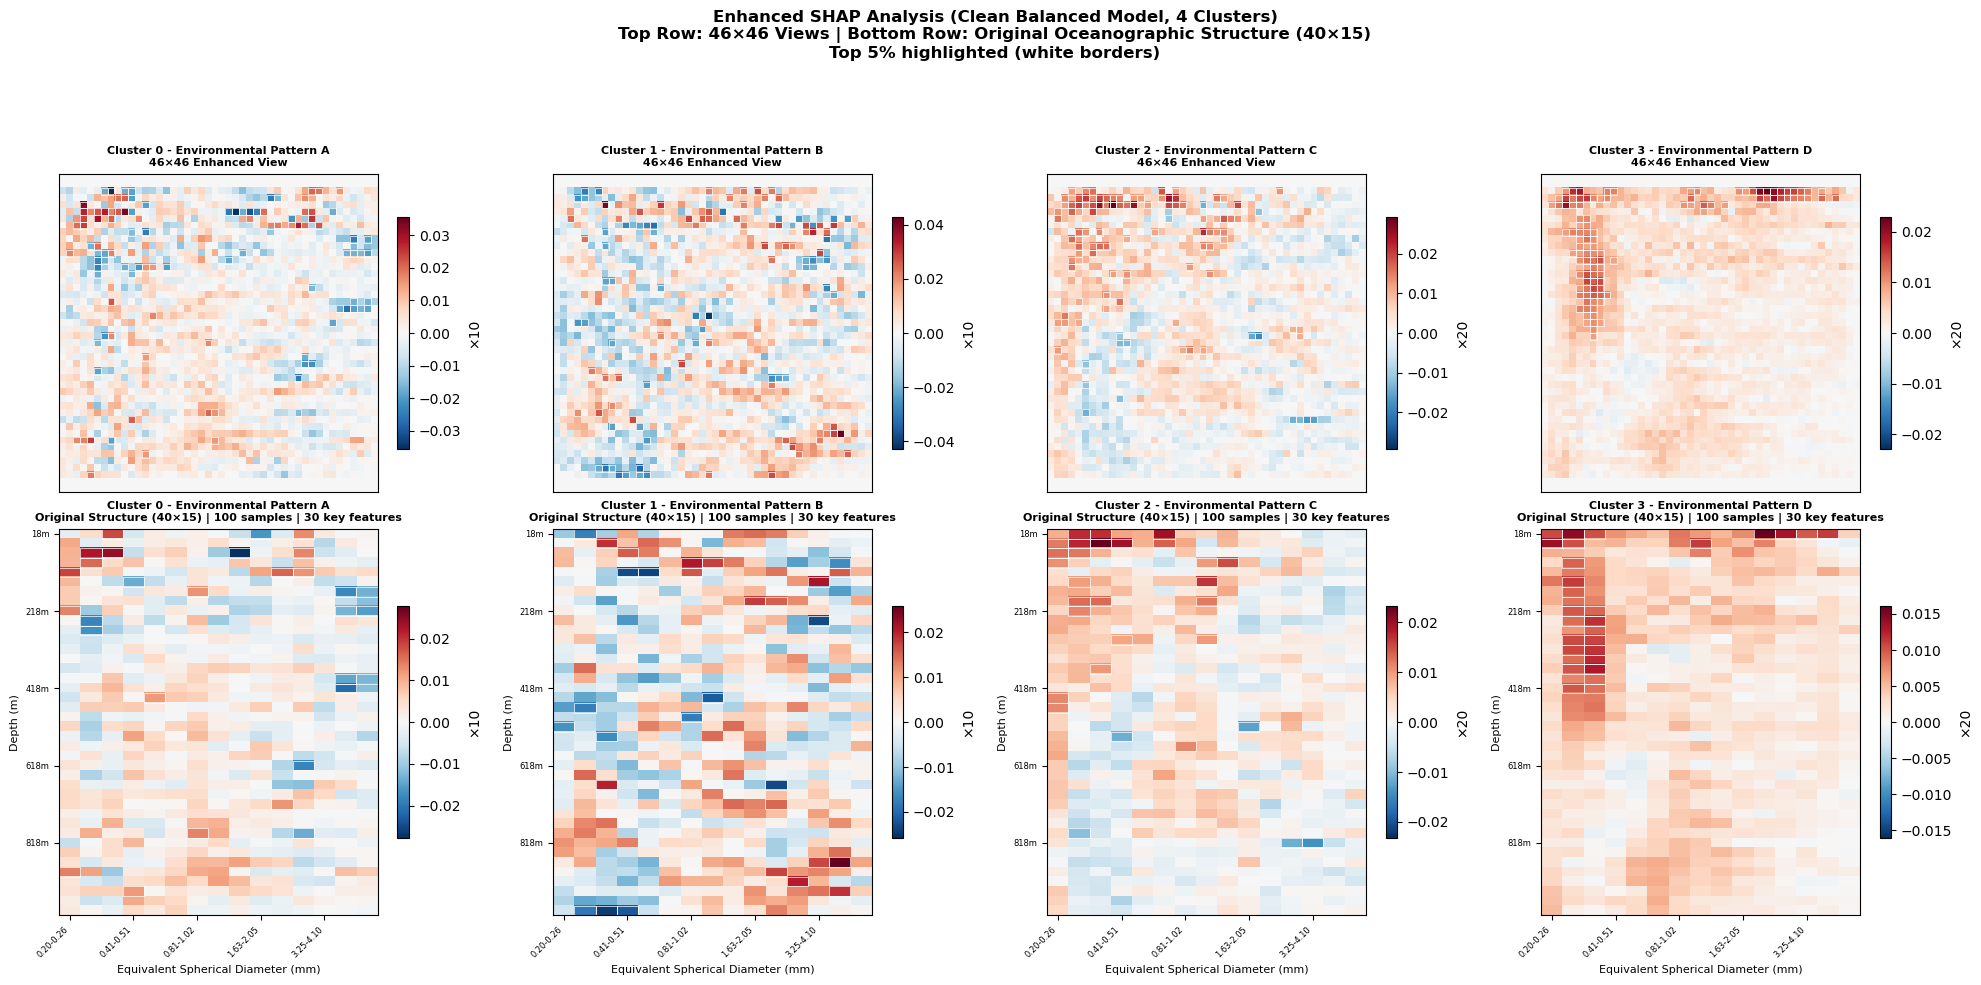


✅ Enhanced 2-row SHAP visualization completed for 4 clusters!
🎨 Created:
  1. Enhanced 2-row layout:  46×46 (top) vs 40×15 (bottom)
  2. Comparative 2-row analysis
🎯 Fixed 2-row layout for any number of clusters


In [99]:
# Run with fixed 2-row layout for any number of clusters
cluster_shapes= run_enhanced_2row_shap_visualization()

# Next steps (from original notebook)

## Implementation

[Implement the final model(s) you've selected based on the above steps.]


In [ ]:
# Implement the final model(s)
# Example: model = YourChosenModel(best_hyperparameters)
# model.fit(X_train, y_train)


## Evaluation Metrics

[Clearly specify which metrics you'll use to evaluate the model performance, and why you've chosen these metrics.]


In [ ]:
# Evaluate the model using your chosen metrics
# Example for classification
# y_pred = model.predict(X_test)
# print(classification_report(y_test, y_pred))

# Example for regression
# mse = mean_squared_error(y_test, y_pred)

# Your evaluation code here


## Comparative Analysis

[Compare the performance of your model(s) against the baseline model. Discuss any improvements or setbacks and the reasons behind them.]


In [ ]:
# Comparative Analysis code (if applicable)
# Example: comparing accuracy of the baseline model and the new model
# print(f"Baseline Model Accuracy: {baseline_accuracy}, New Model Accuracy: {new_model_accuracy}")


## Transfer Learning Workflow (EfficientNetB3)

(model was adapted/improved after presentation)

### Chapter 1: Data and Heatmaps

In [ ]:
# Install TensorFlow (includes EfficientNetB3) if needed
#!pip install -q tensorflow

In [13]:
# Load EfficientNetB3 base (downloads ImageNet weights on first run)
from tensorflow.keras.applications import EfficientNetB3
efficientnetb3_base = EfficientNetB3(
    weights="imagenet",
    include_top=False,
    input_shape=(300, 300, 3)
 )
efficientnetb3_base.trainable = False

In [14]:
classifier = HeatmapCNNClassifier()
classifier.load_data_assignments()
classifier.load_heatmaps()

Loading data assignments...
Train/test DataFrame shape: (5619, 3)
Clusters DataFrame shape: (5619, 4)
Train/test columns: ['Profile_id', 'data_type', 'CV_fold']
Clusters columns:  ['Profile_id', 'cluster', 'cluster_4', 'cluster_6']
Loaded assignments for 5619 profiles
Loaded cluster assignments for 5619 profiles
Sample train/test data for profile s033:  {'data_type': 'test', 'CV_fold': ''}
Sample cluster data for profile s033:  {'cluster': 1, 'cluster_4': 1, 'cluster_6': 2}
Loading heatmap images...
Found 5619 PNG files in ..\Data\heatmaps
Sample filenames: ['0000a_WMO5906623_recovery_profiles.png', '0002a_WMO5906623_recovery_profiles.png', '0003a_WMO5906623_recovery_profiles.png', '0003a_WMO6904139_recovery.png', '0004a_WMO6903096.png']
Sample extracted profile IDs: ['0000a_WMO5906623_recovery_profiles', '0002a_WMO5906623_recovery_profiles', '0003a_WMO5906623_recovery_profiles', '0003a_WMO6904139_recovery', '0004a_WMO6903096']
Available profile IDs from filenames: 5619
Profile IDs wit

### Chapter 2: Train/Test Splits

In [15]:
classifier.split_train_test()

Splitting data into train and test sets...
Training set:  4214 samples
Test set: 1405 samples
Number of classes: 4
Classes: [0 1 2 3]


### Chapter 3: Training Data Balancing

In [16]:
# Balance training data per fold only (same SMOTETomek settings as the CNN)
classifier.balance_classes_per_fold_SMOTETomek()
balanced_folds = classifier.fold_balanced_data

Balancing classes per fold using SMOTETomek (SMOTE + Tomek links)...
Processing 4 folds:  ['fold_1' 'fold_2' 'fold_3' 'fold_4']

Balancing fold:  fold_1
Original fold fold_1 training size: 3151
Balanced fold fold_1 training size: 4700
  Cluster 0: 1184 samples
  Cluster 1: 1170 samples
  Cluster 2: 1162 samples
  Cluster 3: 1184 samples

Balancing fold:  fold_2
Original fold fold_2 training size: 3151
Balanced fold fold_2 training size: 4702
  Cluster 0: 1183 samples
  Cluster 1: 1171 samples
  Cluster 2: 1165 samples
  Cluster 3: 1183 samples

Balancing fold:  fold_3
Original fold fold_3 training size: 3151
Balanced fold fold_3 training size: 4698
  Cluster 0: 1183 samples
  Cluster 1: 1168 samples
  Cluster 2: 1164 samples
  Cluster 3: 1183 samples

Balancing fold:  fold_4
Original fold fold_4 training size: 3189
Balanced fold fold_4 training size: 4740
  Cluster 0: 1193 samples
  Cluster 1: 1180 samples
  Cluster 2: 1174 samples
  Cluster 3: 1193 samples


### Chapter 4: Scaling and EfficientNet Preprocessing

In [17]:
import tensorflow as tf
from tensorflow.keras.applications.efficientnet import preprocess_input

target_size = (300, 300)

def preprocess_heatmap(image):
    image = tf.image.resize(image, target_size, method="bilinear")
    image = image * 255.0
    return preprocess_input(image)

### Chapter 5: Model Architecture

In [18]:
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras import layers, Model

if not hasattr(classifier, "n_classes"):
    classifier.split_train_test()

inputs = layers.Input(shape=(300, 300, 3))
base = EfficientNetB3(include_top=False, weights="imagenet", input_tensor=inputs)
base.trainable = False
x = layers.GlobalAveragePooling2D()(base.output)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(classifier.n_classes, activation="softmax")(x)
model = Model(inputs, outputs)

### Chapter 6: Head Training

Epoch 1/10
294/294 ━━━━━━━━━━━━━━━━━━━━ 1297s 4s/step - accuracy: 0.4743 - loss: 1.1845 - val_accuracy: 0.5494 - val_loss: 1.0532 - learning_rate: 0.0010
Epoch 2/10
294/294 ━━━━━━━━━━━━━━━━━━━━ 622s 2s/step - accuracy: 0.5683 - loss: 1.0398 - val_accuracy: 0.5221 - val_loss: 1.0856 - learning_rate: 0.0010
Epoch 3/10
294/294 ━━━━━━━━━━━━━━━━━━━━ 684s 2s/step - accuracy: 0.5923 - loss: 0.9804 - val_accuracy: 0.5635 - val_loss: 0.9998 - learning_rate: 0.0010
Epoch 4/10
294/294 ━━━━━━━━━━━━━━━━━━━━ 681s 2s/step - accuracy: 0.6130 - loss: 0.9386 - val_accuracy: 0.5663 - val_loss: 0.9957 - learning_rate: 0.0010
Epoch 5/10
294/294 ━━━━━━━━━━━━━━━━━━━━ 666s 2s/step - accuracy: 0.6183 - loss: 0.9189 - val_accuracy: 0.5654 - val_loss: 0.9903 - learning_rate: 0.0010
Epoch 6/10
294/294 ━━━━━━━━━━━━━━━━━━━━ 688s 2s/step - accuracy: 0.6183 - loss: 0.9013 - val_accuracy: 0.5710 - val_loss: 0.9549 - learning_rate: 0.0010
Epoch 7/10
294/294 ━━━━━━━━━━━━━━━━━━━━ 699s 2s/step - accuracy: 0.6185 - loss: 0

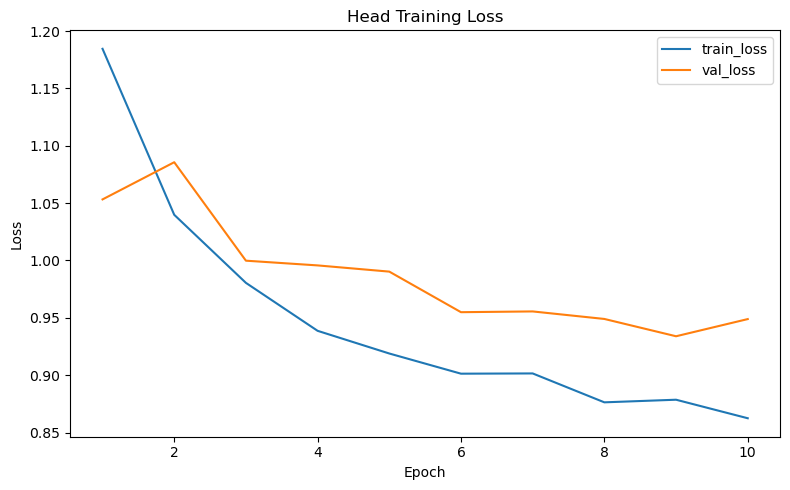

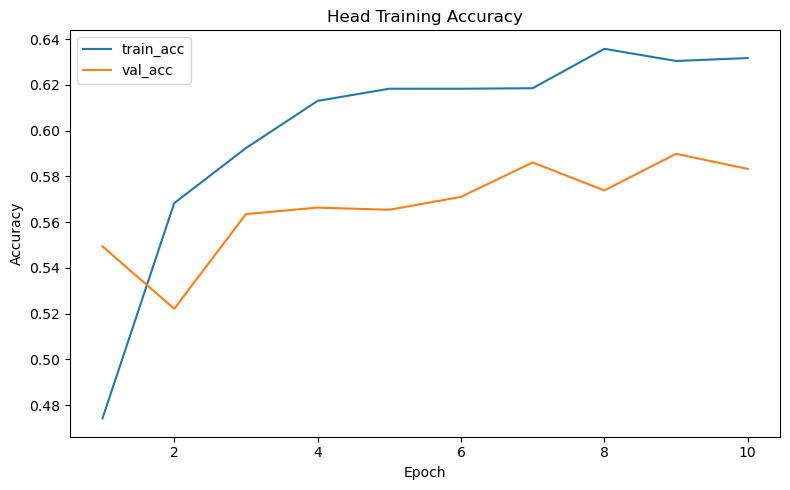

In [20]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7)
 ]

# build datasets if they are not already defined
if "train_ds" not in globals() or "val_ds" not in globals():
    if "target_size" not in globals():
        target_size = (300, 300)

    fold_key = sorted(balanced_folds.keys())[0]
    fold_data = balanced_folds[fold_key]

    X_train_head = fold_data["X_train"].astype("float32")
    y_train_head = tf.keras.utils.to_categorical(fold_data["y_train"], classifier.n_classes)

    X_val_head = fold_data["X_val"].astype("float32")
    y_val_head = tf.keras.utils.to_categorical(fold_data["y_val"], classifier.n_classes)

    def _preprocess(image, label):
        image = tf.image.resize(image, target_size, method="bilinear")
        image = image * 255.0
        image = tf.keras.applications.efficientnet.preprocess_input(image)
        return image, label

    batch_size = 16

    train_ds = (
        tf.data.Dataset.from_tensor_slices((X_train_head, y_train_head))
.shuffle(len(X_train_head), seed=42)
.map(_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
.batch(batch_size)
.prefetch(tf.data.AUTOTUNE)
)

    val_ds = (
        tf.data.Dataset.from_tensor_slices((X_val_head, y_val_head))
.map(_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
.batch(batch_size)
.prefetch(tf.data.AUTOTUNE)
)

if "epochs_head" not in globals():
    epochs_head = 10

# Phase 1: train the head
model.compile(optimizer=Adam(1e-3), loss="categorical_crossentropy", metrics=["accuracy"])
history = model.fit(train_ds, validation_data=val_ds, epochs=epochs_head, callbacks=callbacks, verbose=1)

# Report training/validation metrics
train_loss = history.history["loss"][-1]
train_acc = history.history["accuracy"][-1]
val_loss = history.history["val_loss"][-1]
val_acc = history.history["val_accuracy"][-1]
print(f"Train loss (head): {train_loss:.4f}")
print(f"Train accuracy (head): {train_acc:.4f}")
print(f"Validation loss (head): {val_loss:.4f}")
print(f"Validation accuracy (head): {val_acc:.4f}")

# Plot metric curves across epochs
epochs = range(1, len(history.history["loss"]) + 1)
plt.figure(figsize=(8, 5))
plt.plot(epochs, history.history["loss"], label="train_loss")
plt.plot(epochs, history.history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Head Training Loss")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, history.history["accuracy"], label="train_acc")
plt.plot(epochs, history.history["val_accuracy"], label="val_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Head Training Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

### Chapter 7: Fine-Tuning

In [22]:
import numpy as np
from pathlib import Path
from sklearn.metrics import f1_score, balanced_accuracy_score
from tensorflow.keras.callbacks import Callback, EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import json

# Phase 2: unfreeze the last 240 layers
base.trainable = True
for layer in base.layers[:-240]:
    layer.trainable = False

# Slightly stronger regularization
finetune_loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05)

# Validation labels for extra target metrics
selected_fold_key = None
if "fold_data" in globals() and isinstance(fold_data, dict):
    if "y_val" in fold_data:
        y_val_true = np.asarray(fold_data["y_val"])
        selected_fold_key = "fold_data"
elif "balanced_folds" in globals() and len(balanced_folds) > 0:
    candidate_key = f"fold_{k}" if "k" in globals() else None
    if candidate_key in balanced_folds:
        selected_fold_key = candidate_key
    else:
        selected_fold_key = sorted(balanced_folds.keys())[0]
    y_val_true = np.asarray(balanced_folds[selected_fold_key]["y_val"])
elif "y_val_head" in globals() and len(y_val_head.shape) > 1:
    y_val_true = np.argmax(y_val_head, axis=1)
else:
    raise NameError(
        "Validation labels are missing. Define fold_data/balanced_folds or y_val_head before running this cell."
    )

# Get training labels for balanced accuracy calculation
if "fold_data" in globals() and isinstance(fold_data, dict):
    if "y_train" in fold_data:
        y_train_true = np.asarray(fold_data["y_train"])
elif "balanced_folds" in globals() and len(balanced_folds) > 0:
    if selected_fold_key is None or selected_fold_key == "fold_data":
        selected_fold_key = sorted(balanced_folds.keys())[0]
    y_train_true = np.asarray(balanced_folds[selected_fold_key]["y_train"])
else:
    raise NameError(
        "Training labels are missing. Define fold_data/balanced_folds before running this cell."
    )


def _to_model_targets(y, n_classes):
    y = np.asarray(y)
    if y.ndim == 1:
        y = tf.keras.utils.to_categorical(y, num_classes=n_classes)
    return y


def _build_efficientnet_dataset(x, y, target_size=(300, 300), batch_size=16, shuffle=False):
    x = np.asarray(x).astype("float32")
    y = np.asarray(y)

    ds = tf.data.Dataset.from_tensor_slices((x, y))

    def _preprocess(image, label):
        image = tf.image.resize(image, target_size, method="bilinear")
        image = image * 255.0
        image = tf.keras.applications.efficientnet.preprocess_input(image)
        return image, label

    if shuffle:
        ds = ds.shuffle(len(x), seed=42)

    ds = ds.map(_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


# Ensure train_ds and val_ds exist
if "train_ds" not in globals() or "val_ds" not in globals():
    if "fold_data" in globals() and isinstance(fold_data, dict) and "X_train" in fold_data and "X_val" in fold_data:
        source_block = fold_data
    elif "balanced_folds" in globals() and len(balanced_folds) > 0:
        if selected_fold_key is None or selected_fold_key == "fold_data":
            selected_fold_key = sorted(balanced_folds.keys())[0]
        source_block = balanced_folds[selected_fold_key]
    else:
        raise NameError(
            "train_ds/val_ds are not defined and no fold_data/balanced_folds are available to build them."
        )

    n_classes = int(model.output_shape[-1])
    y_train_targets = _to_model_targets(source_block["y_train"], n_classes)
    y_val_targets = _to_model_targets(source_block["y_val"], n_classes)

    train_ds = _build_efficientnet_dataset(
        source_block["X_train"],
        y_train_targets,
        target_size=(300, 300),
        batch_size=16,
        shuffle=True,
    )
    val_ds = _build_efficientnet_dataset(
        source_block["X_val"],
        y_val_targets,
        target_size=(300, 300),
        batch_size=16,
        shuffle=False,
    )

    y_val_true = np.asarray(source_block["y_val"])
    y_train_true = np.asarray(source_block["y_train"])


class ValidationMetricsCallback(Callback):
    def __init__(self, train_ds, val_ds, y_train_true, y_val_true):
        super().__init__()
        self.train_ds = train_ds
        self.val_ds = val_ds
        self.y_train_true = y_train_true
        self.y_val_true = y_val_true
        self.train_macro_f1 = []
        self.train_bal_acc = []
        self.val_macro_f1 = []
        self.val_bal_acc = []

    def on_epoch_end(self, epoch, logs=None):
        # Training metrics
        y_train_prob = self.model.predict(self.train_ds, verbose=0)
        y_train_pred = np.argmax(y_train_prob, axis=1)
        train_macro_f1_value = f1_score(self.y_train_true, y_train_pred, average="macro")
        train_bal_acc_value = balanced_accuracy_score(self.y_train_true, y_train_pred)
        self.train_macro_f1.append(train_macro_f1_value)
        self.train_bal_acc.append(train_bal_acc_value)
        
        # Validation metrics
        y_val_prob = self.model.predict(self.val_ds, verbose=0)
        y_val_pred = np.argmax(y_val_prob, axis=1)
        val_macro_f1_value = f1_score(self.y_val_true, y_val_pred, average="macro")
        val_bal_acc_value = balanced_accuracy_score(self.y_val_true, y_val_pred)
        self.val_macro_f1.append(val_macro_f1_value)
        self.val_bal_acc.append(val_bal_acc_value)
        
        if logs is not None:
            logs["train_macro_f1"] = train_macro_f1_value
            logs["train_balanced_accuracy"] = train_bal_acc_value
            logs["val_macro_f1"] = val_macro_f1_value
            logs["val_balanced_accuracy"] = val_bal_acc_value
        
        print(f" - train_macro_f1: {train_macro_f1_value:.4f} - train_bal_acc: {train_bal_acc_value:.4f} "
              f"- val_macro_f1: {val_macro_f1_value:.4f} - val_bal_acc: {val_bal_acc_value:.4f}")


# Ablation run over multiple fine-tuning epoch settings
epochs_candidates = [8, 12, 15]
initial_finetune_weights = model.get_weights()
checkpoint_dir = Path("3_Model") / "checkpoints"
checkpoint_dir.mkdir(parents=True, exist_ok=True)

ablation_results = []
best_overall = None

for epochs_finetune in epochs_candidates:
    model.set_weights(initial_finetune_weights)

    run_checkpoint = checkpoint_dir / f"finetune_best_ep{epochs_finetune}.keras"
    val_metrics_cb = ValidationMetricsCallback(train_ds, val_ds, y_train_true, y_val_true)
    callbacks_finetune = [
        EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=2, min_lr=1e-7),
        ModelCheckpoint(filepath=str(run_checkpoint), monitor="val_loss", save_best_only=True, verbose=1),
        val_metrics_cb,
    ]

    model.compile(optimizer=Adam(1e-5), loss=finetune_loss, metrics=["accuracy"])
    history_run = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs_finetune,
        callbacks=callbacks_finetune,
        verbose=1,
    )

    best_val_loss_run = float(np.min(history_run.history["val_loss"]))
    best_epoch_run = int(np.argmin(history_run.history["val_loss"])) + 1
    final_train_loss = float(history_run.history["loss"][-1])
    final_train_acc = float(history_run.history["accuracy"][-1])
    final_val_loss = float(history_run.history["val_loss"][-1])
    final_val_acc = float(history_run.history["val_accuracy"][-1])
    final_train_macro_f1 = float(val_metrics_cb.train_macro_f1[-1])
    final_train_bal_acc = float(val_metrics_cb.train_bal_acc[-1])
    final_val_macro_f1 = float(val_metrics_cb.val_macro_f1[-1])
    final_val_bal_acc = float(val_metrics_cb.val_bal_acc[-1])

    result = {
        "epochs": epochs_finetune,
        "best_val_loss": best_val_loss_run,
        "best_epoch": best_epoch_run,
        "final_train_loss": final_train_loss,
        "final_train_acc": final_train_acc,
        "final_train_macro_f1": final_train_macro_f1,
        "final_train_bal_acc": final_train_bal_acc,
        "final_val_loss": final_val_loss,
        "final_val_acc": final_val_acc,
        "final_val_macro_f1": final_val_macro_f1,
        "final_val_bal_acc": final_val_bal_acc,
        "checkpoint": str(run_checkpoint),
    }
    ablation_results.append(result)

    if best_overall is None or best_val_loss_run < best_overall["best_val_loss"]:
        best_overall = result

# Load best checkpoint from ablation
model.load_weights(best_overall["checkpoint"])

train_loss_finetune, train_acc_finetune = model.evaluate(train_ds, verbose=0)
val_loss_finetune, val_acc_finetune = model.evaluate(val_ds, verbose=0)

# Calculate final balanced accuracy for best model
y_train_pred = np.argmax(model.predict(train_ds, verbose=0), axis=1)
y_val_pred = np.argmax(model.predict(val_ds, verbose=0), axis=1)

train_macro_f1_finetune = f1_score(y_train_true, y_train_pred, average="macro")
train_bal_acc_finetune = balanced_accuracy_score(y_train_true, y_train_pred)
val_macro_f1_finetune = f1_score(y_val_true, y_val_pred, average="macro")
val_bal_acc_finetune = balanced_accuracy_score(y_val_true, y_val_pred)

print("\nAblation summary:")
for item in ablation_results:
    print(
        f"epochs={item['epochs']}: best_val_loss={item['best_val_loss']:.4f} (epoch {item['best_epoch']}), "
        f"final_train_acc={item['final_train_acc']:.4f}, final_train_bal_acc={item['final_train_bal_acc']:.4f}, "
        f"final_val_acc={item['final_val_acc']:.4f}, final_val_bal_acc={item['final_val_bal_acc']:.4f}, "
        f"final_val_macro_f1={item['final_val_macro_f1']:.4f}"
    )

print(f"\nBest run selected: epochs={best_overall['epochs']} with checkpoint {best_overall['checkpoint']}")

# Report training/validation metrics (fine-tuning) analog to head training
print("\n" + "="*80)
print("FINE-TUNING RESULTS (Best Model)")
print("="*80)
print(f"Train loss: {train_loss_finetune:.4f}")
print(f"Train accuracy: {train_acc_finetune:.4f}")
print(f"Train macro F1: {train_macro_f1_finetune:.4f}")
print(f"Train balanced accuracy: {train_bal_acc_finetune:.4f}")
print(f"\nValidation loss: {val_loss_finetune:.4f}")
print(f"Validation accuracy: {val_acc_finetune:.4f}")
print(f"Validation macro F1: {val_macro_f1_finetune:.4f}")
print(f"Validation balanced accuracy: {val_bal_acc_finetune:.4f}")
print("="*80)

# Save ablation results to JSON for later use
results_save_path = checkpoint_dir / "ablation_results.json"
results_data = {
    "ablation_results": ablation_results,
    "best_overall": best_overall,
    "y_val_true": y_val_true.tolist(),
    "y_val_pred": y_val_pred.tolist(),
}

with open(results_save_path, 'w') as f:
    json.dump(results_data, f, indent=2)

print(f"\nResults saved to: {results_save_path}")

Epoch 1/8
294/294 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.4227 - loss: 1.3955
Epoch 1: val_loss improved from None to 1.05210, saving model to 3_Model\checkpoints\finetune_best_ep8.keras

Epoch 1: finished saving model to 3_Model\checkpoints\finetune_best_ep8.keras
 - train_macro_f1: 0.2504 - train_bal_acc: 0.2509 - val_macro_f1: 0.5284 - val_bal_acc: 0.5455
294/294 ━━━━━━━━━━━━━━━━━━━━ 2461s 8s/step - accuracy: 0.4721 - loss: 1.2725 - val_accuracy: 0.5814 - val_loss: 1.0521 - learning_rate: 1.0000e-05 - train_macro_f1: 0.2504 - train_balanced_accuracy: 0.2509 - val_macro_f1: 0.5284 - val_balanced_accuracy: 0.5455
Epoch 2/8
294/294 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.5646 - loss: 1.0763
Epoch 2: val_loss improved from 1.05210 to 0.99915, saving model to 3_Model\checkpoints\finetune_best_ep8.keras

Epoch 2: finished saving model to 3_Model\checkpoints\finetune_best_ep8.keras
 - train_macro_f1: 0.2541 - train_bal_acc: 0.2549 - val_macro_f1: 0.5575 - val_bal_acc: 0.5916
29

### Confusion Matrix of best model



Ergänzende Informationen (ohne Metrik-Dopplung):
- Gewählter Run: epochs=12 (Rang 1/3 nach best_val_loss)
- Checkpoint vorhanden: Ja
- Ablation-Datei: C:\Orga_Sina\carbon-flux-prediction\3_Model\3_Model\checkpoints\ablation_results.json


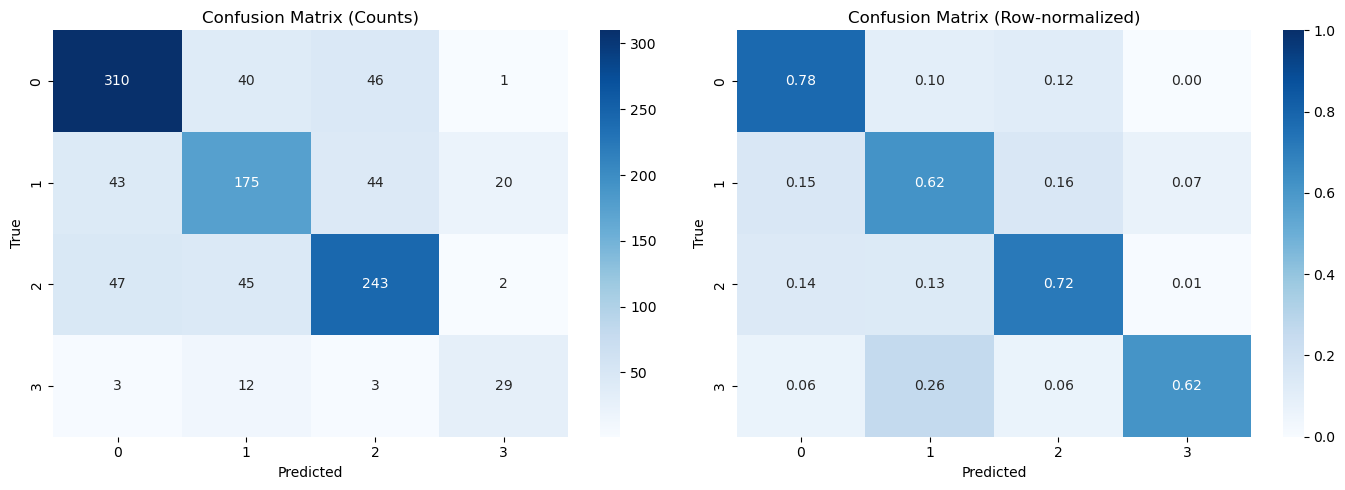


Top-3 Verwechslungen (true -> pred):
- 2 -> 0: 47
- 0 -> 2: 46
- 2 -> 1: 45


In [24]:

import json
import numpy as np
from pathlib import Path
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- Load metadata/predictions only if not already in memory ---
if "best_overall" not in globals() or "ablation_results" not in globals():
    results_path = Path("3_Model") / "checkpoints" / "ablation_results.json"
    if not results_path.exists():
        raise FileNotFoundError(
            f"Keine gespeicherten Ablation-Ergebnisse gefunden: {results_path}\n"
            "Bitte zuerst Zelle 71 (Fine-Tuning) ausführen."
        )
    with open(results_path, "r", encoding="utf-8") as f:
        results_data = json.load(f)
    ablation_results = results_data["ablation_results"]
    best_overall = results_data["best_overall"]
    y_val_true = np.array(results_data.get("y_val_true", []), dtype=int)
    y_val_pred = np.array(results_data.get("y_val_pred", []), dtype=int)

# --- Additional info (without repeating metrics from Cell 71) ---
checkpoint_path = Path(best_overall["checkpoint"])
ranked = sorted(ablation_results, key=lambda r: r["best_val_loss"])
best_rank = next(i + 1 for i, r in enumerate(ranked) if r["epochs"] == best_overall["epochs"])

print("Ergänzende Informationen (ohne Metrik-Dopplung):")
print(f"- Gewählter Run: epochs={best_overall['epochs']} (Rang {best_rank}/{len(ranked)} nach best_val_loss)")
print(f"- Checkpoint vorhanden: {'Ja' if checkpoint_path.exists() else 'Nein'}")
print(f"- Ablation-Datei: {(Path('3_Model') / 'checkpoints' / 'ablation_results.json').resolve()}")

# --- Error analysis only if predictions are available ---
if "y_val_true" in globals() and "y_val_pred" in globals() and len(y_val_true) == len(y_val_pred) and len(y_val_true) > 0:
    cm = confusion_matrix(y_val_true, y_val_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    cm_norm = np.nan_to_num(cm_norm)

    # Use class names from label encoder if available
    if "classifier" in globals() and hasattr(classifier, "label_encoder"):
        class_names = list(classifier.label_encoder.classes_)
    else:
        class_names = [f"Class {i}" for i in range(cm.shape[0])]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=class_names, yticklabels=class_names, ax=axes[0]
    )
    axes[0].set_title("Confusion Matrix (Counts)")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")

    sns.heatmap(
        cm_norm, annot=True, fmt=".2f", cmap="Blues",
        xticklabels=class_names, yticklabels=class_names, ax=axes[1], vmin=0, vmax=1
    )
    axes[1].set_title("Confusion Matrix (Row-normalized)")
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("True")

    plt.tight_layout()
    plt.show()

    # Top confusions (excluding diagonal)
    off_diag = cm.copy()
    np.fill_diagonal(off_diag, 0)
    top_pairs = np.dstack(np.unravel_index(np.argsort(off_diag.ravel())[::-1], off_diag.shape))[0]

    print("\nTop-3 Verwechslungen (true -> pred):")
    shown = 0
    for i, j in top_pairs:
        cnt = off_diag[i, j]
        if cnt <= 0:
            break
        print(f"- {class_names[i]} -> {class_names[j]}: {cnt}")
        shown += 1
        if shown == 3:
            break
else:
    print(
        "\nHinweis: Keine gespeicherten y_val_true/y_val_pred verfügbar. "
        "Für die Fehleranalyse bitte Zelle 71 erneut ausführen."
    )

### Chapter 8: Full Dataset Evaluation with Best Model
Evaluation des besten EfficientNetB3 Modells (aus Chapter 7) auf dem kompletten Datensatz (Train + Test)

FULL DATASET EVALUATION WITH BEST MODEL FROM CHAPTER 7

Best model from Chapter 7:
- epochs:        12
- best_epoch:    12
- best_val_loss: 0.8112
- checkpoint:    3_Model\checkpoints\finetune_best_ep12.keras

Model loaded successfully: 3_Model\checkpoints\finetune_best_ep12.keras

Full dataset:
- X_full shape:  (5619, 46, 46, 3)
- y_full shape:  (5619,)
- n_classes:     4
176/176 ━━━━━━━━━━━━━━━━━━━━ 681s 4s/step - accuracy: 0.8372 - loss: 0.4711
176/176 ━━━━━━━━━━━━━━━━━━━━ 693s 4s/step

FULL DATASET RESULTS (Equivalent Metrics)
Loss:                0.4711
Accuracy:            0.8372
Macro F1:            0.8329
Balanced Accuracy:   0.8360

Classification report:
              precision    recall  f1-score   support

           0     0.8610    0.8724    0.8666      2108
           1     0.7979    0.7778    0.7877      1467
           2     0.8428    0.8423    0.8426      1795
           3     0.8185    0.8514    0.8346       249

    accuracy                         0.8372      5619
 

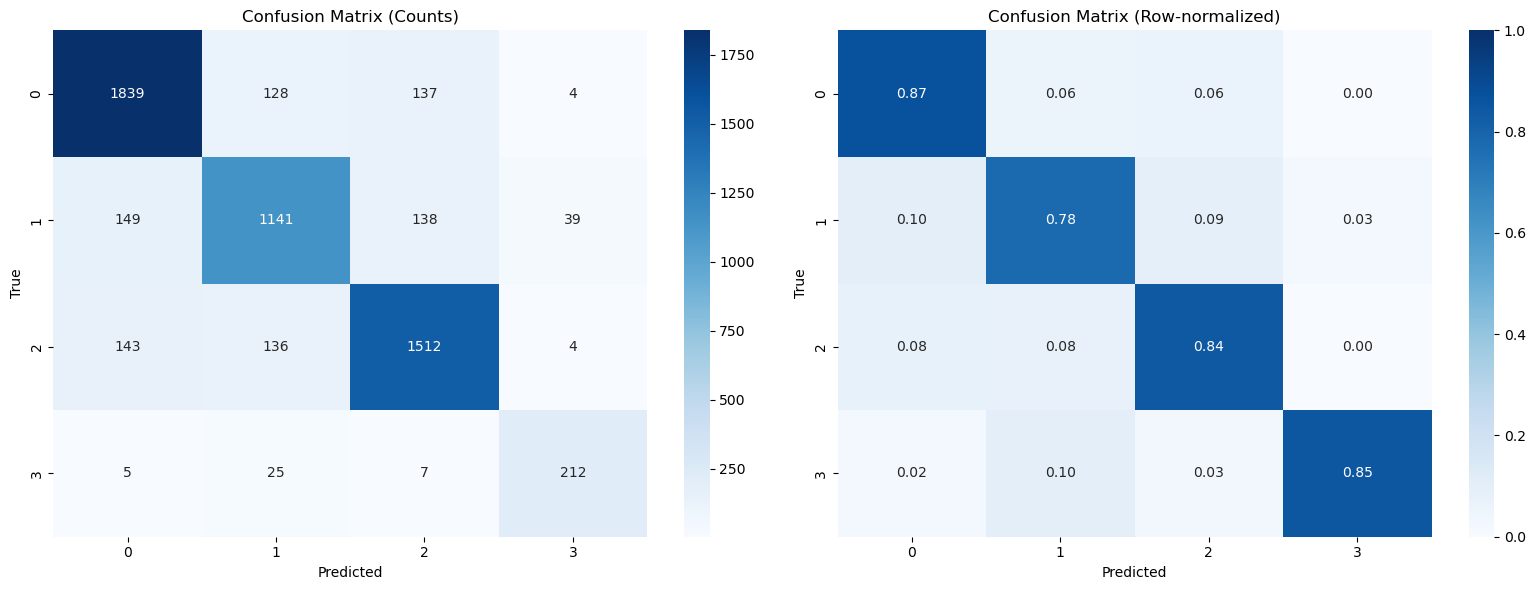

In [ ]:
import json
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report, f1_score, balanced_accuracy_score
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications.efficientnet import preprocess_input

print("=" * 80)
print("FULL DATASET EVALUATION WITH BEST MODEL FROM CHAPTER 7")
print("=" * 80)

# 1) Load best run metadata from memory or JSON
if "best_overall" not in globals() or best_overall is None:
    results_path = Path("3_Model") / "checkpoints" / "ablation_results.json"
    if not results_path.exists():
        raise FileNotFoundError(f"No ablation_results.json found: {results_path}")
    with open(results_path, "r", encoding="utf-8") as f:
        results_data = json.load(f)
    best_overall = results_data["best_overall"]
    print(f"Loaded best_overall from: {results_path}")

print("\nBest model from Chapter 7:")
print(f"- epochs:        {best_overall['epochs']}")
print(f"- best_epoch:    {best_overall['best_epoch']}")
print(f"- best_val_loss: {best_overall['best_val_loss']:.4f}")
print(f"- checkpoint:    {best_overall['checkpoint']}")

# 2) Load best checkpoint
model_path = Path(best_overall["checkpoint"])
if not model_path.exists():
    raise FileNotFoundError(f"Checkpoint not found: {model_path}")

best_model = tf.keras.models.load_model(model_path, compile=False)
best_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
print(f"\nModel loaded successfully: {model_path}")

# 3) Validate classifier/data availability
if "classifier" not in globals():
    raise NameError("`classifier` not found. Please run the data-loading cells first.")

if not hasattr(classifier, "X_data") or not hasattr(classifier, "y_data"):
    raise AttributeError("classifier.X_data / classifier.y_data missing. Please run classifier.load_heatmaps().")

X_full = np.asarray(classifier.X_data, dtype=np.float32)
y_full_raw = np.asarray(classifier.y_data)

n_classes_model = int(best_model.output_shape[-1])

# 4) Ensure labels are integer-encoded [0..n_classes-1]
if y_full_raw.ndim > 1:
    y_full = np.argmax(y_full_raw, axis=1).astype(int)
elif np.issubdtype(y_full_raw.dtype, np.integer):
    y_full = y_full_raw.astype(int)
else:
    if not hasattr(classifier, "label_encoder"):
        raise AttributeError("Non-integer labels detected but classifier.label_encoder is missing.")
    y_full = classifier.label_encoder.transform(y_full_raw).astype(int)

# Safety check
if np.max(y_full) >= n_classes_model or np.min(y_full) < 0:
    raise ValueError(
        f"Label range mismatch: labels in [{np.min(y_full)}, {np.max(y_full)}], "
        f"but model expects {n_classes_model} classes."
    )

# Class names
if hasattr(classifier, "label_encoder") and hasattr(classifier.label_encoder, "classes_"):
    class_names = list(classifier.label_encoder.classes_)
else:
    class_names = [f"Class {i}" for i in range(n_classes_model)]

if len(class_names) != n_classes_model:
    class_names = [f"Class {i}" for i in range(n_classes_model)]

print("\nFull dataset:")
print(f"- X_full shape:  {X_full.shape}")
print(f"- y_full shape:  {y_full.shape}")
print(f"- n_classes:     {n_classes_model}")

# 5) Build EfficientNet evaluation dataset
def make_full_dataset(X, y, n_classes, batch_size=32, target_size=(300, 300)):
    y_cat = to_categorical(y, num_classes=n_classes)
    ds = tf.data.Dataset.from_tensor_slices((X, y_cat))

    def _preprocess(image, label):
        image = tf.image.resize(image, target_size, method="bilinear")
        image = image * 255.0
        image = preprocess_input(image)
        return image, label

    ds = ds.map(_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

full_ds = make_full_dataset(X_full, y_full, n_classes_model, batch_size=32, target_size=(300, 300))

# 6) Evaluate + predict
loss_full, acc_full = best_model.evaluate(full_ds, verbose=1)
y_pred_proba = best_model.predict(full_ds, verbose=1)
y_pred = np.argmax(y_pred_proba, axis=1)

macro_f1_full = f1_score(y_full, y_pred, average="macro")
bal_acc_full = balanced_accuracy_score(y_full, y_pred)

# 7) Equivalent metric output (as in Chapter 7: loss, acc, macro F1, balanced acc)
print("\n" + "=" * 80)
print("FULL DATASET RESULTS (Equivalent Metrics)")
print("=" * 80)
print(f"Loss:                {loss_full:.4f}")
print(f"Accuracy:            {acc_full:.4f}")
print(f"Macro F1:            {macro_f1_full:.4f}")
print(f"Balanced Accuracy:   {bal_acc_full:.4f}")
print("=" * 80)

# Optional detailed report
print("\nClassification report:")
print(classification_report(y_full, y_pred, target_names=[str(c) for c in class_names], digits=4))

# 8) Confusion matrix (counts + row-normalized)
cm = confusion_matrix(y_full, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
cm_norm = np.nan_to_num(cm_norm)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=class_names, yticklabels=class_names, ax=axes[0]
)
axes[0].set_title("Confusion Matrix (Counts)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

sns.heatmap(
    cm_norm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
    xticklabels=class_names, yticklabels=class_names, ax=axes[1]
)
axes[1].set_title("Confusion Matrix (Row-normalized)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.tight_layout()
plt.show()